# Malaysia CHIRPS Rainfall & Flood Risk Data Analytics Project

This notebook is a **one-stop tutorial workflow** for the WQF7004 data analytics project.

Project theme:

**Rainfall-Based Flood Risk Analysis Across Major Malaysian Cities Using CHIRPS Daily Rainfall Data, 2000–2026**

Main workflow:

0. Data acquisition and dataset construction  
1. Dataset background and problem understanding  
2. Data cleaning and preprocessing  
3. Descriptive statistics and dataset overview  
4. Univariate EDA  
5. Temporal EDA  
6. Spatial / city-level EDA  
7. Correlation and feature relationship analysis  
8. PCA bonus visualization  
9. Clustering analysis  
10. Regression analysis  
11. Classification analysis  
12. pretrained PatchTST Transformer prediction  
13. Interactive UI dashboard  
14. Insights, recommendations, and limitations

Important interpretation:

`Flood_Risk_Binary` is a **rainfall-based flood-risk proxy**, not an official flood occurrence record.

Rule used in this project:

- `rainfall_risk_label == 3` means **Very Heavy rainfall**
- `Flood_Risk_Binary = 1` if `rainfall_risk_label == 3`
- otherwise `Flood_Risk_Binary = 0`

## 0. Environment Setup

Run this cell first. If a package is missing, install it using the commented pip command.

For basic EDA and machine learning, the required packages are light. For the PatchTST section, extra packages are needed and the code is placed in an optional section.

In [1]:
# Uncomment only if needed:
# !pip install pandas numpy matplotlib scikit-learn xarray netCDF4 h5netcdf requests seaborn plotly streamlit torch xgboost transformers accelerate

from pathlib import Path
import os
import time
import warnings
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
)
# This helps Apple Silicon MPS fall back safely if one PyTorch operation is not supported on MPS.
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

# Compatible RMSE helper.
# scikit-learn 1.4+ recommends root_mean_squared_error instead of
# mean_squared_error(..., squared=False).
try:
    from sklearn.metrics import root_mean_squared_error

    def rmse_score(y_true, y_pred):
        return root_mean_squared_error(y_true, y_pred)

except Exception:
    def rmse_score(y_true, y_pred):
        return mean_squared_error(y_true, y_pred, squared=False)


# PyTorch is used for GPU/MPS acceleration in PCA helper logic, classification, and TFT.
# XGBoost regression uses CUDA GPU when available.
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import Dataset, DataLoader

    if torch.cuda.is_available():
        DEVICE = torch.device("cuda")
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        DEVICE = torch.device("mps")
    else:
        DEVICE = torch.device("cpu")

    print("PyTorch available.")
    print("Selected device:", DEVICE)
    if DEVICE.type == "cuda":
        print("CUDA device:", torch.cuda.get_device_name(0))
except Exception as e:
    torch = None
    nn = None
    Dataset = None
    DataLoader = None
    DEVICE = "cpu"
    print("PyTorch is not available. GPU sections will require torch installation.")
    print(e)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)
print("Environment ready.")

PyTorch available.
Selected device: cuda
CUDA device: NVIDIA A100-SXM4-80GB
Environment ready.


## 0.1 Project Paths

These paths follow your current project structure.

- Raw NetCDF files: `Datasets/NC`
- Processed CSV files: `Datasets/CSV`
- Notebook outputs: `Outputs`

In [2]:
# =========================================================
# Project paths
# =========================================================
from pathlib import Path

# This notebook supports both your DICC/Jupyter path and your local Mac path.
# It automatically uses the first existing project folder.
PROJECT_CANDIDATES = [
    Path("/scr/user/kevin2002/TensorCat/Data Analysis/Group_Project/Data"),
    Path("/Users/kevin/PycharmProjects/TensorCat/Data Analytics"),
]

PROJECT_DIR = next((p for p in PROJECT_CANDIDATES if p.exists()), PROJECT_CANDIDATES[0])
NC_DIR = PROJECT_DIR / "Datasets" / "NC"
CSV_DIR = PROJECT_DIR / "Datasets" / "CSV"
OUTPUT_DIR = PROJECT_DIR / "Outputs"

for p in [NC_DIR, CSV_DIR, OUTPUT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

START_YEAR = 2000
END_YEAR = 2026

# This is the ONLY main dataset used by all later cleaning, EDA, ML, TFT, and dashboard sections.
MAIN_CSV_NAME = "malaysia_chirps_2000_2026_city_rainfall_clean_eda.csv"
MERGED_CSV = CSV_DIR / MAIN_CSV_NAME

print("PROJECT_DIR:", PROJECT_DIR)
print("NC_DIR:", NC_DIR)
print("CSV_DIR:", CSV_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("MAIN_CSV_NAME:", MAIN_CSV_NAME)
print("MERGED_CSV:", MERGED_CSV)


PROJECT_DIR: /scr/user/kevin2002/TensorCat/Data Analysis/Group_Project/Data
NC_DIR: /scr/user/kevin2002/TensorCat/Data Analysis/Group_Project/Data/Datasets/NC
CSV_DIR: /scr/user/kevin2002/TensorCat/Data Analysis/Group_Project/Data/Datasets/CSV
OUTPUT_DIR: /scr/user/kevin2002/TensorCat/Data Analysis/Group_Project/Data/Outputs
MAIN_CSV_NAME: malaysia_chirps_2000_2026_city_rainfall_clean_eda.csv
MERGED_CSV: /scr/user/kevin2002/TensorCat/Data Analysis/Group_Project/Data/Datasets/CSV/malaysia_chirps_2000_2026_city_rainfall_clean_eda.csv


# 0. Data Acquisition and Dataset Construction

This part compresses the functions from:

- `Download_Chirps_NC_2000_2026.py`
- `NC_Convert2_CSV.py`

The aim is to make the notebook reproducible. You can download raw CHIRPS NetCDF files, convert them into city-level CSV files, and create one merged 2000–2026 CSV.

**Practical note:** downloading all CHIRPS NetCDF files can take a long time and around 30GB storage. Keep `RUN_DOWNLOAD = False` if files are already downloaded.

## 0.2 Download CHIRPS NetCDF Files, 2000–2026

This cell downloads yearly CHIRPS daily NetCDF files from the official CHIRPS directory.

Default setting is `RUN_DOWNLOAD = False` to avoid accidentally downloading 30GB again.

In [ ]:
import requests

RUN_DOWNLOAD = False  # Change to True only when you want to download the NC files.

BASE_URL = "https://data.chc.ucsb.edu/products/CHIRPS-2.0/global_daily/netcdf/p05"
CHUNK_SIZE = 1024 * 1024
MAX_RETRIES = 5
TIMEOUT = 60


def format_size(num_bytes):
    if num_bytes is None:
        return "unknown size"
    gb = num_bytes / (1024 ** 3)
    mb = num_bytes / (1024 ** 2)
    return f"{gb:.2f} GB" if gb >= 1 else f"{mb:.2f} MB"


def get_remote_file_size(url):
    try:
        r = requests.head(url, allow_redirects=True, timeout=TIMEOUT)
        r.raise_for_status()
        size = r.headers.get("Content-Length")
        return int(size) if size else None
    except Exception as e:
        print("Warning: cannot get remote size:", e)
        return None


def download_file_with_resume(url, out_path):
    remote_size = get_remote_file_size(url)
    local_size = out_path.stat().st_size if out_path.exists() else 0

    print("\n" + "=" * 70)
    print("URL:", url)
    print("Output:", out_path)
    print("Remote:", format_size(remote_size), "| Local:", format_size(local_size))

    if remote_size is not None and out_path.exists() and local_size == remote_size:
        print("Already complete. Skipped.")
        return True

    if remote_size is not None and local_size > remote_size:
        print("Local file is larger than remote. Removing corrupted file.")
        out_path.unlink()
        local_size = 0

    for attempt in range(1, MAX_RETRIES + 1):
        headers = {"Range": f"bytes={local_size}-"} if local_size > 0 else {}
        mode = "ab" if local_size > 0 else "wb"
        try:
            with requests.get(url, headers=headers, stream=True, timeout=TIMEOUT) as r:
                if local_size > 0 and r.status_code == 200:
                    print("Server ignored resume. Restarting clean download.")
                    out_path.unlink(missing_ok=True)
                    local_size = 0
                    mode = "wb"
                r.raise_for_status()
                downloaded = local_size
                with open(out_path, mode) as f:
                    last = time.time()
                    for chunk in r.iter_content(chunk_size=CHUNK_SIZE):
                        if chunk:
                            f.write(chunk)
                            downloaded += len(chunk)
                            if time.time() - last > 1:
                                if remote_size:
                                    pct = downloaded / remote_size * 100
                                    print(f"\rDownloaded {format_size(downloaded)} / {format_size(remote_size)} ({pct:.2f}%)", end="")
                                else:
                                    print(f"\rDownloaded {format_size(downloaded)}", end="")
                                last = time.time()
                print()
            final_size = out_path.stat().st_size
            if remote_size is not None and final_size != remote_size:
                print("Size mismatch. Will retry/resume.")
                local_size = final_size
                continue
            print("Download completed.")
            return True
        except Exception as e:
            print(f"Attempt {attempt}/{MAX_RETRIES} failed: {e}")
            time.sleep(3 * attempt)
            local_size = out_path.stat().st_size if out_path.exists() else 0
    return False


def download_chirps_nc(start_year=START_YEAR, end_year=END_YEAR):
    failed = []
    for year in range(start_year, end_year + 1):
        filename = f"chirps-v2.0.{year}.days_p05.nc"
        url = f"{BASE_URL}/{filename}"
        out_path = NC_DIR / filename
        ok = download_file_with_resume(url, out_path)
        if not ok:
            failed.append(year)
    print("\nDownload summary")
    print("Failed years:" if failed else "All requested years completed.", failed)

if RUN_DOWNLOAD:
    download_chirps_nc()
else:
    print("RUN_DOWNLOAD is False. Skipping download step.")
    print("Set RUN_DOWNLOAD = True when you need to download raw CHIRPS NC files.")

## 0.3 Convert NetCDF Files into City-Level CSV Files

This cell converts raw yearly NetCDF files into city-level rainfall CSV files.

It outputs:

- one CSV per year
- one merged CSV for 2000–2026

Default setting is `RUN_CONVERSION = False` to avoid rerunning a long conversion if the merged CSV already exists.

In [ ]:
RUN_CONVERSION = False  # Change to True when you want to regenerate CSV files from NC files.

import xarray as xr

# Public Infobanjir rainfall intensity thresholds.
LIGHT_MIN = 1.0
MODERATE_MIN = 11.0
HEAVY_MIN = 31.0
VERY_HEAVY_MIN = 60.0

CITIES = [
    {"city": "Kuala Lumpur", "state": "WP Kuala Lumpur", "lat": 3.1390, "lon": 101.6869, "radius_km": 25},
    {"city": "Putrajaya", "state": "WP Putrajaya", "lat": 2.9264, "lon": 101.6964, "radius_km": 20},
    {"city": "Petaling Jaya", "state": "Selangor", "lat": 3.1073, "lon": 101.6067, "radius_km": 20},
    {"city": "Shah Alam", "state": "Selangor", "lat": 3.0738, "lon": 101.5183, "radius_km": 25},
    {"city": "Klang", "state": "Selangor", "lat": 3.0449, "lon": 101.4456, "radius_km": 25},
    {"city": "Subang Jaya", "state": "Selangor", "lat": 3.0567, "lon": 101.5851, "radius_km": 20},
    {"city": "Kajang", "state": "Selangor", "lat": 2.9935, "lon": 101.7874, "radius_km": 25},
    {"city": "George Town", "state": "Penang", "lat": 5.4141, "lon": 100.3288, "radius_km": 25},
    {"city": "Ipoh", "state": "Perak", "lat": 4.5975, "lon": 101.0901, "radius_km": 30},
    {"city": "Seremban", "state": "Negeri Sembilan", "lat": 2.7297, "lon": 101.9381, "radius_km": 25},
    {"city": "Melaka City", "state": "Melaka", "lat": 2.1896, "lon": 102.2501, "radius_km": 25},
    {"city": "Johor Bahru", "state": "Johor", "lat": 1.4927, "lon": 103.7414, "radius_km": 30},
    {"city": "Kuantan", "state": "Pahang", "lat": 3.8077, "lon": 103.3260, "radius_km": 30},
    {"city": "Kuala Terengganu", "state": "Terengganu", "lat": 5.3296, "lon": 103.1370, "radius_km": 25},
    {"city": "Kota Bharu", "state": "Kelantan", "lat": 6.1254, "lon": 102.2381, "radius_km": 25},
    {"city": "Alor Setar", "state": "Kedah", "lat": 6.1248, "lon": 100.3678, "radius_km": 25},
    {"city": "Kangar", "state": "Perlis", "lat": 6.4414, "lon": 100.1986, "radius_km": 20},
    {"city": "Kuching", "state": "Sarawak", "lat": 1.5533, "lon": 110.3592, "radius_km": 30},
    {"city": "Sibu", "state": "Sarawak", "lat": 2.2873, "lon": 111.8305, "radius_km": 30},
    {"city": "Miri", "state": "Sarawak", "lat": 4.3995, "lon": 113.9914, "radius_km": 30},
    {"city": "Bintulu", "state": "Sarawak", "lat": 3.1713, "lon": 113.0419, "radius_km": 30},
    {"city": "Kota Kinabalu", "state": "Sabah", "lat": 5.9804, "lon": 116.0735, "radius_km": 30},
    {"city": "Sandakan", "state": "Sabah", "lat": 5.8394, "lon": 118.1172, "radius_km": 30},
    {"city": "Tawau", "state": "Sabah", "lat": 4.2447, "lon": 117.8912, "radius_km": 30},
    {"city": "Labuan", "state": "WP Labuan", "lat": 5.2831, "lon": 115.2308, "radius_km": 20},
]


def haversine_km(lat1, lon1, lat_grid, lon_grid):
    earth_radius_km = 6371.0
    lat1_rad, lon1_rad = np.radians(lat1), np.radians(lon1)
    lat2_rad, lon2_rad = np.radians(lat_grid), np.radians(lon_grid)
    dlat, dlon = lat2_rad - lat1_rad, lon2_rad - lon1_rad
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon / 2) ** 2
    return earth_radius_km * 2 * np.arcsin(np.sqrt(a))


def rainfall_intensity(avg_rain, max_rain):
    signal = max(avg_rain, max_rain)
    if signal > VERY_HEAVY_MIN:
        return "Very Heavy", 3
    if signal >= HEAVY_MIN:
        return "Heavy", 2
    if signal >= MODERATE_MIN:
        return "Moderate", 1
    return "Light", 0


def open_nc(nc_path):
    try:
        return xr.open_dataset(nc_path, engine="netcdf4")
    except Exception:
        return xr.open_dataset(nc_path, engine="h5netcdf")


def detect_names(ds):
    rain_var = next((v for v in ["precip", "precipitation", "rainfall"] if v in ds.data_vars), None)
    lat_name = next((v for v in ["latitude", "lat", "y"] if v in ds.coords), None)
    lon_name = next((v for v in ["longitude", "lon", "x"] if v in ds.coords), None)
    time_name = next((v for v in ["time", "date"] if v in ds.coords), None)
    if None in [rain_var, lat_name, lon_name, time_name]:
        raise ValueError(f"Cannot detect names. Variables={list(ds.data_vars)}, coords={list(ds.coords)}")
    return rain_var, lat_name, lon_name, time_name


def process_one_year(year):
    nc_path = NC_DIR / f"chirps-v2.0.{year}.days_p05.nc"
    if not nc_path.exists():
        raise FileNotFoundError(nc_path)

    print(f"\nProcessing {year}: {nc_path.name}")
    ds = open_nc(nc_path)
    rain_var, lat_name, lon_name, time_name = detect_names(ds)
    rain = ds[rain_var]

    lat_vals, lon_vals = ds[lat_name].values, ds[lon_name].values
    lat_slice = slice(0.5, 7.5) if lat_vals[0] < lat_vals[-1] else slice(7.5, 0.5)
    lon_slice = slice(99.5, 120.5) if lon_vals[0] < lon_vals[-1] else slice(120.5, 99.5)
    rain_my = rain.sel({lat_name: lat_slice, lon_name: lon_slice})

    lat_arr, lon_arr = rain_my[lat_name].values, rain_my[lon_name].values
    lon_grid, lat_grid = np.meshgrid(lon_arr, lat_arr)
    frames = []

    for item in CITIES:
        dist = haversine_km(item["lat"], item["lon"], lat_grid, lon_grid)
        mask_np = dist <= item["radius_km"]
        grid_count = int(mask_np.sum())
        if grid_count == 0:
            print("No grid cells for", item["city"])
            continue
        mask_da = xr.DataArray(mask_np, coords={lat_name: lat_arr, lon_name: lon_arr}, dims=[lat_name, lon_name])
        city_rain = rain_my.where(mask_da)

        daily_avg = city_rain.mean(dim=[lat_name, lon_name], skipna=True)
        daily_max = city_rain.max(dim=[lat_name, lon_name], skipna=True)
        daily_min = city_rain.min(dim=[lat_name, lon_name], skipna=True)
        daily_median = city_rain.quantile(0.50, dim=[lat_name, lon_name], skipna=True)
        valid_count = city_rain.notnull().sum(dim=[lat_name, lon_name])
        rainy_count = (city_rain >= LIGHT_MIN).sum(dim=[lat_name, lon_name])
        heavy_count = (city_rain >= HEAVY_MIN).sum(dim=[lat_name, lon_name])
        very_heavy_count = (city_rain > VERY_HEAVY_MIN).sum(dim=[lat_name, lon_name])

        frames.append(pd.DataFrame({
            "date": pd.to_datetime(daily_avg[time_name].values),
            "state": item["state"], "city": item["city"],
            "city_latitude": item["lat"], "city_longitude": item["lon"],
            "radius_km": item["radius_km"], "grid_count": grid_count,
            "avg_rainfall_mm": daily_avg.values,
            "max_rainfall_mm": daily_max.values,
            "min_rainfall_mm": daily_min.values,
            "median_rainfall_mm": daily_median.values,
            "valid_grid_count": valid_count.values,
            "rainy_grid_count": rainy_count.values,
            "heavy_grid_count": heavy_count.values,
            "very_heavy_grid_count": very_heavy_count.values,
        }))

    ds.close()
    df = pd.concat(frames, ignore_index=True).dropna(subset=["avg_rainfall_mm", "max_rainfall_mm"])
    df["year"], df["month"], df["day"] = df["date"].dt.year, df["date"].dt.month, df["date"].dt.day
    df["rainy_grid_ratio"] = df["rainy_grid_count"] / df["valid_grid_count"]
    df["heavy_grid_ratio"] = df["heavy_grid_count"] / df["valid_grid_count"]
    df["very_heavy_grid_ratio"] = df["very_heavy_grid_count"] / df["valid_grid_count"]

    intensity = df.apply(lambda r: rainfall_intensity(r["avg_rainfall_mm"], r["max_rainfall_mm"]), axis=1)
    df["rainfall_risk_level"] = [x[0] for x in intensity]
    df["rainfall_risk_label"] = [x[1] for x in intensity]
    df["Flood_Risk_Binary"] = (df["rainfall_risk_label"] == 3).astype(int)

    ordered_cols = [
        "date", "year", "month", "day", "state", "city", "city_latitude", "city_longitude", "radius_km", "grid_count",
        "avg_rainfall_mm", "max_rainfall_mm", "min_rainfall_mm", "median_rainfall_mm",
        "valid_grid_count", "rainy_grid_count", "heavy_grid_count", "very_heavy_grid_count",
        "rainy_grid_ratio", "heavy_grid_ratio", "very_heavy_grid_ratio",
        "rainfall_risk_level", "rainfall_risk_label", "Flood_Risk_Binary"
    ]
    return df[ordered_cols].sort_values(["date", "state", "city"]).reset_index(drop=True)


def convert_all_nc_to_csv(start_year=START_YEAR, end_year=END_YEAR):
    yearly_frames, failed = [], []
    for year in range(start_year, end_year + 1):
        try:
            df_year = process_one_year(year)
            out_csv = CSV_DIR / f"malaysia_chirps_{year}_city_rainfall_clean_eda.csv"
            df_year.to_csv(out_csv, index=False)
            print(f"Saved yearly CSV: {out_csv} | shape={df_year.shape}")
            yearly_frames.append(df_year)
        except Exception as e:
            print(f"FAILED {year}: {e}")
            failed.append(year)

    if not yearly_frames:
        raise RuntimeError("No yearly CSV was generated.")

    df_all = pd.concat(yearly_frames, ignore_index=True).sort_values(["date", "state", "city"]).reset_index(drop=True)
    df_all.to_csv(MERGED_CSV, index=False)
    print(f"\nSaved merged CSV: {MERGED_CSV} | shape={df_all.shape}")
    print("Failed years:", failed if failed else "None")
    return df_all

if RUN_CONVERSION:
    df_raw = convert_all_nc_to_csv()
else:
    print("RUN_CONVERSION is False. Skipping NC-to-CSV conversion step.")
    print("Set RUN_CONVERSION = True when you need to regenerate the CSV files.")

# 1. Dataset Background and Problem Understanding

The dataset represents daily rainfall across major Malaysian cities from 2000 to 2026.

Each row means:

> one city × one day

Main purpose:

- understand long-term rainfall patterns
- compare rainfall differences across Malaysian cities
- identify very-heavy-rainfall signals
- use rainfall-derived proxy labels for flood-risk analysis
- predict rainfall values and convert prediction into risk level

Important limitation:

`Flood_Risk_Binary` is **not official flood occurrence**. It is a rainfall-based proxy derived from Very Heavy rainfall.

# 2. Data Loading, Cleaning, and Preprocessing

Now we load the processed merged CSV and check whether it is clean.

In [3]:
# Main dataset loading cell.
# All analysis after this point uses ONLY malaysia_chirps_2000_2026_city_rainfall_clean_eda.csv.
CSV_PATH = MERGED_CSV

# Fallback only for this chat/sandbox environment when the same-named file was uploaded.
if not CSV_PATH.exists():
    fallback = Path("/mnt/data") / MAIN_CSV_NAME
    if fallback.exists():
        CSV_PATH = fallback

if CSV_PATH.name != MAIN_CSV_NAME:
    raise ValueError(
        f"Wrong CSV file loaded: {CSV_PATH.name}. Expected: {MAIN_CSV_NAME}"
    )

if not CSV_PATH.exists():
    raise FileNotFoundError(
        f"Main CSV dataset not found: {CSV_PATH}\n"
        "Please run the NC-to-CSV conversion section first, or place the merged CSV in Datasets/CSV."
    )

print("Loading main dataset:")
print(CSV_PATH)

df = pd.read_csv(CSV_PATH)
df["date"] = pd.to_datetime(df["date"])

# Add Flood_Risk_Binary if an older CSV version does not have it yet.
# Rule: Very Heavy rainfall label 3 -> 1, otherwise 0.
if "Flood_Risk_Binary" not in df.columns:
    df["Flood_Risk_Binary"] = (df["rainfall_risk_label"] == 3).astype(int)
    print("Added Flood_Risk_Binary column from rainfall_risk_label == 3.")

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)
print("Date range:", df["date"].min(), "to", df["date"].max())
print("Cities:", df["city"].nunique())
print("States:", df["state"].nunique())
print("Dataset columns:")
print(list(df.columns))
df.head()


Loading main dataset:
/scr/user/kevin2002/TensorCat/Data Analysis/Group_Project/Data/Datasets/CSV/malaysia_chirps_2000_2026_city_rainfall_clean_eda.csv
Dataset loaded successfully.
Dataset shape: (239675, 24)
Date range: 2000-01-01 00:00:00 to 2026-03-31 00:00:00
Cities: 25
States: 16
Dataset columns:
['date', 'year', 'month', 'day', 'state', 'city', 'city_latitude', 'city_longitude', 'radius_km', 'grid_count', 'avg_rainfall_mm', 'max_rainfall_mm', 'min_rainfall_mm', 'median_rainfall_mm', 'valid_grid_count', 'rainy_grid_count', 'heavy_grid_count', 'very_heavy_grid_count', 'rainy_grid_ratio', 'heavy_grid_ratio', 'very_heavy_grid_ratio', 'rainfall_risk_level', 'rainfall_risk_label', 'Flood_Risk_Binary']


,date,year,month,day,state,city,city_latitude,city_longitude,radius_km,grid_count,avg_rainfall_mm,max_rainfall_mm,min_rainfall_mm,median_rainfall_mm,valid_grid_count,rainy_grid_count,heavy_grid_count,very_heavy_grid_count,rainy_grid_ratio,heavy_grid_ratio,very_heavy_grid_ratio,rainfall_risk_level,rainfall_risk_label,Flood_Risk_Binary
0,2000-01-01,2000,1,1,Johor,Johor Bahru,1.4927,103.7414,30,91,0.0,0.0,0.0,0.0,89,0,0,0,0.0,0.0,0.0,Light,0,0
1,2000-01-01,2000,1,1,Kedah,Alor Setar,6.1248,100.3678,25,65,0.0,0.0,0.0,0.0,51,0,0,0,0.0,0.0,0.0,Light,0,0
2,2000-01-01,2000,1,1,Kelantan,Kota Bharu,6.1254,102.2381,25,65,0.0,0.0,0.0,0.0,50,0,0,0,0.0,0.0,0.0,Light,0,0
3,2000-01-01,2000,1,1,Melaka,Melaka City,2.1896,102.2501,25,62,0.0,0.0,0.0,0.0,36,0,0,0,0.0,0.0,0.0,Light,0,0
4,2000-01-01,2000,1,1,Negeri Sembilan,Seremban,2.7297,101.9381,25,65,0.0,0.0,0.0,0.0,65,0,0,0,0.0,0.0,0.0,Light,0,0


In [4]:
# =========================================================
# Data quality checks and cleaned dataset export
# =========================================================
CLEANED_CSV = OUTPUT_DIR / "cleaned_malaysia_chirps_2000_2026_city_rainfall.csv"
QUALITY_REPORT_CSV = OUTPUT_DIR / "data_quality_report.csv"
YEARLY_COUNT_CSV = OUTPUT_DIR / "yearly_record_counts.csv"

print("Date range:", df["date"].min(), "to", df["date"].max())
print("Cities:", df["city"].nunique())
print("States:", df["state"].nunique())
print("Years:", df["year"].min(), "to", df["year"].max())

missing = df.isna().sum()
duplicate_rows = df.duplicated().sum()
duplicate_date_city = df.duplicated(subset=["date", "city"]).sum()

rainfall_cols = ["avg_rainfall_mm", "max_rainfall_mm", "min_rainfall_mm", "median_rainfall_mm"]
negative_counts = {col: int((df[col] < 0).sum()) for col in rainfall_cols if col in df.columns}

valid_risk_label = set(df["rainfall_risk_label"].dropna().unique()).issubset({0, 1, 2, 3})
valid_binary = set(df["Flood_Risk_Binary"].dropna().unique()).issubset({0, 1})

quality_rows = []

for col, count in missing.items():
    quality_rows.append({
        "check_type": "missing_values",
        "column": col,
        "result": "PASS" if count == 0 else "FAIL",
        "value": int(count),
        "detail": "No missing values" if count == 0 else f"{int(count)} missing values found",
    })

quality_rows.append({
    "check_type": "duplicate_rows",
    "column": "all_columns",
    "result": "PASS" if duplicate_rows == 0 else "FAIL",
    "value": int(duplicate_rows),
    "detail": "No exact duplicate rows" if duplicate_rows == 0 else f"{int(duplicate_rows)} duplicate rows found",
})

quality_rows.append({
    "check_type": "duplicate_date_city",
    "column": "date_city",
    "result": "PASS" if duplicate_date_city == 0 else "FAIL",
    "value": int(duplicate_date_city),
    "detail": "No duplicate date-city records" if duplicate_date_city == 0 else f"{int(duplicate_date_city)} duplicate date-city records found",
})

for col, count in negative_counts.items():
    quality_rows.append({
        "check_type": "negative_rainfall_values",
        "column": col,
        "result": "PASS" if count == 0 else "FAIL",
        "value": int(count),
        "detail": "No negative rainfall values" if count == 0 else f"{int(count)} negative values found",
    })

quality_rows.append({
    "check_type": "valid_rainfall_risk_label",
    "column": "rainfall_risk_label",
    "result": "PASS" if valid_risk_label else "FAIL",
    "value": "PASS" if valid_risk_label else "FAIL",
    "detail": "Only valid labels {0, 1, 2, 3}" if valid_risk_label else "Invalid rainfall_risk_label values found",
})

quality_rows.append({
    "check_type": "valid_Flood_Risk_Binary",
    "column": "Flood_Risk_Binary",
    "result": "PASS" if valid_binary else "FAIL",
    "value": "PASS" if valid_binary else "FAIL",
    "detail": "Only valid binary values {0, 1}" if valid_binary else "Invalid Flood_Risk_Binary values found",
})

quality_report = pd.DataFrame(quality_rows)
quality_report.to_csv(QUALITY_REPORT_CSV, index=False)

# Clean data for later analysis.
df = df.drop_duplicates().copy()
df = df[df[rainfall_cols].ge(0).all(axis=1)].copy()
df = df[df["rainfall_risk_label"].isin([0, 1, 2, 3])].copy()
df = df[df["Flood_Risk_Binary"].isin([0, 1])].copy()

yearly_counts = df.groupby("year").size().reset_index(name="records")
yearly_counts.to_csv(YEARLY_COUNT_CSV, index=False)
df.to_csv(CLEANED_CSV, index=False)

print("\n================ Quality Report Saved ================")
print(QUALITY_REPORT_CSV)
display(quality_report)

print("\n================ Data Quality Summary ================")
display(quality_report[["check_type", "column", "result", "value", "detail"]])

print("\n================ Yearly Counts Saved ================")
print(YEARLY_COUNT_CSV)
display(yearly_counts.tail())

print("\n================ Cleaned CSV Saved ================")
print(CLEANED_CSV)
display(df.head())


Date range: 2000-01-01 00:00:00 to 2026-03-31 00:00:00
Cities: 25
States: 16
Years: 2000 to 2026

================ Quality Report Saved ================
/scr/user/kevin2002/TensorCat/Data Analysis/Group_Project/Data/Outputs/data_quality_report.csv


,check_type,column,result,value,detail
0,missing_values,date,PASS,0,No missing values
1,missing_values,year,PASS,0,No missing values
2,missing_values,month,PASS,0,No missing values
3,missing_values,day,PASS,0,No missing values
4,missing_values,state,PASS,0,No missing values
5,missing_values,city,PASS,0,No missing values
6,missing_values,city_latitude,PASS,0,No missing values
7,missing_values,city_longitude,PASS,0,No missing values
8,missing_values,radius_km,PASS,0,No missing values
9,missing_values,grid_count,PASS,0,No missing values



================ Data Quality Summary ================


,check_type,column,result,value,detail
0,missing_values,date,PASS,0,No missing values
1,missing_values,year,PASS,0,No missing values
2,missing_values,month,PASS,0,No missing values
3,missing_values,day,PASS,0,No missing values
4,missing_values,state,PASS,0,No missing values
5,missing_values,city,PASS,0,No missing values
6,missing_values,city_latitude,PASS,0,No missing values
7,missing_values,city_longitude,PASS,0,No missing values
8,missing_values,radius_km,PASS,0,No missing values
9,missing_values,grid_count,PASS,0,No missing values



================ Yearly Counts Saved ================
/scr/user/kevin2002/TensorCat/Data Analysis/Group_Project/Data/Outputs/yearly_record_counts.csv


,year,records
22,2022,9125
23,2023,9125
24,2024,9150
25,2025,9125
26,2026,2250



================ Cleaned CSV Saved ================
/scr/user/kevin2002/TensorCat/Data Analysis/Group_Project/Data/Outputs/cleaned_malaysia_chirps_2000_2026_city_rainfall.csv


,date,year,month,day,state,city,city_latitude,city_longitude,radius_km,grid_count,avg_rainfall_mm,max_rainfall_mm,min_rainfall_mm,median_rainfall_mm,valid_grid_count,rainy_grid_count,heavy_grid_count,very_heavy_grid_count,rainy_grid_ratio,heavy_grid_ratio,very_heavy_grid_ratio,rainfall_risk_level,rainfall_risk_label,Flood_Risk_Binary
0,2000-01-01,2000,1,1,Johor,Johor Bahru,1.4927,103.7414,30,91,0.0,0.0,0.0,0.0,89,0,0,0,0.0,0.0,0.0,Light,0,0
1,2000-01-01,2000,1,1,Kedah,Alor Setar,6.1248,100.3678,25,65,0.0,0.0,0.0,0.0,51,0,0,0,0.0,0.0,0.0,Light,0,0
2,2000-01-01,2000,1,1,Kelantan,Kota Bharu,6.1254,102.2381,25,65,0.0,0.0,0.0,0.0,50,0,0,0,0.0,0.0,0.0,Light,0,0
3,2000-01-01,2000,1,1,Melaka,Melaka City,2.1896,102.2501,25,62,0.0,0.0,0.0,0.0,36,0,0,0,0.0,0.0,0.0,Light,0,0
4,2000-01-01,2000,1,1,Negeri Sembilan,Seremban,2.7297,101.9381,25,65,0.0,0.0,0.0,0.0,65,0,0,0,0.0,0.0,0.0,Light,0,0


    year  records
22  2022     9125
23  2023     9125
24  2024     9150
25  2025     9125
26  2026     2250


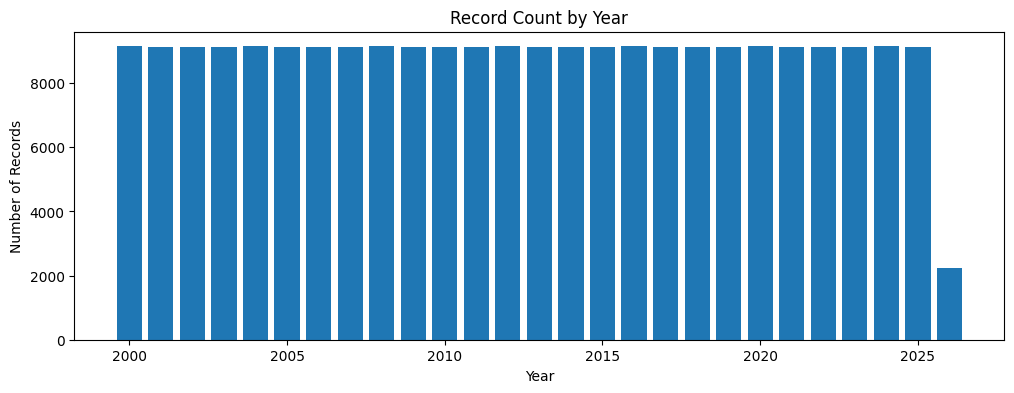

In [5]:
yearly_counts = df.groupby("year").size().reset_index(name="records")
print(yearly_counts.tail())

plt.figure(figsize=(12, 4))
plt.bar(yearly_counts["year"], yearly_counts["records"])
plt.title("Record Count by Year")
plt.xlabel("Year")
plt.ylabel("Number of Records")
plt.show()

# 3. Descriptive Statistics and Dataset Overview

This section gives a quick overview of rainfall variables and risk labels.

In [6]:
rain_cols = [
    "avg_rainfall_mm", "max_rainfall_mm", "min_rainfall_mm", "median_rainfall_mm",
    "rainy_grid_ratio", "heavy_grid_ratio", "very_heavy_grid_ratio"
]

df[rain_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
avg_rainfall_mm,239675.0,7.984943,10.331647,0.0,0.455342,5.052830,11.586572,279.69230
max_rainfall_mm,239675.0,15.727537,16.228410,0.0,4.862868,12.428917,21.997469,325.64304
min_rainfall_mm,239675.0,3.179533,6.511086,0.0,0.000000,0.000000,4.789953,238.93277
median_rainfall_mm,239675.0,7.609592,10.458843,0.0,0.000000,4.929940,11.472392,278.02597
rainy_grid_ratio,239675.0,0.589932,0.421558,0.0,0.076923,0.764045,1.000000,1.00000
heavy_grid_ratio,239675.0,0.037276,0.151150,0.0,0.000000,0.000000,0.000000,1.00000
very_heavy_grid_ratio,239675.0,0.005523,0.060280,0.0,0.000000,0.000000,0.000000,1.00000


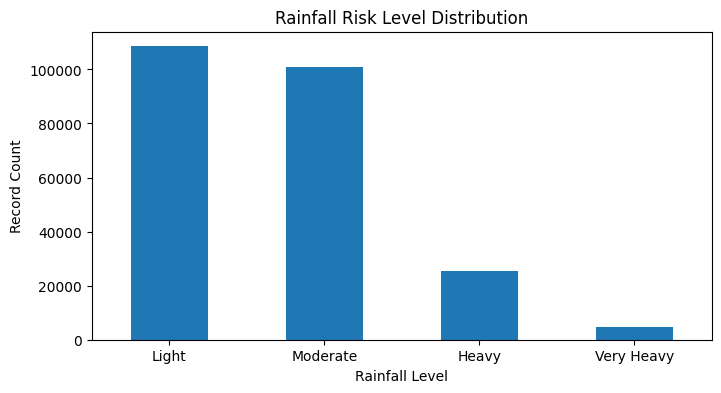

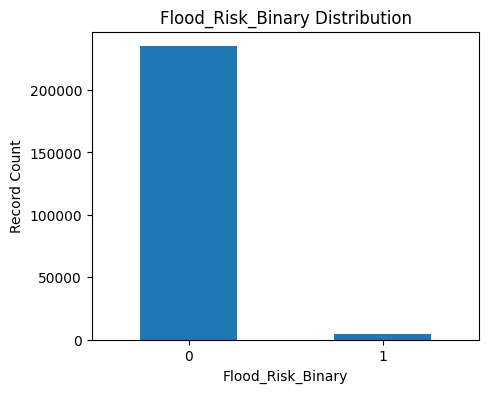

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
df["rainfall_risk_level"].value_counts().reindex(["Light", "Moderate", "Heavy", "Very Heavy"]).plot(kind="bar", ax=ax)
ax.set_title("Rainfall Risk Level Distribution")
ax.set_xlabel("Rainfall Level")
ax.set_ylabel("Record Count")
plt.xticks(rotation=0)
plt.show()

fig, ax = plt.subplots(figsize=(5, 4))
df["Flood_Risk_Binary"].value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_title("Flood_Risk_Binary Distribution")
ax.set_xlabel("Flood_Risk_Binary")
ax.set_ylabel("Record Count")
plt.xticks(rotation=0)
plt.show()

# 4. Univariate EDA

Univariate analysis studies one variable at a time.

We focus on rainfall distributions, outliers, and risk-label imbalance.

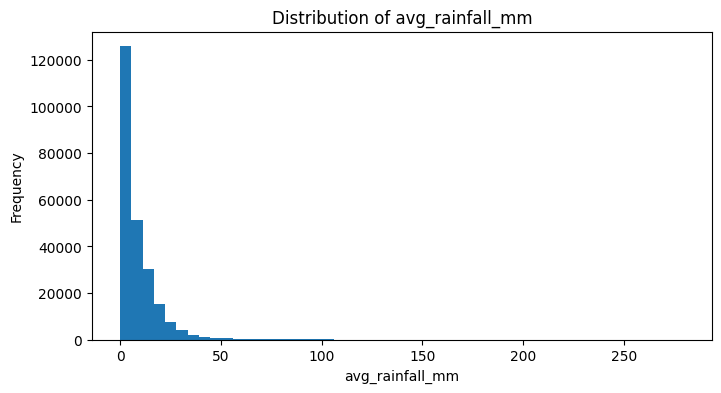

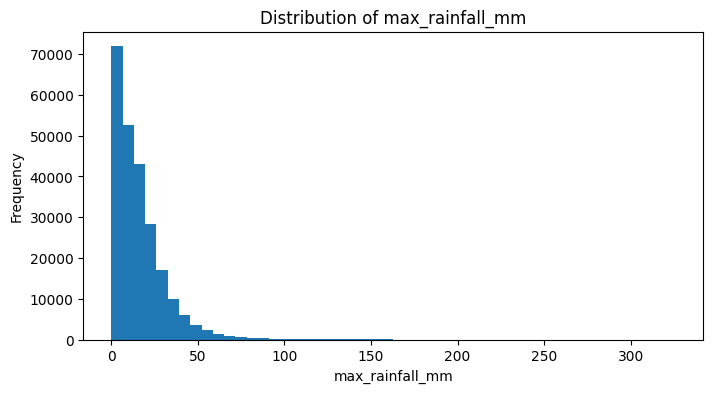

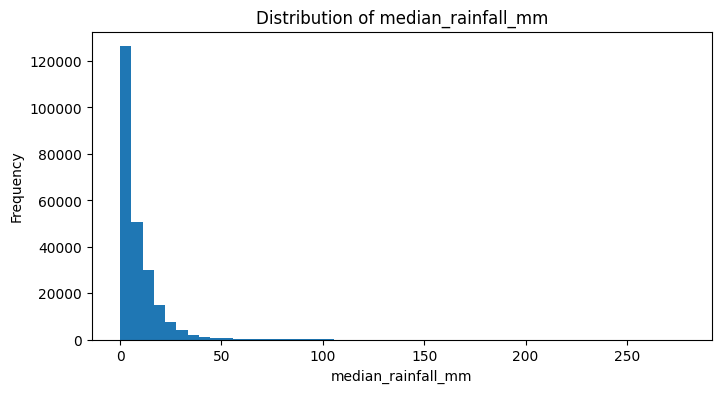

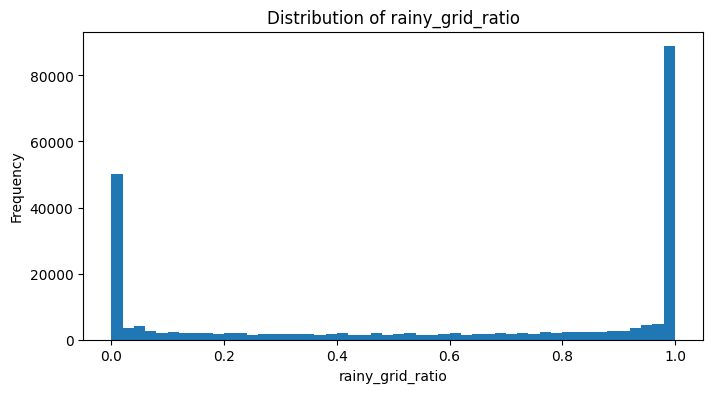

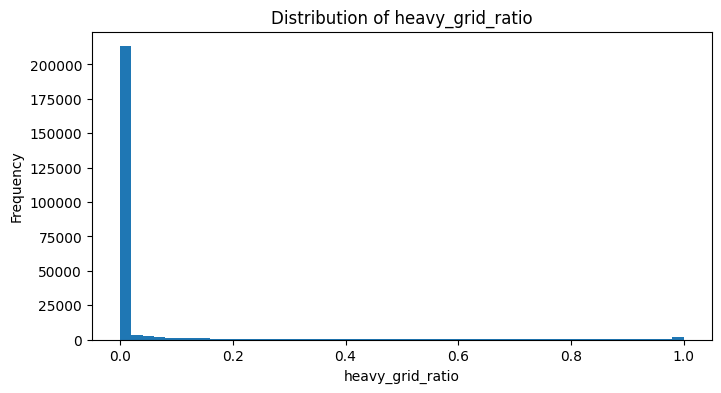

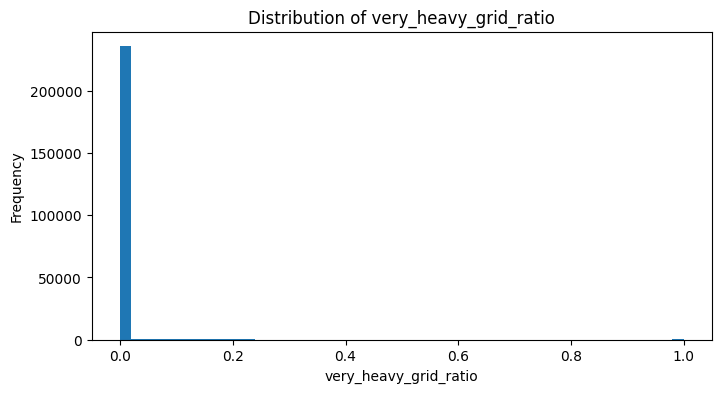

In [8]:
for col in ["avg_rainfall_mm", "max_rainfall_mm", "median_rainfall_mm", "rainy_grid_ratio", "heavy_grid_ratio", "very_heavy_grid_ratio"]:
    plt.figure(figsize=(8, 4))
    plt.hist(df[col], bins=50)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

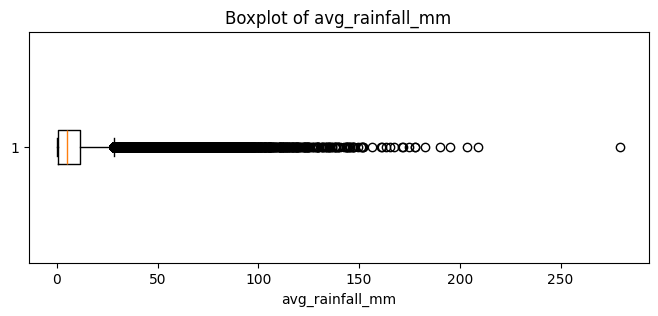

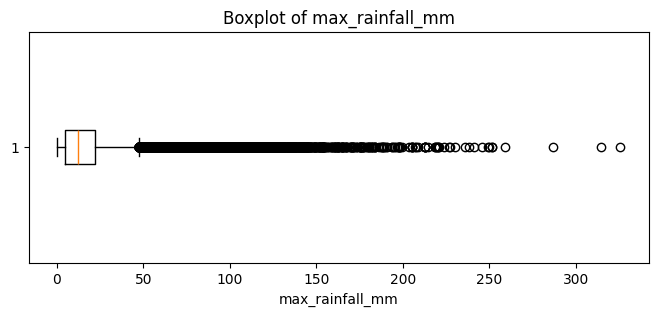

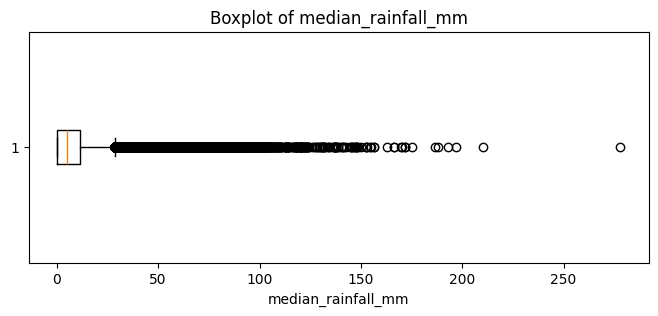

In [9]:
for col in ["avg_rainfall_mm", "max_rainfall_mm", "median_rainfall_mm"]:
    plt.figure(figsize=(8, 3))
    plt.boxplot(df[col], vert=False)
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

# 5. Temporal EDA: Yearly, Monthly, Quarterly, Seasonal Analysis

This section studies time patterns.

For full-year trend analysis, we usually use 2000–2025 because 2026 is partial.

In [10]:
df_full_years = df[df["year"] <= 2025].copy()

yearly = df_full_years.groupby("year").agg(
    avg_rainfall=("avg_rainfall_mm", "mean"),
    max_rainfall=("max_rainfall_mm", "max"),
    flood_risk_days=("Flood_Risk_Binary", "sum"),
    very_heavy_rate=("Flood_Risk_Binary", "mean"),
).reset_index()

yearly.head()

,year,avg_rainfall,max_rainfall,flood_risk_days,very_heavy_rate
0,2000,8.168334,180.25546,158,0.017268
1,2001,7.924159,259.25003,149,0.016329
2,2002,6.910016,227.36317,121,0.013260
3,2003,8.167979,286.76425,197,0.021589
4,2004,7.318621,182.24277,152,0.016612


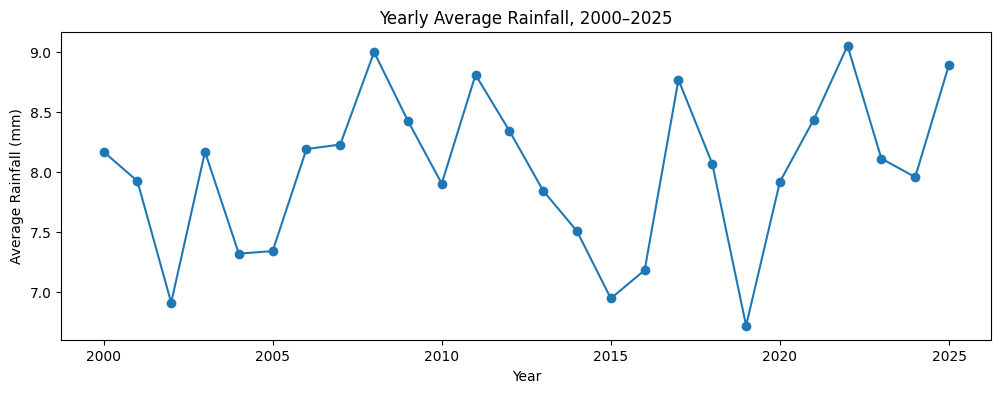

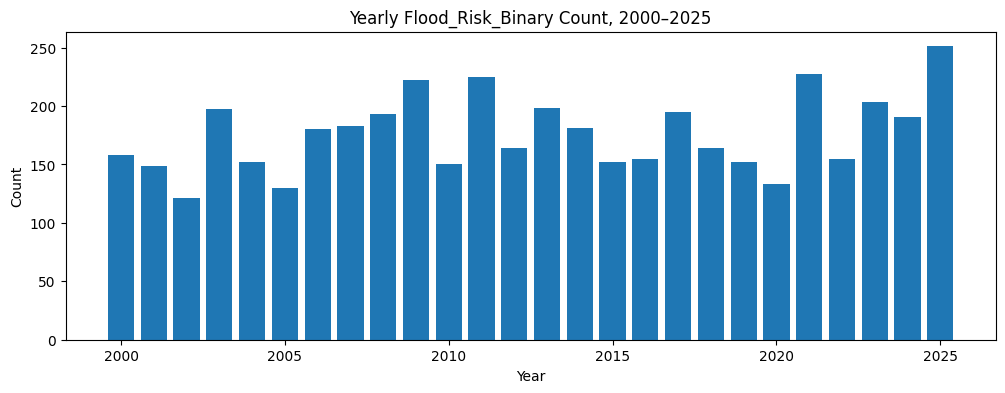

In [11]:
plt.figure(figsize=(12, 4))
plt.plot(yearly["year"], yearly["avg_rainfall"], marker="o")
plt.title("Yearly Average Rainfall, 2000–2025")
plt.xlabel("Year")
plt.ylabel("Average Rainfall (mm)")
plt.show()

plt.figure(figsize=(12, 4))
plt.bar(yearly["year"], yearly["flood_risk_days"])
plt.title("Yearly Flood_Risk_Binary Count, 2000–2025")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

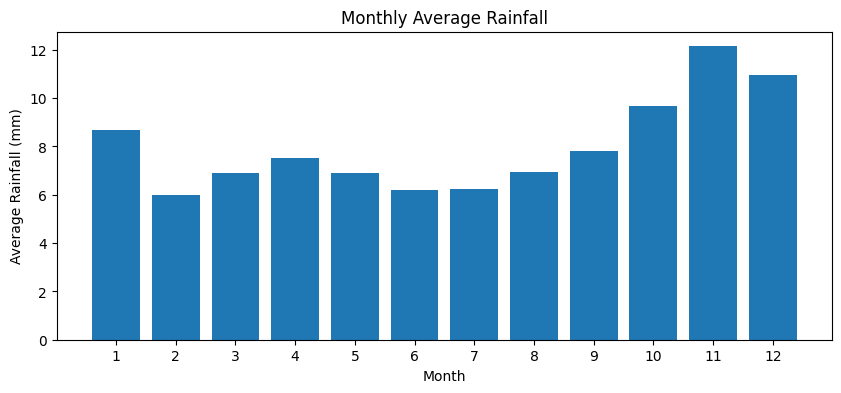

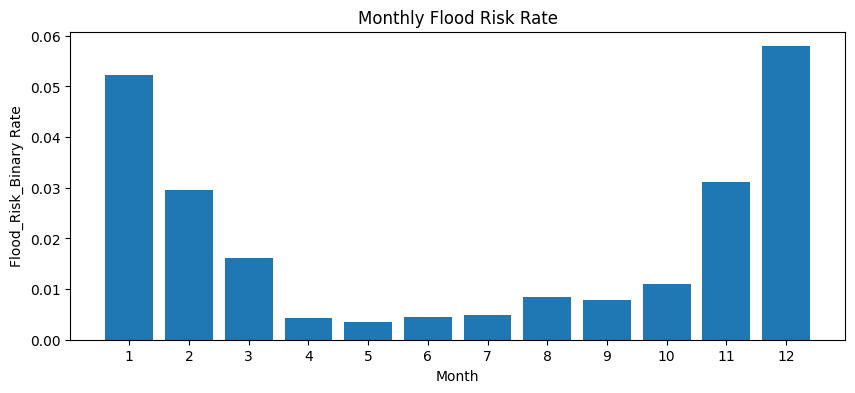

In [12]:
monthly = df_full_years.groupby("month").agg(
    avg_rainfall=("avg_rainfall_mm", "mean"),
    flood_risk_rate=("Flood_Risk_Binary", "mean"),
    max_rainfall=("max_rainfall_mm", "max")
).reset_index()

plt.figure(figsize=(10, 4))
plt.bar(monthly["month"], monthly["avg_rainfall"])
plt.title("Monthly Average Rainfall")
plt.xlabel("Month")
plt.ylabel("Average Rainfall (mm)")
plt.xticks(range(1, 13))
plt.show()

plt.figure(figsize=(10, 4))
plt.bar(monthly["month"], monthly["flood_risk_rate"])
plt.title("Monthly Flood Risk Rate")
plt.xlabel("Month")
plt.ylabel("Flood_Risk_Binary Rate")
plt.xticks(range(1, 13))
plt.show()

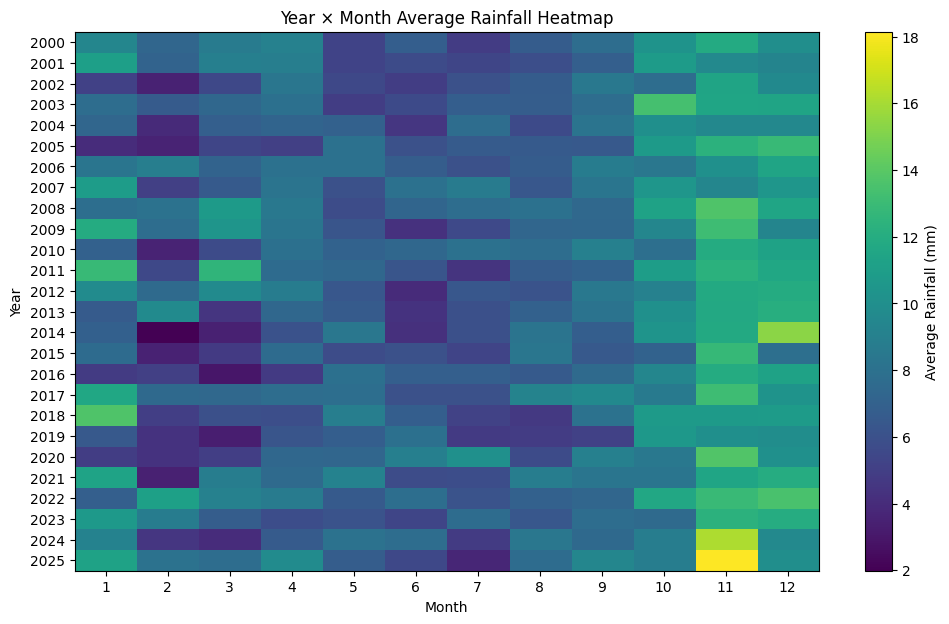

In [13]:
heat = df_full_years.groupby(["year", "month"])["avg_rainfall_mm"].mean().unstack()

plt.figure(figsize=(12, 7))
plt.imshow(heat, aspect="auto")
plt.title("Year × Month Average Rainfall Heatmap")
plt.xlabel("Month")
plt.ylabel("Year")
plt.xticks(range(12), range(1, 13))
plt.yticks(range(len(heat.index)), heat.index)
plt.colorbar(label="Average Rainfall (mm)")
plt.show()

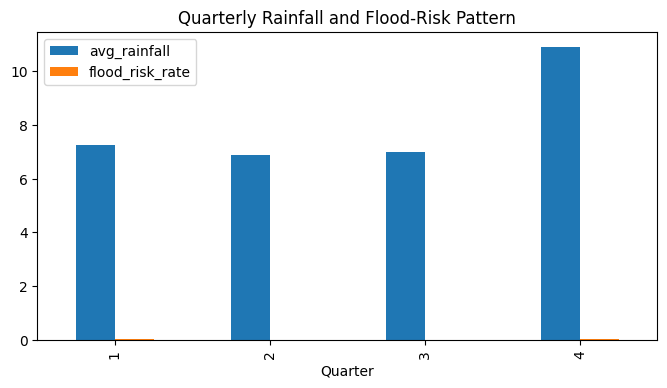

In [14]:
df_full_years["quarter"] = df_full_years["date"].dt.quarter
quarterly = df_full_years.groupby("quarter").agg(
    avg_rainfall=("avg_rainfall_mm", "mean"),
    flood_risk_rate=("Flood_Risk_Binary", "mean")
).reset_index()

quarterly.plot(x="quarter", y=["avg_rainfall", "flood_risk_rate"], kind="bar", figsize=(8, 4))
plt.title("Quarterly Rainfall and Flood-Risk Pattern")
plt.xlabel("Quarter")
plt.show()

# 6. Spatial / City-Level EDA

This section compares cities and states.

In [15]:
city_summary = df_full_years.groupby(["state", "city"]).agg(
    avg_rainfall=("avg_rainfall_mm", "mean"),
    max_rainfall=("max_rainfall_mm", "max"),
    flood_risk_rate=("Flood_Risk_Binary", "mean"),
    flood_risk_count=("Flood_Risk_Binary", "sum")
).reset_index()

city_summary.sort_values("flood_risk_rate", ascending=False).head(10)

,state,city,avg_rainfall,max_rainfall,flood_risk_rate,flood_risk_count
10,Sabah,Sandakan,9.017556,314.60922,0.065705,624
21,Terengganu,Kuala Terengganu,9.483588,325.64304,0.063915,607
2,Kelantan,Kota Bharu,8.350887,238.11993,0.051701,491
13,Sarawak,Kuching,11.624039,180.25546,0.049279,468
5,Pahang,Kuantan,8.565968,286.76425,0.045277,430
12,Sarawak,Bintulu,10.701821,145.26625,0.029483,280
9,Sabah,Kota Kinabalu,8.010209,145.70964,0.027693,263
23,WP Labuan,Labuan,9.449661,197.33595,0.027693,263
15,Sarawak,Sibu,10.155075,152.27940,0.027693,263
0,Johor,Johor Bahru,7.116277,182.24277,0.015163,144


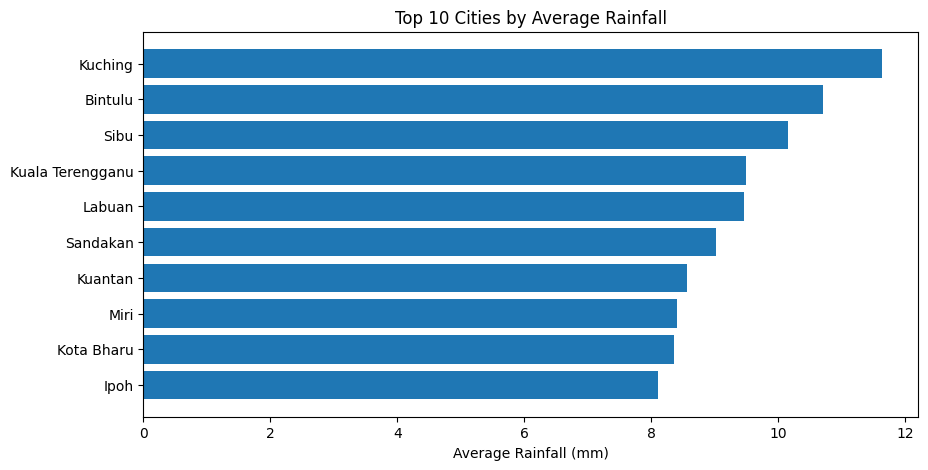

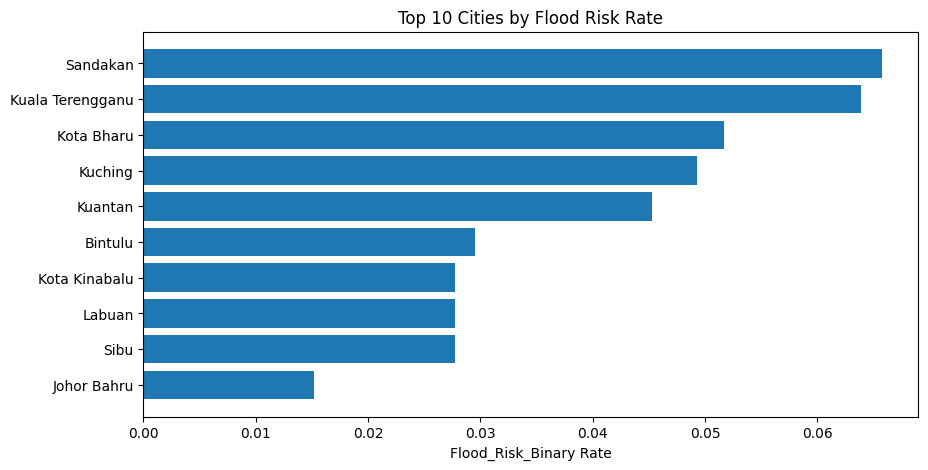

In [16]:
top_avg = city_summary.sort_values("avg_rainfall", ascending=False).head(10)
plt.figure(figsize=(10, 5))
plt.barh(top_avg["city"], top_avg["avg_rainfall"])
plt.gca().invert_yaxis()
plt.title("Top 10 Cities by Average Rainfall")
plt.xlabel("Average Rainfall (mm)")
plt.show()

top_risk = city_summary.sort_values("flood_risk_rate", ascending=False).head(10)
plt.figure(figsize=(10, 5))
plt.barh(top_risk["city"], top_risk["flood_risk_rate"])
plt.gca().invert_yaxis()
plt.title("Top 10 Cities by Flood Risk Rate")
plt.xlabel("Flood_Risk_Binary Rate")
plt.show()

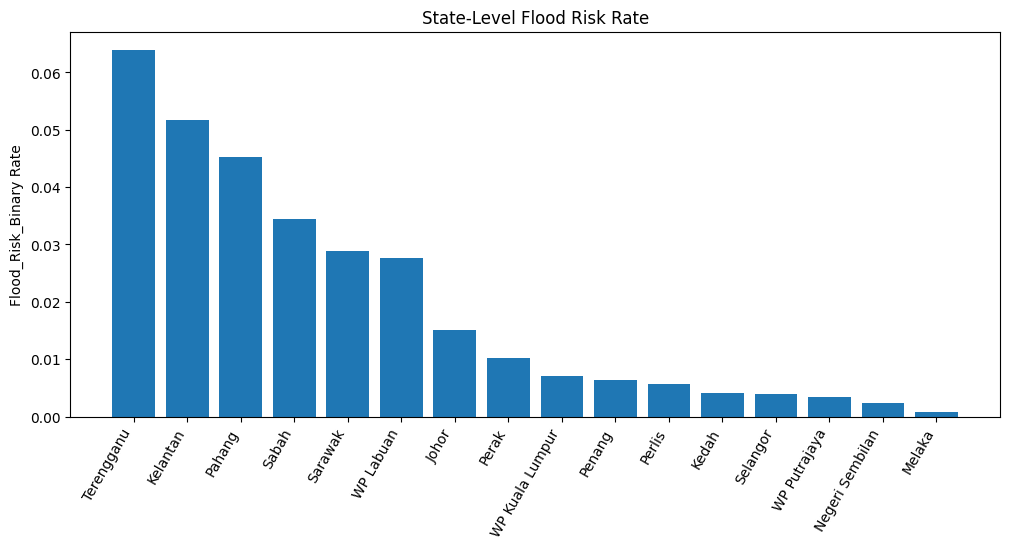

In [17]:
state_summary = df_full_years.groupby("state").agg(
    avg_rainfall=("avg_rainfall_mm", "mean"),
    flood_risk_rate=("Flood_Risk_Binary", "mean")
).reset_index().sort_values("flood_risk_rate", ascending=False)

plt.figure(figsize=(12, 5))
plt.bar(state_summary["state"], state_summary["flood_risk_rate"])
plt.xticks(rotation=60, ha="right")
plt.title("State-Level Flood Risk Rate")
plt.ylabel("Flood_Risk_Binary Rate")
plt.show()

# 7. Correlation and Feature Relationship Analysis

This section studies how rainfall variables relate to each other and to flood-risk signals.

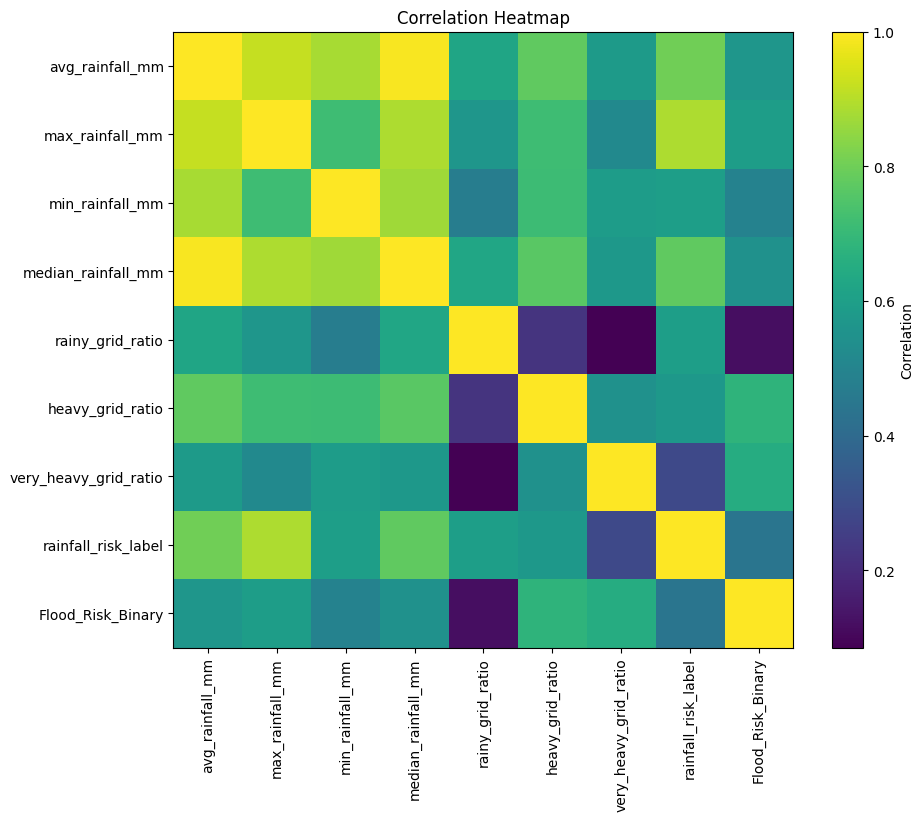

Flood_Risk_Binary        1.000000
heavy_grid_ratio         0.679884
very_heavy_grid_ratio    0.650312
max_rainfall_mm          0.593244
avg_rainfall_mm          0.566667
median_rainfall_mm       0.549552
min_rainfall_mm          0.489645
rainfall_risk_label      0.439847
rainy_grid_ratio         0.119303
Name: Flood_Risk_Binary, dtype: float64

In [18]:
corr_cols = [
    "avg_rainfall_mm", "max_rainfall_mm", "min_rainfall_mm", "median_rainfall_mm",
    "rainy_grid_ratio", "heavy_grid_ratio", "very_heavy_grid_ratio",
    "rainfall_risk_label", "Flood_Risk_Binary"
]
corr = df_full_years[corr_cols].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_cols)), corr_cols, rotation=90)
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title("Correlation Heatmap")
plt.show()

corr["Flood_Risk_Binary"].sort_values(ascending=False)

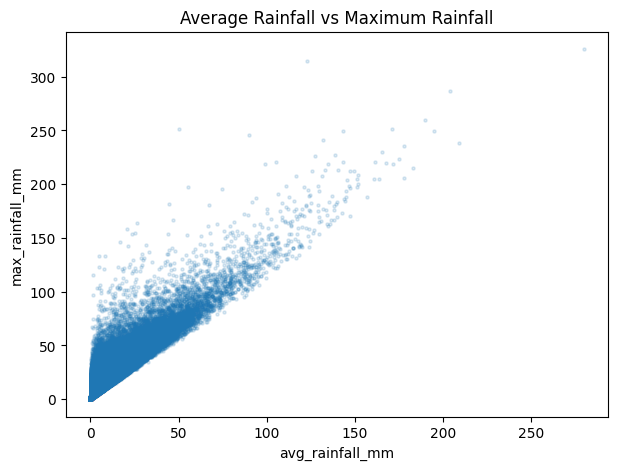

<Figure size 800x400 with 0 Axes>

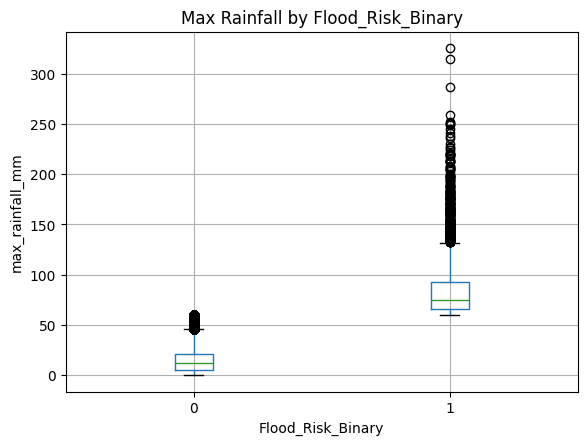

In [19]:
plt.figure(figsize=(7, 5))
plt.scatter(df_full_years["avg_rainfall_mm"], df_full_years["max_rainfall_mm"], alpha=0.15, s=5)
plt.title("Average Rainfall vs Maximum Rainfall")
plt.xlabel("avg_rainfall_mm")
plt.ylabel("max_rainfall_mm")
plt.show()

plt.figure(figsize=(8, 4))
df_full_years.boxplot(column="max_rainfall_mm", by="Flood_Risk_Binary")
plt.title("Max Rainfall by Flood_Risk_Binary")
plt.suptitle("")
plt.xlabel("Flood_Risk_Binary")
plt.ylabel("max_rainfall_mm")
plt.show()

Saving notebook EDA outputs to:
/scr/user/kevin2002/TensorCat/Data Analysis/Group_Project/Data/Outputs


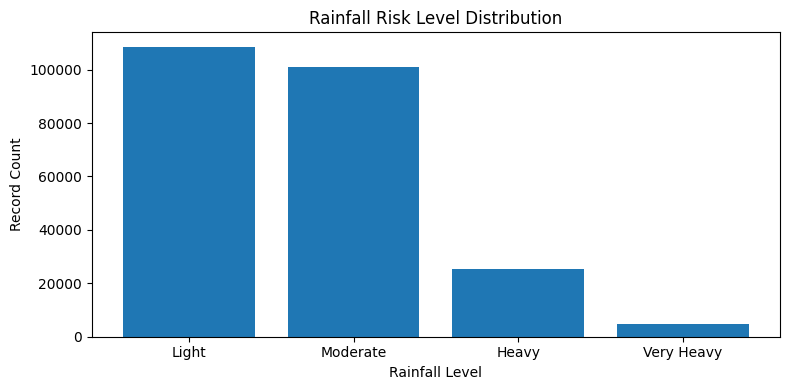

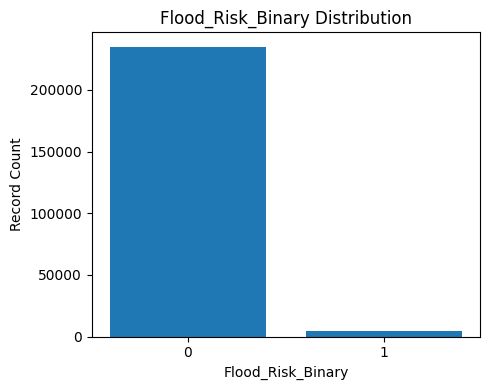

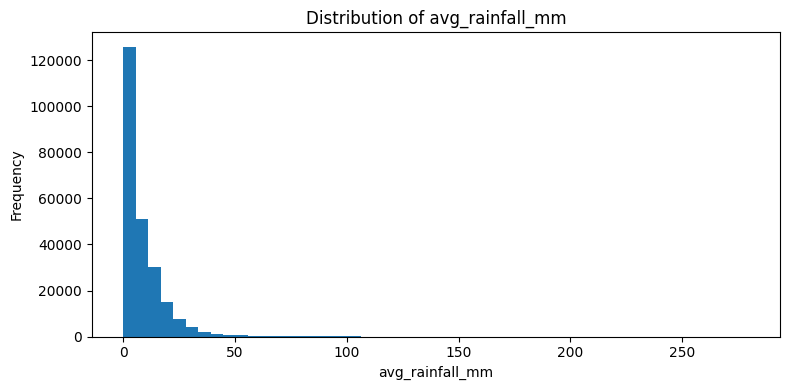

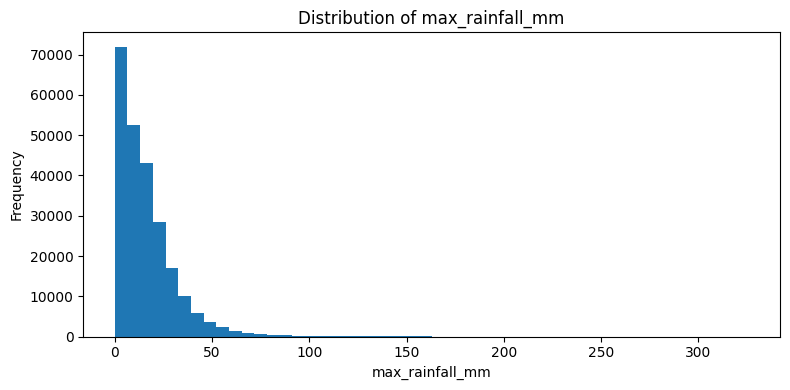

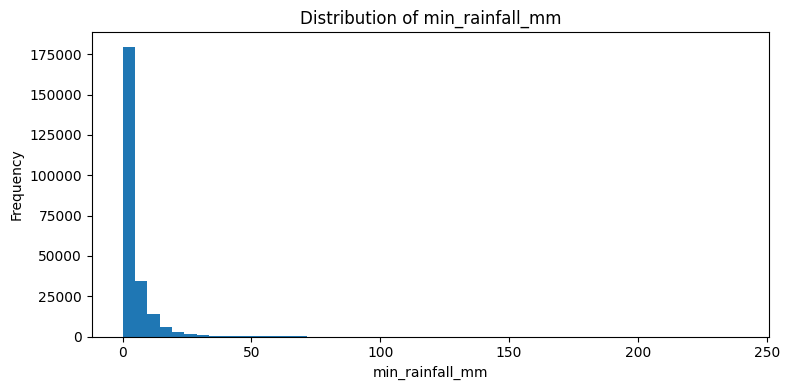

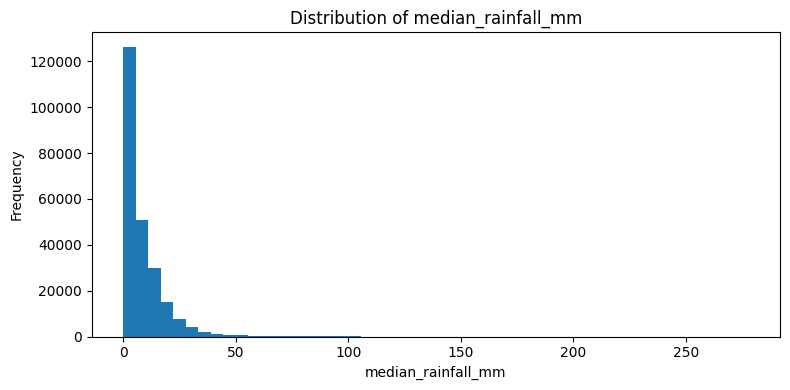

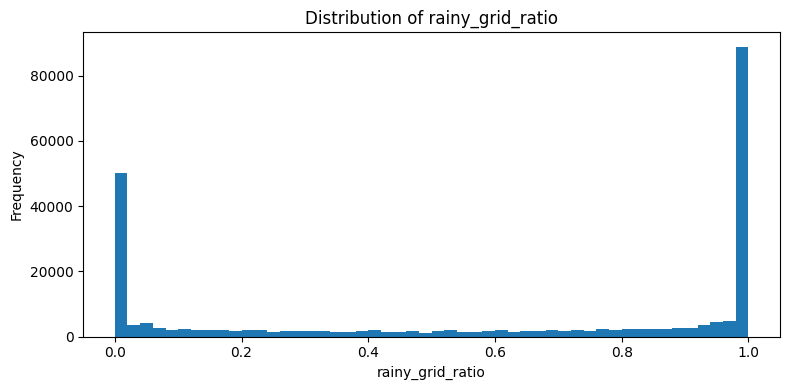

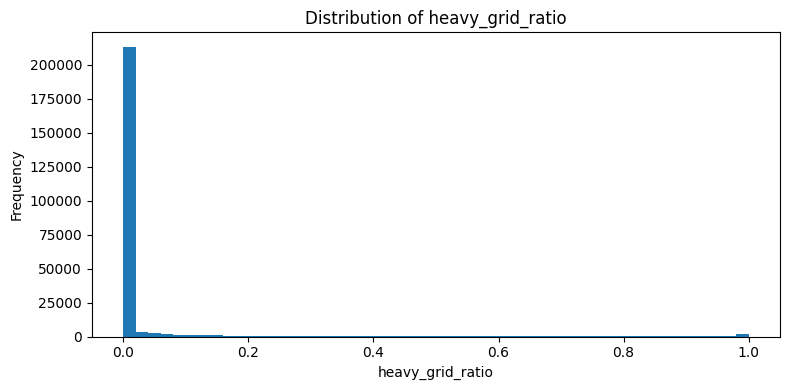

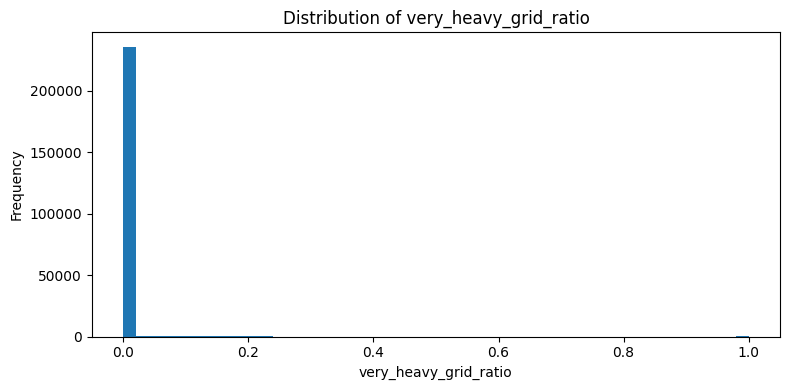

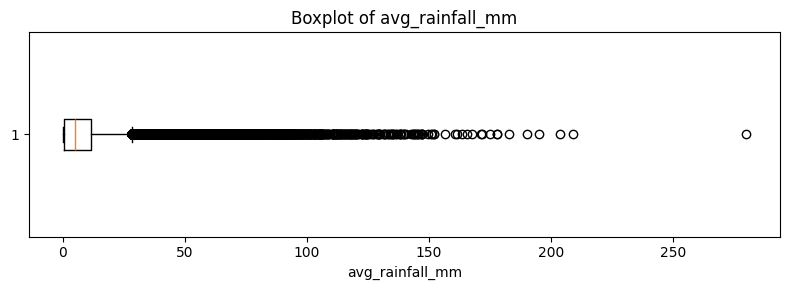

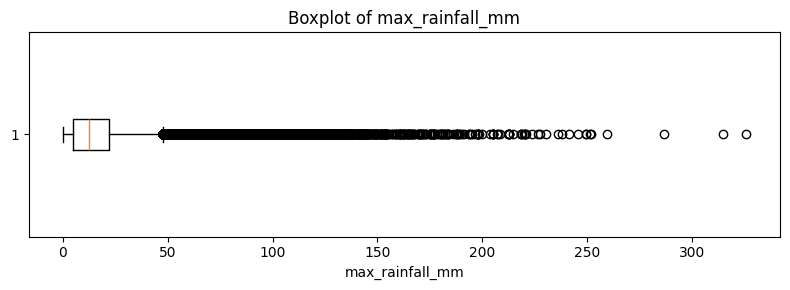

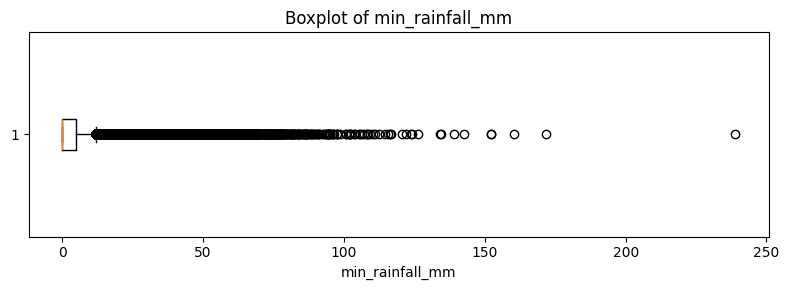

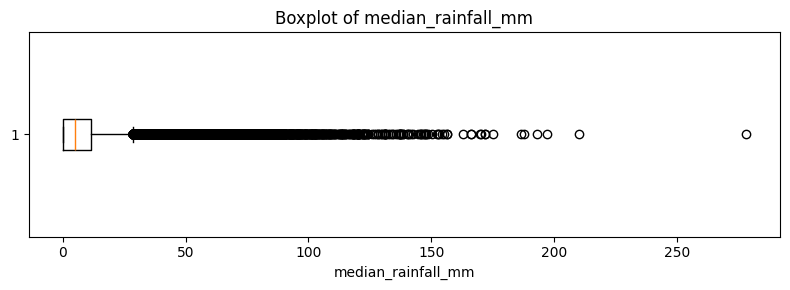

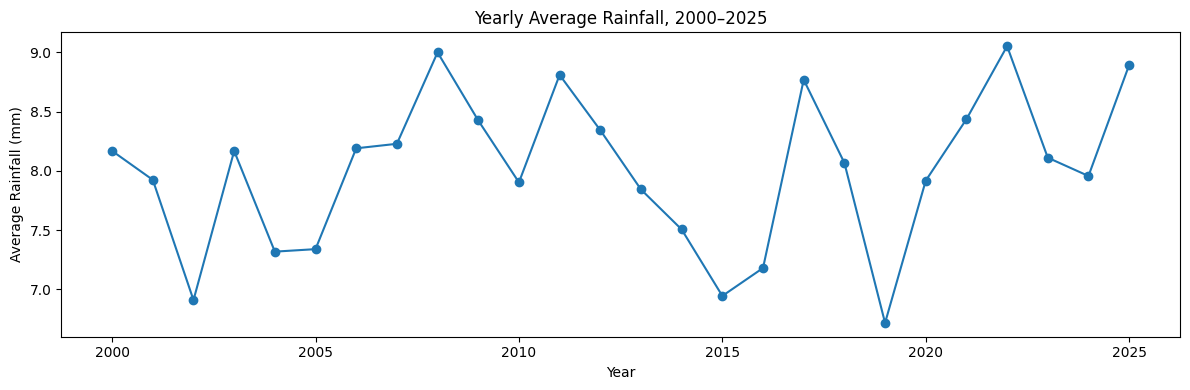

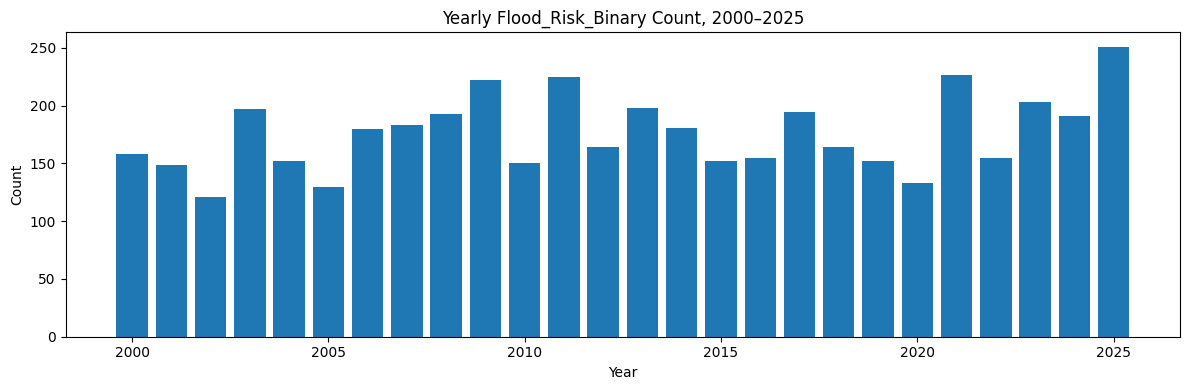

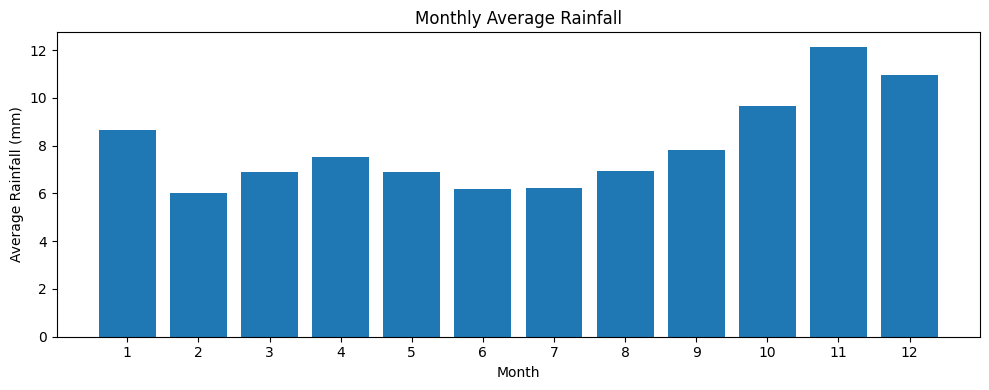

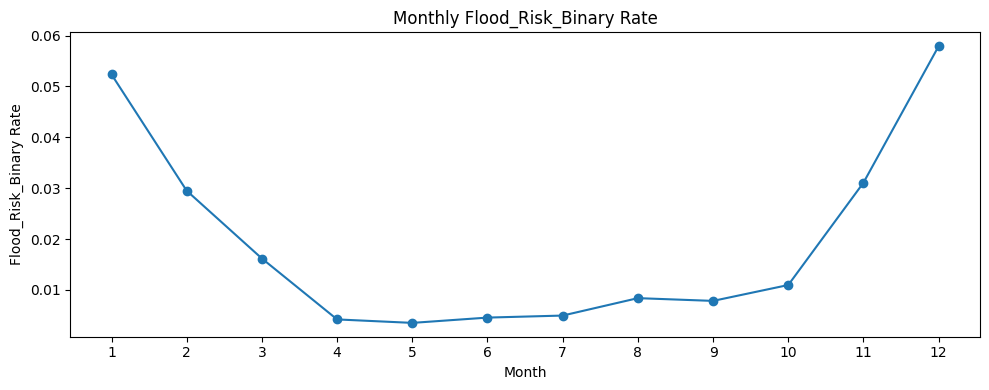

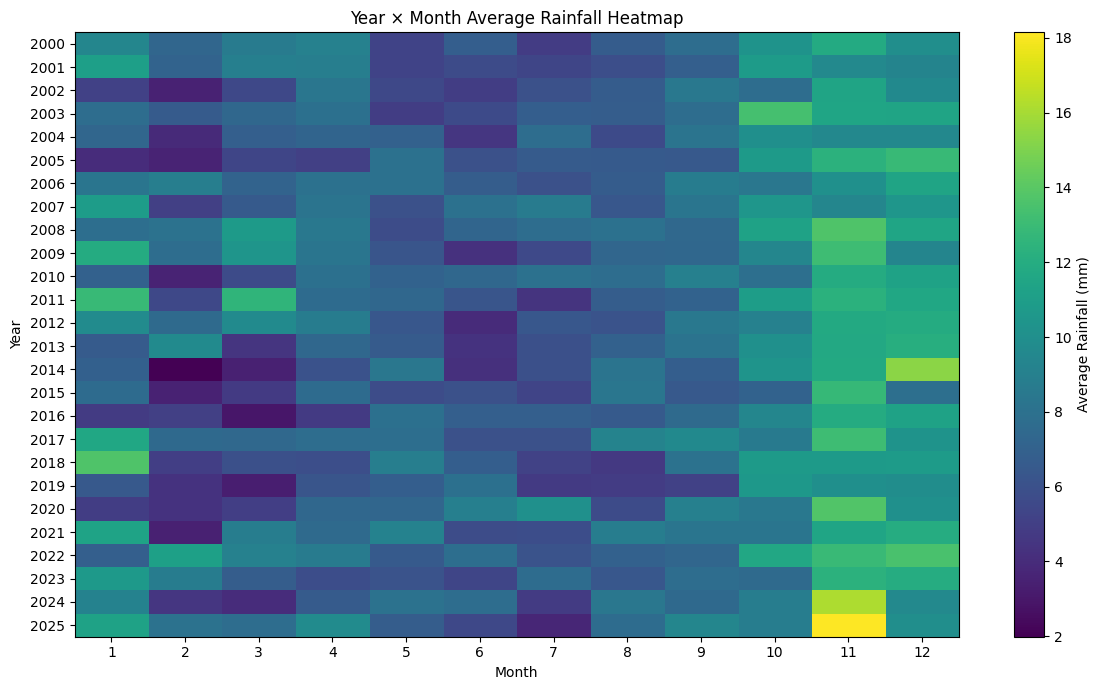

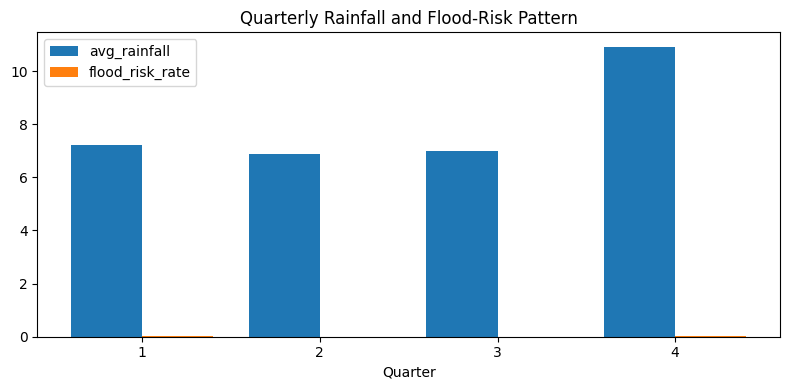

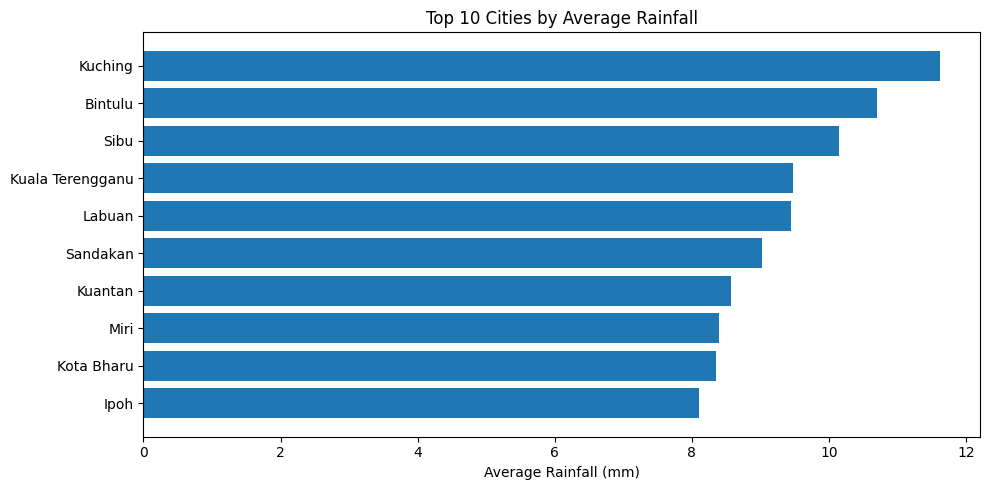

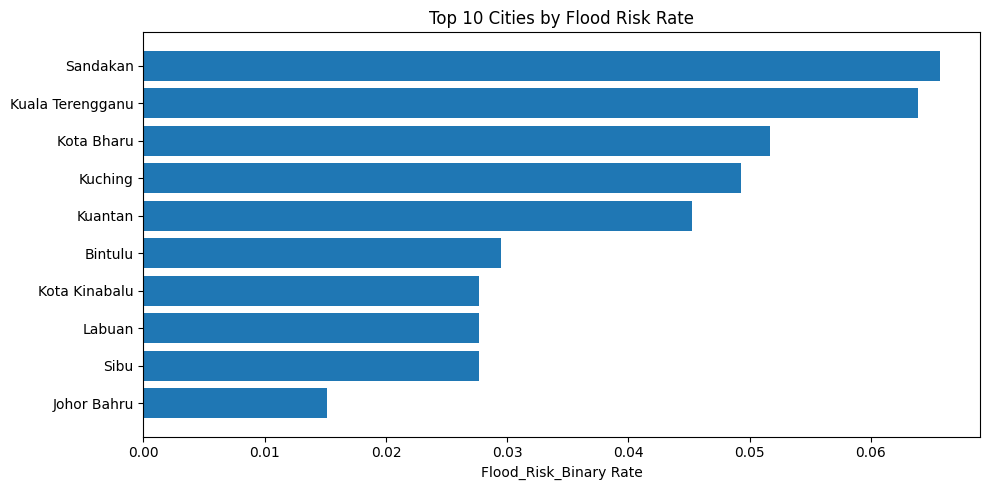

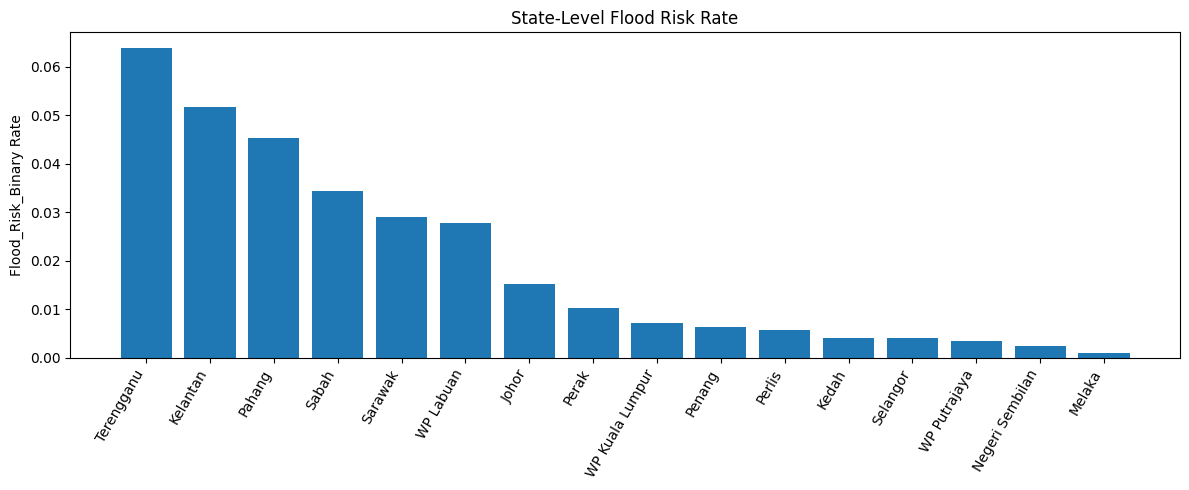

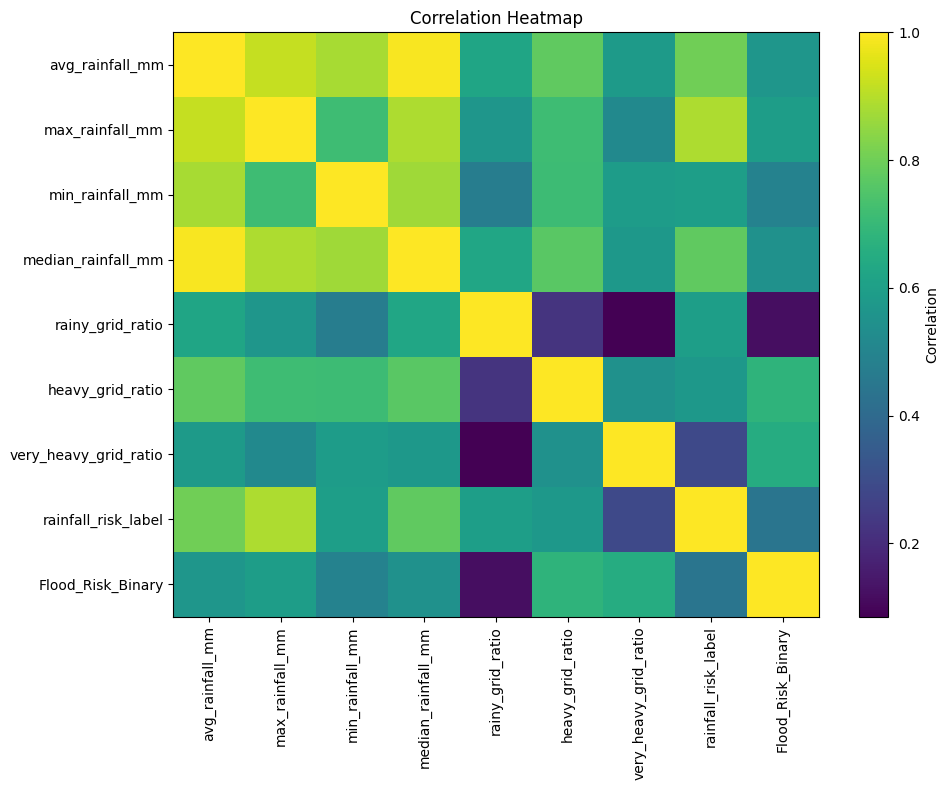

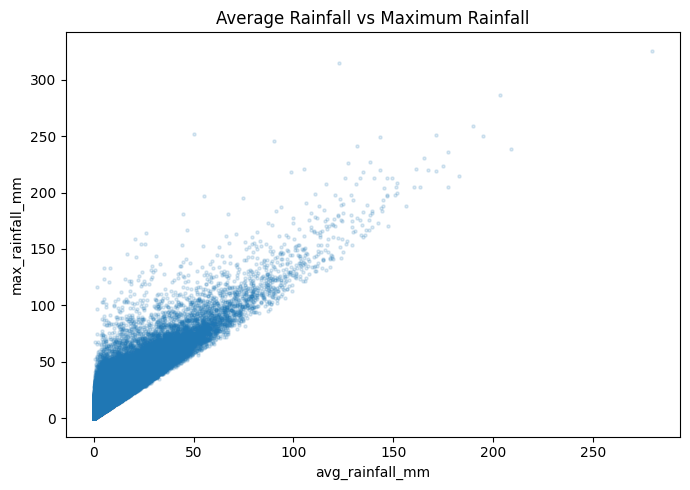

<Figure size 800x400 with 0 Axes>

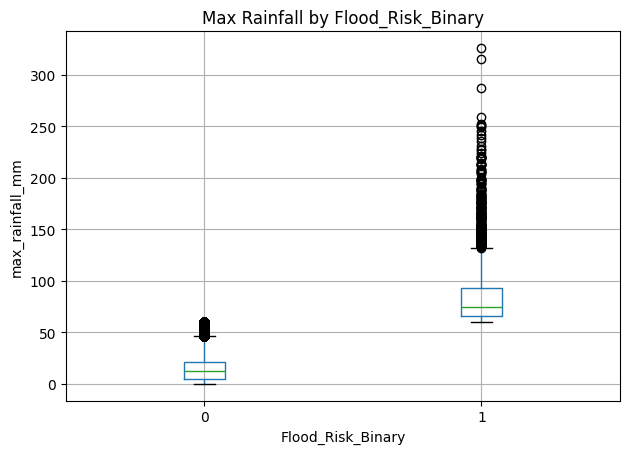


Comprehensive EDA outputs saved successfully.
Folders created/updated:
- /scr/user/kevin2002/TensorCat/Data Analysis/Group_Project/Data/Outputs/Univariate_EDA
- /scr/user/kevin2002/TensorCat/Data Analysis/Group_Project/Data/Outputs/Temporal_EDA
- /scr/user/kevin2002/TensorCat/Data Analysis/Group_Project/Data/Outputs/Spatial_City_EDA
- /scr/user/kevin2002/TensorCat/Data Analysis/Group_Project/Data/Outputs/Correlation_Analysis


In [20]:
# =========================================================
# Comprehensive EDA Output Export
# =========================================================
# This cell makes the notebook output behavior consistent with the standalone .py scripts.
# It saves the major EDA tables and figures into organized folders under Outputs/.
#
# Why this cell exists:
# - Earlier EDA cells mainly displayed plots inside the notebook.
# - This export cell also writes those results to disk, so DICC/Jupyter Outputs
#   will contain the same kinds of files as the local .py workflow.
# =========================================================

import matplotlib.pyplot as plt

# Make sure full-year dataframe exists.
if "df_full_years" not in globals():
    df_full_years = df[df["year"] <= 2025].copy()

DESCRIPTIVE_DIR = OUTPUT_DIR
UNIVARIATE_DIR = OUTPUT_DIR / "Univariate_EDA"
TEMPORAL_DIR = OUTPUT_DIR / "Temporal_EDA"
SPATIAL_DIR = OUTPUT_DIR / "Spatial_City_EDA"
CORRELATION_DIR = OUTPUT_DIR / "Correlation_Analysis"

for folder in [UNIVARIATE_DIR, TEMPORAL_DIR, SPATIAL_DIR, CORRELATION_DIR]:
    folder.mkdir(parents=True, exist_ok=True)


def save_and_show(path, dpi=200):
    """Save current matplotlib figure and then display it."""
    plt.tight_layout()
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    plt.show()


print("Saving notebook EDA outputs to:")
print(OUTPUT_DIR)

# ---------------------------------------------------------
# 1) Descriptive / overview outputs
# ---------------------------------------------------------
overview_rows = [
    {"metric": "records", "value": len(df)},
    {"metric": "columns", "value": df.shape[1]},
    {"metric": "start_date", "value": str(df["date"].min())},
    {"metric": "end_date", "value": str(df["date"].max())},
    {"metric": "cities", "value": df["city"].nunique()},
    {"metric": "states", "value": df["state"].nunique()},
    {"metric": "min_year", "value": int(df["year"].min())},
    {"metric": "max_year", "value": int(df["year"].max())},
]
overview_df = pd.DataFrame(overview_rows)
overview_df.to_csv(OUTPUT_DIR / "dataset_overview_summary.csv", index=False)

rain_cols_export = [
    "avg_rainfall_mm",
    "max_rainfall_mm",
    "min_rainfall_mm",
    "median_rainfall_mm",
    "rainy_grid_ratio",
    "heavy_grid_ratio",
    "very_heavy_grid_ratio",
]
df[rain_cols_export].describe().T.to_csv(OUTPUT_DIR / "descriptive_statistics_rainfall.csv")

risk_level_counts = (
    df["rainfall_risk_level"]
    .value_counts()
    .reindex(["Light", "Moderate", "Heavy", "Very Heavy"])
    .fillna(0)
    .astype(int)
    .reset_index()
)
risk_level_counts.columns = ["rainfall_risk_level", "records"]
risk_level_counts.to_csv(OUTPUT_DIR / "risk_level_counts.csv", index=False)

flood_binary_counts = (
    df["Flood_Risk_Binary"]
    .value_counts()
    .sort_index()
    .reset_index()
)
flood_binary_counts.columns = ["Flood_Risk_Binary", "records"]
flood_binary_counts.to_csv(OUTPUT_DIR / "flood_risk_binary_counts.csv", index=False)

plt.figure(figsize=(8, 4))
plt.bar(risk_level_counts["rainfall_risk_level"], risk_level_counts["records"])
plt.title("Rainfall Risk Level Distribution")
plt.xlabel("Rainfall Level")
plt.ylabel("Record Count")
plt.xticks(rotation=0)
save_and_show(OUTPUT_DIR / "risk_level_distribution.png")

plt.figure(figsize=(5, 4))
plt.bar(flood_binary_counts["Flood_Risk_Binary"].astype(str), flood_binary_counts["records"])
plt.title("Flood_Risk_Binary Distribution")
plt.xlabel("Flood_Risk_Binary")
plt.ylabel("Record Count")
save_and_show(OUTPUT_DIR / "flood_risk_binary_distribution.png")

# ---------------------------------------------------------
# 2) Univariate EDA outputs
# ---------------------------------------------------------
for col in rain_cols_export:
    plt.figure(figsize=(8, 4))
    plt.hist(df[col], bins=50)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    save_and_show(UNIVARIATE_DIR / f"hist_{col}.png")

for col in ["avg_rainfall_mm", "max_rainfall_mm", "min_rainfall_mm", "median_rainfall_mm"]:
    plt.figure(figsize=(8, 3))
    plt.boxplot(df[col], vert=False)
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    save_and_show(UNIVARIATE_DIR / f"boxplot_{col}.png")

# ---------------------------------------------------------
# 3) Temporal EDA outputs
# ---------------------------------------------------------
yearly_eda = df_full_years.groupby("year").agg(
    avg_rainfall=("avg_rainfall_mm", "mean"),
    max_rainfall=("max_rainfall_mm", "max"),
    flood_risk_days=("Flood_Risk_Binary", "sum"),
    very_heavy_rate=("Flood_Risk_Binary", "mean"),
).reset_index()
yearly_eda.to_csv(TEMPORAL_DIR / "yearly_rainfall_flood_summary.csv", index=False)

plt.figure(figsize=(12, 4))
plt.plot(yearly_eda["year"], yearly_eda["avg_rainfall"], marker="o")
plt.title("Yearly Average Rainfall, 2000–2025")
plt.xlabel("Year")
plt.ylabel("Average Rainfall (mm)")
save_and_show(TEMPORAL_DIR / "yearly_average_rainfall.png")

plt.figure(figsize=(12, 4))
plt.bar(yearly_eda["year"], yearly_eda["flood_risk_days"])
plt.title("Yearly Flood_Risk_Binary Count, 2000–2025")
plt.xlabel("Year")
plt.ylabel("Count")
save_and_show(TEMPORAL_DIR / "yearly_flood_risk_binary_count.png")

monthly_eda = df_full_years.groupby("month").agg(
    avg_rainfall=("avg_rainfall_mm", "mean"),
    flood_risk_rate=("Flood_Risk_Binary", "mean"),
    max_rainfall=("max_rainfall_mm", "max"),
).reset_index()
monthly_eda.to_csv(TEMPORAL_DIR / "monthly_rainfall_flood_summary.csv", index=False)

plt.figure(figsize=(10, 4))
plt.bar(monthly_eda["month"], monthly_eda["avg_rainfall"])
plt.title("Monthly Average Rainfall")
plt.xlabel("Month")
plt.ylabel("Average Rainfall (mm)")
plt.xticks(range(1, 13))
save_and_show(TEMPORAL_DIR / "monthly_average_rainfall.png")

plt.figure(figsize=(10, 4))
plt.plot(monthly_eda["month"], monthly_eda["flood_risk_rate"], marker="o")
plt.title("Monthly Flood_Risk_Binary Rate")
plt.xlabel("Month")
plt.ylabel("Flood_Risk_Binary Rate")
plt.xticks(range(1, 13))
save_and_show(TEMPORAL_DIR / "monthly_flood_risk_rate.png")

heat = df_full_years.groupby(["year", "month"])["avg_rainfall_mm"].mean().unstack()
heat.to_csv(TEMPORAL_DIR / "year_month_average_rainfall_matrix.csv")

plt.figure(figsize=(12, 7))
plt.imshow(heat, aspect="auto")
plt.title("Year × Month Average Rainfall Heatmap")
plt.xlabel("Month")
plt.ylabel("Year")
plt.xticks(range(12), range(1, 13))
plt.yticks(range(len(heat.index)), heat.index)
plt.colorbar(label="Average Rainfall (mm)")
save_and_show(TEMPORAL_DIR / "year_month_average_rainfall_heatmap.png")

df_quarter = df_full_years.copy()
df_quarter["quarter"] = df_quarter["date"].dt.quarter
quarterly_eda = df_quarter.groupby("quarter").agg(
    avg_rainfall=("avg_rainfall_mm", "mean"),
    flood_risk_rate=("Flood_Risk_Binary", "mean"),
).reset_index()
quarterly_eda.to_csv(TEMPORAL_DIR / "quarterly_rainfall_flood_summary.csv", index=False)

plt.figure(figsize=(8, 4))
x = np.arange(len(quarterly_eda))
plt.bar(x - 0.2, quarterly_eda["avg_rainfall"], width=0.4, label="avg_rainfall")
plt.bar(x + 0.2, quarterly_eda["flood_risk_rate"], width=0.4, label="flood_risk_rate")
plt.xticks(x, quarterly_eda["quarter"])
plt.title("Quarterly Rainfall and Flood-Risk Pattern")
plt.xlabel("Quarter")
plt.legend()
save_and_show(TEMPORAL_DIR / "quarterly_rainfall_flood_pattern.png")

# ---------------------------------------------------------
# 4) Spatial / city-level EDA outputs
# ---------------------------------------------------------
city_summary_export = df_full_years.groupby(["state", "city"]).agg(
    avg_rainfall=("avg_rainfall_mm", "mean"),
    max_rainfall=("max_rainfall_mm", "max"),
    flood_risk_rate=("Flood_Risk_Binary", "mean"),
    flood_risk_count=("Flood_Risk_Binary", "sum"),
).reset_index()
city_summary_export.to_csv(SPATIAL_DIR / "city_rainfall_flood_summary.csv", index=False)

top_avg = city_summary_export.sort_values("avg_rainfall", ascending=False).head(10)
plt.figure(figsize=(10, 5))
plt.barh(top_avg["city"], top_avg["avg_rainfall"])
plt.gca().invert_yaxis()
plt.title("Top 10 Cities by Average Rainfall")
plt.xlabel("Average Rainfall (mm)")
save_and_show(SPATIAL_DIR / "top10_cities_average_rainfall.png")

top_risk = city_summary_export.sort_values("flood_risk_rate", ascending=False).head(10)
plt.figure(figsize=(10, 5))
plt.barh(top_risk["city"], top_risk["flood_risk_rate"])
plt.gca().invert_yaxis()
plt.title("Top 10 Cities by Flood Risk Rate")
plt.xlabel("Flood_Risk_Binary Rate")
save_and_show(SPATIAL_DIR / "top10_cities_flood_risk_rate.png")

state_summary_export = df_full_years.groupby("state").agg(
    avg_rainfall=("avg_rainfall_mm", "mean"),
    flood_risk_rate=("Flood_Risk_Binary", "mean"),
).reset_index().sort_values("flood_risk_rate", ascending=False)
state_summary_export.to_csv(SPATIAL_DIR / "state_rainfall_flood_summary.csv", index=False)

plt.figure(figsize=(12, 5))
plt.bar(state_summary_export["state"], state_summary_export["flood_risk_rate"])
plt.xticks(rotation=60, ha="right")
plt.title("State-Level Flood Risk Rate")
plt.ylabel("Flood_Risk_Binary Rate")
save_and_show(SPATIAL_DIR / "state_level_flood_risk_rate.png")

# ---------------------------------------------------------
# 5) Correlation outputs
# ---------------------------------------------------------
corr_cols_export = [
    "avg_rainfall_mm",
    "max_rainfall_mm",
    "min_rainfall_mm",
    "median_rainfall_mm",
    "rainy_grid_ratio",
    "heavy_grid_ratio",
    "very_heavy_grid_ratio",
    "rainfall_risk_label",
    "Flood_Risk_Binary",
]
corr_export = df_full_years[corr_cols_export].corr()
corr_export.to_csv(CORRELATION_DIR / "rainfall_correlation_matrix.csv")

plt.figure(figsize=(10, 8))
plt.imshow(corr_export, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_cols_export)), corr_cols_export, rotation=90)
plt.yticks(range(len(corr_cols_export)), corr_cols_export)
plt.title("Correlation Heatmap")
save_and_show(CORRELATION_DIR / "rainfall_correlation_heatmap.png")

plt.figure(figsize=(7, 5))
plt.scatter(df_full_years["avg_rainfall_mm"], df_full_years["max_rainfall_mm"], alpha=0.15, s=5)
plt.title("Average Rainfall vs Maximum Rainfall")
plt.xlabel("avg_rainfall_mm")
plt.ylabel("max_rainfall_mm")
save_and_show(CORRELATION_DIR / "avg_vs_max_rainfall_scatter.png")

plt.figure(figsize=(8, 4))
df_full_years.boxplot(column="max_rainfall_mm", by="Flood_Risk_Binary")
plt.title("Max Rainfall by Flood_Risk_Binary")
plt.suptitle("")
plt.xlabel("Flood_Risk_Binary")
plt.ylabel("max_rainfall_mm")
save_and_show(CORRELATION_DIR / "max_rainfall_by_flood_risk_binary_boxplot.png")

print("\nComprehensive EDA outputs saved successfully.")
print("Folders created/updated:")
for folder in [UNIVARIATE_DIR, TEMPORAL_DIR, SPATIAL_DIR, CORRELATION_DIR]:
    print("-", folder)

# 8. PCA Dimensionality Reduction as Bonus Visualization

PCA helps compress several rainfall-related variables into **PC1, PC2, and PC3**. This notebook section includes full **2D and 3D PCA visualizations**, explained variance, cumulative variance, and feature loading charts so the PCA result is interpretable and not just a scatter plot.


PCA feature columns:
['avg_rainfall_mm', 'max_rainfall_mm', 'min_rainfall_mm', 'median_rainfall_mm', 'rainy_grid_ratio', 'heavy_grid_ratio', 'very_heavy_grid_ratio']

Source data shape for PCA:
(237425, 25)

Sampled data shape for PCA plotting:
(30000, 25)

================ Explained Variance ================


,component,explained_variance_ratio,cumulative_explained_variance
0,PC1,0.724090,0.724090
1,PC2,0.142964,0.867054
2,PC3,0.061612,0.928666



================ PCA Loadings ================


,PC1_loading,PC2_loading,PC3_loading,PC1_abs_loading,PC2_abs_loading,PC3_abs_loading
avg_rainfall_mm,0.439285,0.073947,-0.045267,0.439285,0.073947,0.045267
max_rainfall_mm,0.407354,0.091252,-0.148290,0.407354,0.091252,0.148290
min_rainfall_mm,0.400966,-0.066351,0.087151,0.400966,0.066351,0.087151
median_rainfall_mm,0.435072,0.084561,-0.030468,0.435072,0.084561,0.030468
rainy_grid_ratio,0.260088,0.758882,0.293449,0.260088,0.758882,0.293449
heavy_grid_ratio,0.364744,-0.303864,-0.625490,0.364744,0.303864,0.625490
very_heavy_grid_ratio,0.300578,-0.553549,0.700063,0.300578,0.553549,0.700063


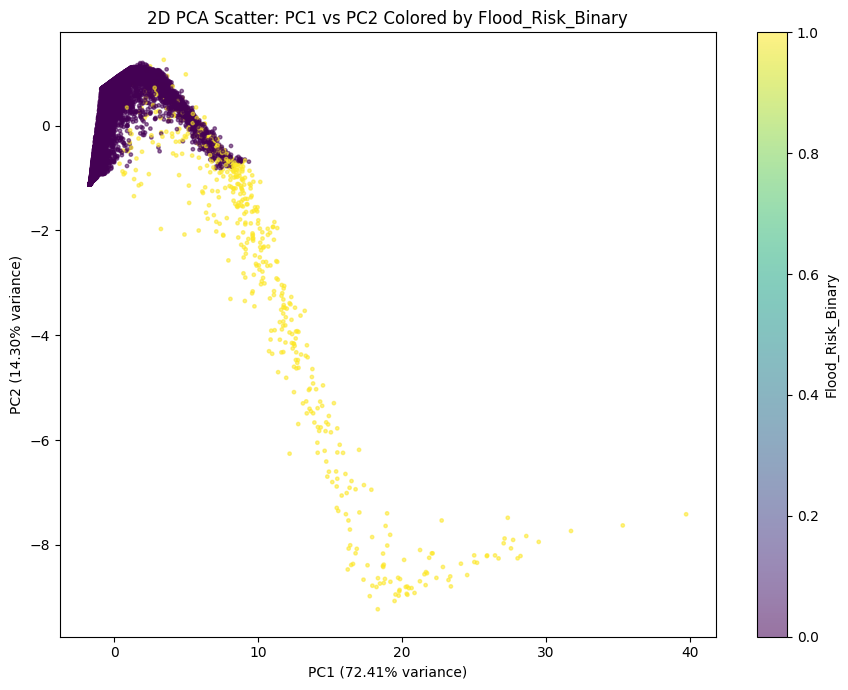

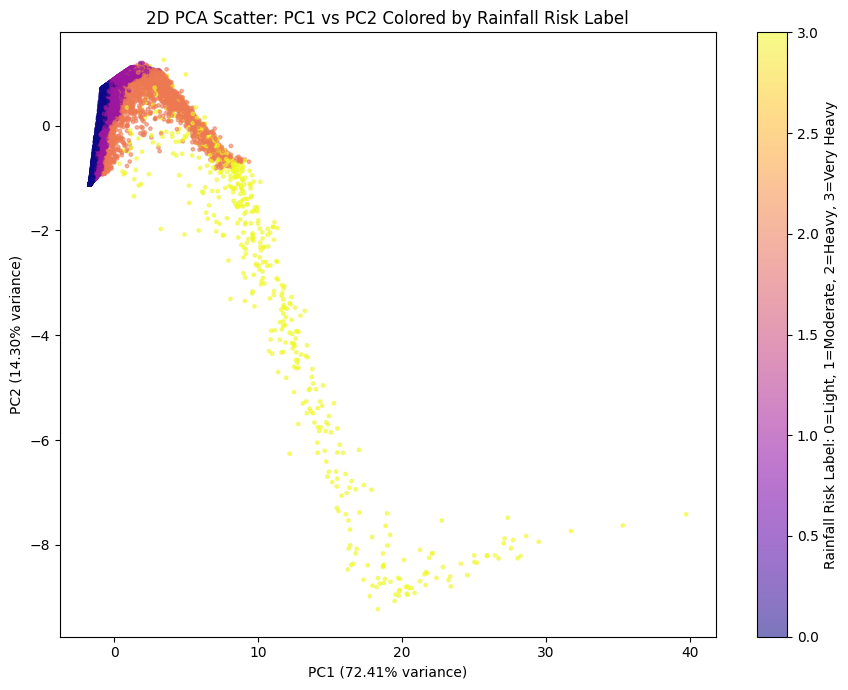

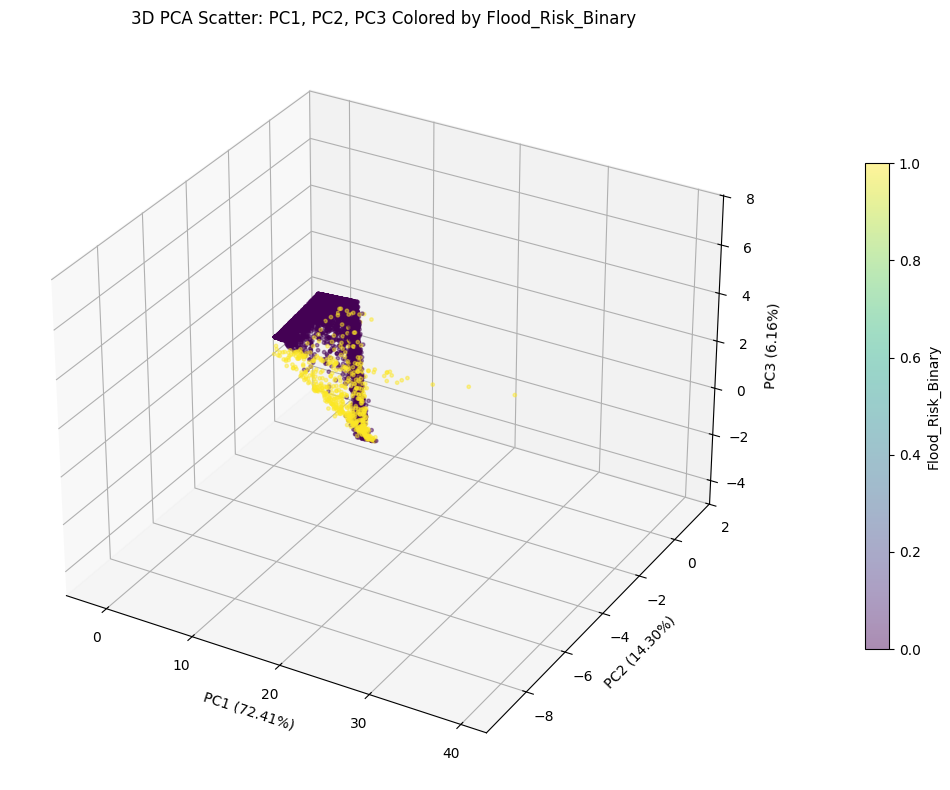

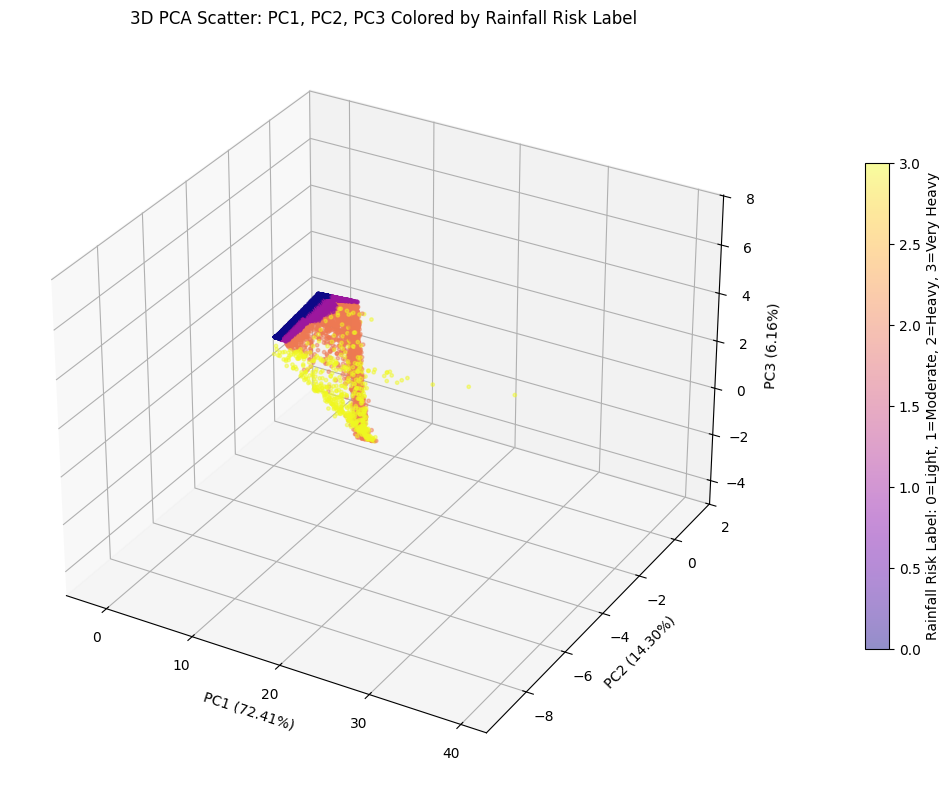

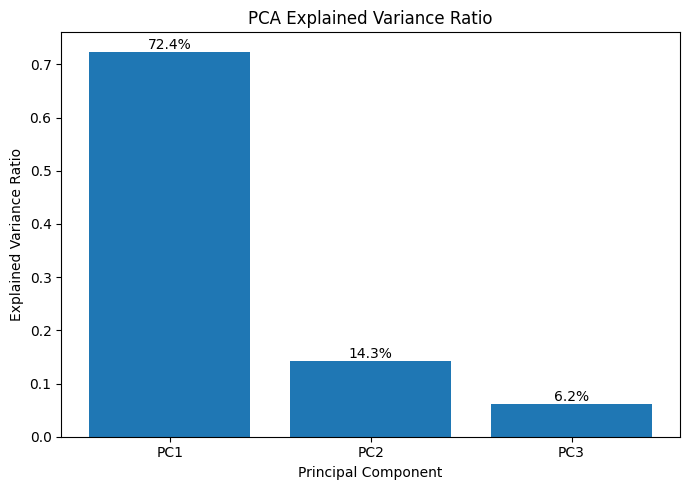

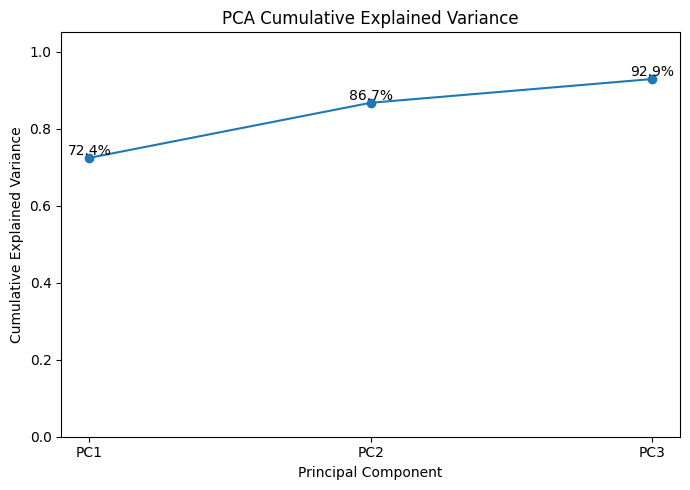

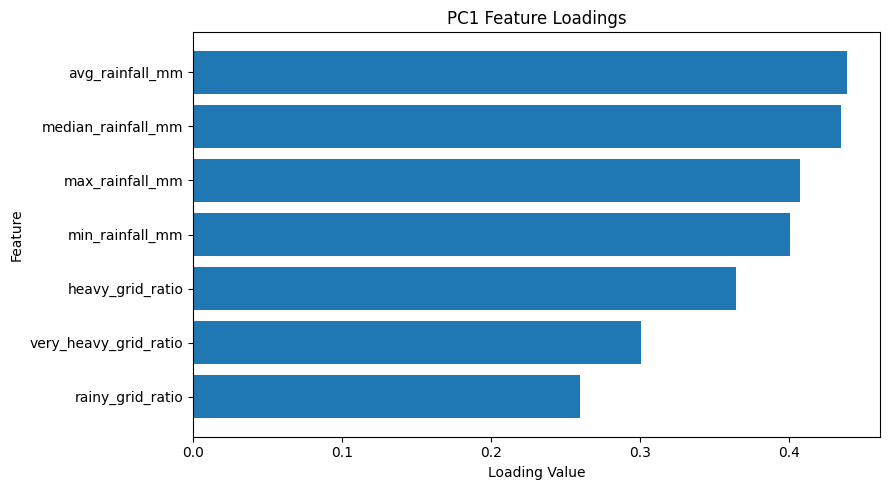

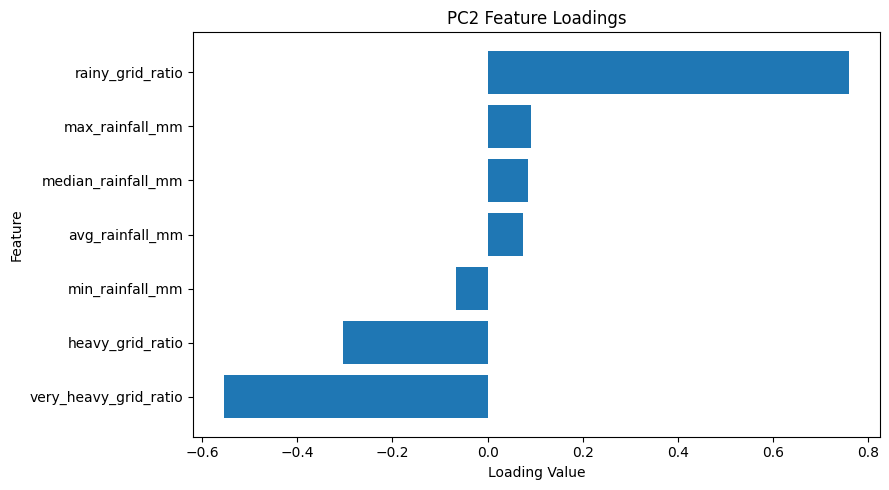

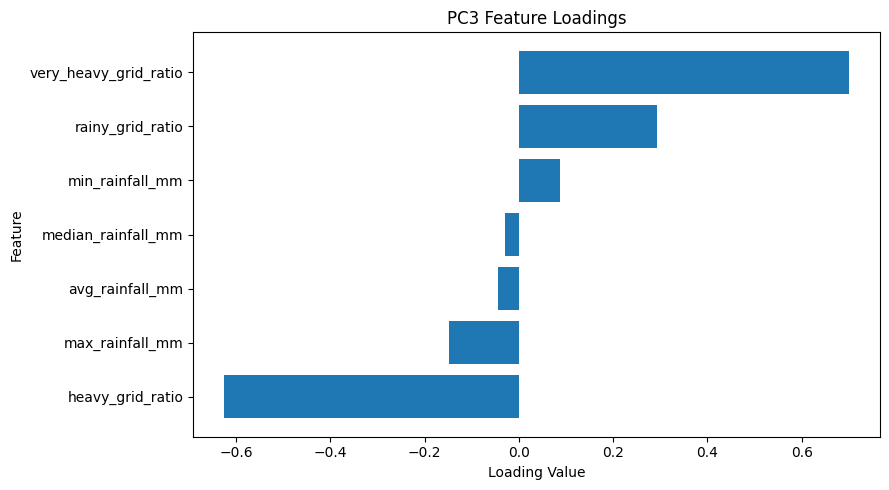


PCA outputs saved to:
/scr/user/kevin2002/TensorCat/Data Analysis/Group_Project/Data/Outputs/PCA_Analysis

================ Suggested Interpretation ================
1. PC1 captures the largest rainfall variation pattern among the selected rainfall features.
2. PC2 captures the second strongest independent rainfall variation pattern.
3. PC3 adds an extra dimension for 3D visualization and helps reveal structure that may be hidden in 2D.
4. The loading table explains which original rainfall variables contribute most to each principal component.
5. If high Flood_Risk_Binary or high rainfall_risk_label points gather in a PCA region, rainfall-risk records have distinguishable multivariate patterns.


In [21]:
# =========================================================
# PCA Dimensionality Reduction with Full 2D + 3D Visualization
# =========================================================
# Purpose:
# PCA is used as a bonus dimensionality-reduction analysis.
# It compresses several rainfall-related variables into PC1, PC2, and PC3,
# then visualizes whether rainfall-risk records form distinguishable patterns.
#
# Important:
# - The PCA input features below are directly derived from CHIRPS rainfall grid values.
# - PCA is unsupervised; Flood_Risk_Binary and rainfall_risk_label are used only for coloring the plots.
# - StandardScaler is required because PCA is sensitive to variable scale.
# =========================================================

from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

PCA_OUTPUT_DIR = OUTPUT_DIR / "PCA_Analysis"
PCA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pca_features = [
    "avg_rainfall_mm",
    "max_rainfall_mm",
    "min_rainfall_mm",
    "median_rainfall_mm",
    "rainy_grid_ratio",
    "heavy_grid_ratio",
    "very_heavy_grid_ratio",
]

missing_features = [col for col in pca_features if col not in df_full_years.columns]
if missing_features:
    raise ValueError(f"Missing PCA features: {missing_features}")

# Drop rows with missing values in PCA features, just in case.
df_pca_source = df_full_years.dropna(subset=pca_features).copy()

print("PCA feature columns:")
print(pca_features)
print("\nSource data shape for PCA:")
print(df_pca_source.shape)

# Use a sample for plotting speed and cleaner visualization.
# 30,000 points is enough for visual pattern checking without overwhelming the notebook.
plot_df = df_pca_source.sample(
    n=min(30000, len(df_pca_source)),
    random_state=42,
).copy()

print("\nSampled data shape for PCA plotting:")
print(plot_df.shape)

# Standardize features before PCA.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(plot_df[pca_features])

# Fit PCA with 3 components.
# PC1 + PC2 are used for 2D visualization.
# PC1 + PC2 + PC3 are used for 3D visualization.
pca = PCA(n_components=3, random_state=42)
pcs = pca.fit_transform(X_scaled)

plot_df["PC1"] = pcs[:, 0]
plot_df["PC2"] = pcs[:, 1]
plot_df["PC3"] = pcs[:, 2]

# =========================================================
# Explained variance table
# =========================================================
explained = pd.DataFrame({
    "component": ["PC1", "PC2", "PC3"],
    "explained_variance_ratio": pca.explained_variance_ratio_,
})
explained["cumulative_explained_variance"] = explained["explained_variance_ratio"].cumsum()

explained.to_csv(
    PCA_OUTPUT_DIR / "pca_explained_variance_3_components.csv",
    index=False,
)

# =========================================================
# PCA loadings
# Loadings explain which original rainfall features contribute most to each PC.
# =========================================================
loadings = pd.DataFrame(
    pca.components_.T,
    index=pca_features,
    columns=["PC1_loading", "PC2_loading", "PC3_loading"],
)
loadings["PC1_abs_loading"] = loadings["PC1_loading"].abs()
loadings["PC2_abs_loading"] = loadings["PC2_loading"].abs()
loadings["PC3_abs_loading"] = loadings["PC3_loading"].abs()

loadings.to_csv(PCA_OUTPUT_DIR / "pca_loadings_3_components.csv")

# =========================================================
# Save PCA scatter sample points
# =========================================================
scatter_cols = [
    "date", "year", "month", "state", "city",
    "avg_rainfall_mm", "max_rainfall_mm", "min_rainfall_mm", "median_rainfall_mm",
    "rainy_grid_ratio", "heavy_grid_ratio", "very_heavy_grid_ratio",
    "rainfall_risk_level", "rainfall_risk_label", "Flood_Risk_Binary",
    "PC1", "PC2", "PC3",
]
available_scatter_cols = [col for col in scatter_cols if col in plot_df.columns]
plot_df[available_scatter_cols].to_csv(
    PCA_OUTPUT_DIR / "pca_scatter_points_sample_3d.csv",
    index=False,
)

print("\n================ Explained Variance ================")
display(explained)

print("\n================ PCA Loadings ================")
display(loadings)

# =========================================================
# 2D PCA scatter: colored by Flood_Risk_Binary
# =========================================================
plt.figure(figsize=(9, 7))
scatter = plt.scatter(
    plot_df["PC1"],
    plot_df["PC2"],
    c=plot_df["Flood_Risk_Binary"],
    s=6,
    alpha=0.55,
    cmap="viridis",
)
plt.title("2D PCA Scatter: PC1 vs PC2 Colored by Flood_Risk_Binary")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.2f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.2f}% variance)")
cbar = plt.colorbar(scatter)
cbar.set_label("Flood_Risk_Binary")
plt.tight_layout()
plt.savefig(PCA_OUTPUT_DIR / "pca_2d_scatter_PC1_PC2_Flood_Risk_Binary.png", dpi=200)
plt.show()

# =========================================================
# 2D PCA scatter: colored by 4-level rainfall risk label
# =========================================================
plt.figure(figsize=(9, 7))
scatter = plt.scatter(
    plot_df["PC1"],
    plot_df["PC2"],
    c=plot_df["rainfall_risk_label"],
    s=6,
    alpha=0.55,
    cmap="plasma",
)
plt.title("2D PCA Scatter: PC1 vs PC2 Colored by Rainfall Risk Label")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.2f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.2f}% variance)")
cbar = plt.colorbar(scatter)
cbar.set_label("Rainfall Risk Label: 0=Light, 1=Moderate, 2=Heavy, 3=Very Heavy")
plt.tight_layout()
plt.savefig(PCA_OUTPUT_DIR / "pca_2d_scatter_PC1_PC2_rainfall_risk_label.png", dpi=200)
plt.show()

# =========================================================
# 3D PCA scatter: colored by Flood_Risk_Binary
# =========================================================
fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection="3d")
scatter = ax.scatter(
    plot_df["PC1"],
    plot_df["PC2"],
    plot_df["PC3"],
    c=plot_df["Flood_Risk_Binary"],
    s=6,
    alpha=0.45,
    cmap="viridis",
)
ax.set_title("3D PCA Scatter: PC1, PC2, PC3 Colored by Flood_Risk_Binary")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.2f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.2f}%)")
ax.set_zlabel(f"PC3 ({pca.explained_variance_ratio_[2] * 100:.2f}%)")
cbar = fig.colorbar(scatter, ax=ax, shrink=0.65, pad=0.1)
cbar.set_label("Flood_Risk_Binary")
plt.tight_layout()
plt.savefig(PCA_OUTPUT_DIR / "pca_3d_scatter_PC1_PC2_PC3_Flood_Risk_Binary.png", dpi=200)
plt.show()

# =========================================================
# 3D PCA scatter: colored by 4-level rainfall risk label
# =========================================================
fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection="3d")
scatter = ax.scatter(
    plot_df["PC1"],
    plot_df["PC2"],
    plot_df["PC3"],
    c=plot_df["rainfall_risk_label"],
    s=6,
    alpha=0.45,
    cmap="plasma",
)
ax.set_title("3D PCA Scatter: PC1, PC2, PC3 Colored by Rainfall Risk Label")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.2f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.2f}%)")
ax.set_zlabel(f"PC3 ({pca.explained_variance_ratio_[2] * 100:.2f}%)")
cbar = fig.colorbar(scatter, ax=ax, shrink=0.65, pad=0.1)
cbar.set_label("Rainfall Risk Label: 0=Light, 1=Moderate, 2=Heavy, 3=Very Heavy")
plt.tight_layout()
plt.savefig(PCA_OUTPUT_DIR / "pca_3d_scatter_PC1_PC2_PC3_rainfall_risk_label.png", dpi=200)
plt.show()

# =========================================================
# Explained variance bar chart
# =========================================================
plt.figure(figsize=(7, 5))
plt.bar(explained["component"], explained["explained_variance_ratio"])
plt.title("PCA Explained Variance Ratio")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
for i, value in enumerate(explained["explained_variance_ratio"]):
    plt.text(i, value, f"{value * 100:.1f}%", ha="center", va="bottom")
plt.tight_layout()
plt.savefig(PCA_OUTPUT_DIR / "pca_explained_variance_3_components.png", dpi=200)
plt.show()

# =========================================================
# Cumulative explained variance line chart
# =========================================================
plt.figure(figsize=(7, 5))
plt.plot(
    explained["component"],
    explained["cumulative_explained_variance"],
    marker="o",
)
plt.title("PCA Cumulative Explained Variance")
plt.xlabel("Principal Component")
plt.ylabel("Cumulative Explained Variance")
plt.ylim(0, 1.05)
for i, value in enumerate(explained["cumulative_explained_variance"]):
    plt.text(i, value, f"{value * 100:.1f}%", ha="center", va="bottom")
plt.tight_layout()
plt.savefig(PCA_OUTPUT_DIR / "pca_cumulative_explained_variance.png", dpi=200)
plt.show()

# =========================================================
# PCA loading bar charts
# =========================================================
for pc in ["PC1", "PC2", "PC3"]:
    loading_col = f"{pc}_loading"
    sorted_loadings = loadings[loading_col].sort_values()

    plt.figure(figsize=(9, 5))
    plt.barh(sorted_loadings.index, sorted_loadings.values)
    plt.title(f"{pc} Feature Loadings")
    plt.xlabel("Loading Value")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.savefig(PCA_OUTPUT_DIR / f"pca_{pc}_feature_loadings.png", dpi=200)
    plt.show()

print("\nPCA outputs saved to:")
print(PCA_OUTPUT_DIR)

print("\n================ Suggested Interpretation ================")
print(
    "1. PC1 captures the largest rainfall variation pattern among the selected rainfall features.\n"
    "2. PC2 captures the second strongest independent rainfall variation pattern.\n"
    "3. PC3 adds an extra dimension for 3D visualization and helps reveal structure that may be hidden in 2D.\n"
    "4. The loading table explains which original rainfall variables contribute most to each principal component.\n"
    "5. If high Flood_Risk_Binary or high rainfall_risk_label points gather in a PCA region, rainfall-risk records have distinguishable multivariate patterns."
)


# 9. Clustering Analysis

Here we cluster cities based on long-term rainfall behavior.

Clustering backend: torch_cuda


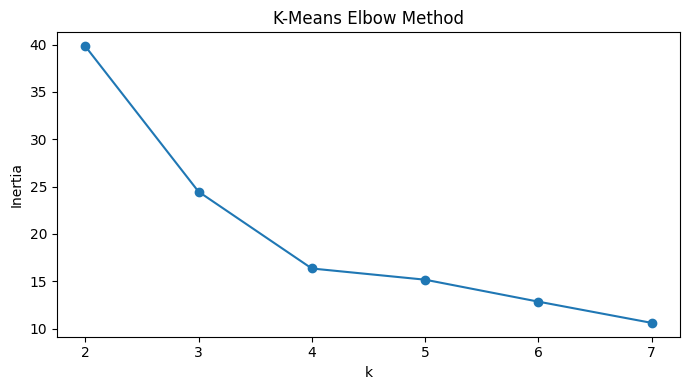

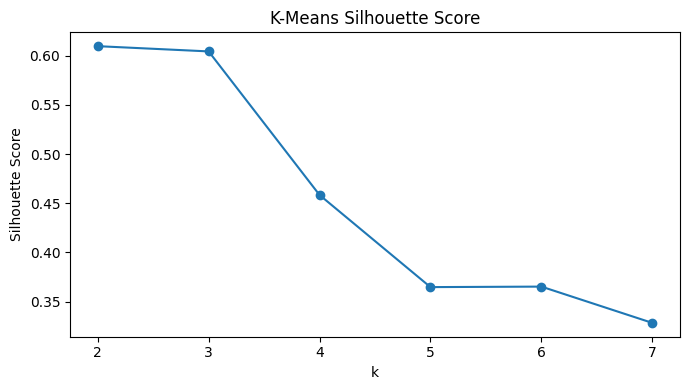

Clustering evaluation outputs saved to: /scr/user/kevin2002/TensorCat/Data Analysis/Group_Project/Data/Outputs/Clustering_Analysis


In [22]:
# =========================================================
# City-level clustering with GPU/MPS-aware K-Means when PyTorch is available
# =========================================================

city_cluster = df_full_years.groupby(["state", "city"]).agg(
    mean_avg_rainfall=("avg_rainfall_mm", "mean"),
    mean_max_rainfall=("max_rainfall_mm", "mean"),
    flood_risk_rate=("Flood_Risk_Binary", "mean"),
    mean_heavy_grid_ratio=("heavy_grid_ratio", "mean"),
    mean_very_heavy_grid_ratio=("very_heavy_grid_ratio", "mean"),
).reset_index()

cluster_features = [
    "mean_avg_rainfall", "mean_max_rainfall", "flood_risk_rate",
    "mean_heavy_grid_ratio", "mean_very_heavy_grid_ratio"
]
Xc = StandardScaler().fit_transform(city_cluster[cluster_features]).astype(np.float32)


def torch_kmeans(X_np, n_clusters=4, n_iter=100, seed=42):
    """Small GPU/MPS-aware K-Means for numeric arrays. Falls back to CPU if DEVICE is CPU."""
    if torch is None:
        raise RuntimeError("PyTorch is not available.")

    g = torch.Generator(device="cpu")
    g.manual_seed(seed)

    X = torch.tensor(X_np, dtype=torch.float32, device=DEVICE)
    init_idx = torch.randperm(X.shape[0], generator=g)[:n_clusters].to(DEVICE)
    centers = X[init_idx].clone()

    for _ in range(n_iter):
        distances = torch.cdist(X, centers)
        labels = distances.argmin(dim=1)
        new_centers = []
        for k in range(n_clusters):
            mask = labels == k
            if mask.any():
                new_centers.append(X[mask].mean(dim=0))
            else:
                new_centers.append(centers[k])
        new_centers = torch.stack(new_centers)
        if torch.allclose(centers, new_centers, atol=1e-5):
            centers = new_centers
            break
        centers = new_centers

    inertia = torch.sum((X - centers[labels]) ** 2).item()
    return labels.detach().cpu().numpy(), centers.detach().cpu().numpy(), inertia

# Elbow and silhouette check
ks = range(2, 8)
inertias = []
silhouettes = []
used_cluster_backend = f"torch_{DEVICE}" if torch is not None else "sklearn_cpu"

for k in ks:
    try:
        labels, centers, inertia = torch_kmeans(Xc, n_clusters=k, n_iter=100, seed=42)
    except Exception as e:
        used_cluster_backend = "sklearn_cpu"
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(Xc)
        inertia = km.inertia_

    inertias.append(inertia)
    silhouettes.append(silhouette_score(Xc, labels))

print("Clustering backend:", used_cluster_backend)

CLUSTERING_OUTPUT_DIR = OUTPUT_DIR / "Clustering_Analysis"
CLUSTERING_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

cluster_eval_df = pd.DataFrame({
    "k": list(ks),
    "inertia": inertias,
    "silhouette_score": silhouettes,
})
cluster_eval_df.to_csv(CLUSTERING_OUTPUT_DIR / "kmeans_elbow_silhouette_scores.csv", index=False)

plt.figure(figsize=(7, 4))
plt.plot(list(ks), inertias, marker="o")
plt.title("K-Means Elbow Method")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.tight_layout()
plt.savefig(CLUSTERING_OUTPUT_DIR / "kmeans_elbow_method.png", dpi=200, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(list(ks), silhouettes, marker="o")
plt.title("K-Means Silhouette Score")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.tight_layout()
plt.savefig(CLUSTERING_OUTPUT_DIR / "kmeans_silhouette_score.png", dpi=200, bbox_inches="tight")
plt.show()

print("Clustering evaluation outputs saved to:", CLUSTERING_OUTPUT_DIR)


Final clustering backend: torch_cuda
City cluster PCA backend: torch_cuda


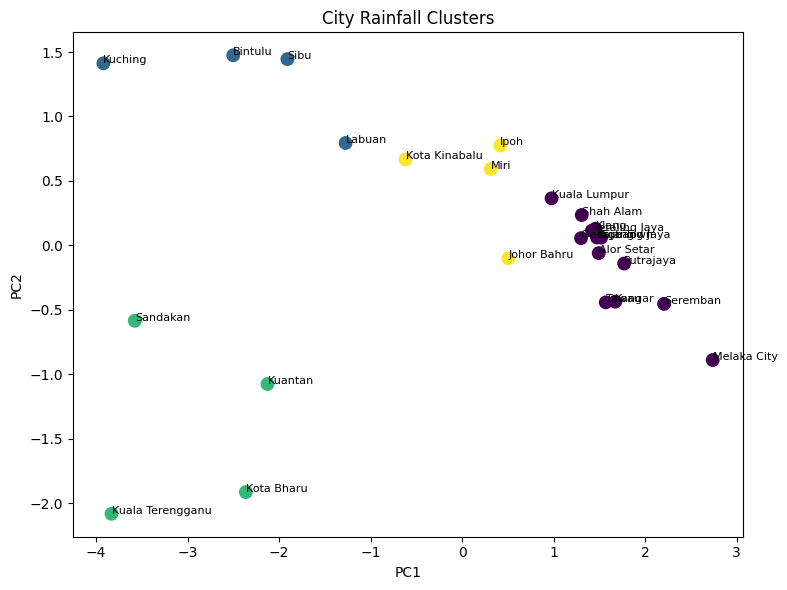

Final clustering outputs saved to: /scr/user/kevin2002/TensorCat/Data Analysis/Group_Project/Data/Outputs/Clustering_Analysis


,state,city,mean_avg_rainfall,mean_max_rainfall,flood_risk_rate,mean_heavy_grid_ratio,mean_very_heavy_grid_ratio,cluster,PC1,PC2
11,Sabah,Tawau,5.872812,14.315736,0.009898,0.022298,0.001248,0,1.568824,-0.442150
22,WP Kuala Lumpur,Kuala Lumpur,7.717050,15.120020,0.007055,0.022153,0.000893,0,0.976546,0.364988
6,Penang,George Town,7.432803,13.806306,0.006318,0.019670,0.001156,0,1.298554,0.055788
8,Perlis,Kangar,6.896535,11.957075,0.005581,0.021883,0.001579,0,1.672266,-0.436812
19,Selangor,Shah Alam,7.499694,14.352713,0.004422,0.017939,0.000630,0,1.306126,0.235326
16,Selangor,Kajang,7.135865,14.015141,0.004317,0.017573,0.000667,0,1.472589,0.060782
1,Kedah,Alor Setar,7.235474,13.164896,0.004107,0.020638,0.000933,0,1.491244,-0.060194
18,Selangor,Petaling Jaya,7.580668,13.348025,0.003791,0.018794,0.000610,0,1.418618,0.114473
17,Selangor,Klang,7.369254,13.853566,0.003685,0.016792,0.000583,0,1.457072,0.129098
20,Selangor,Subang Jaya,7.460713,13.195900,0.003580,0.017112,0.000542,0,1.517677,0.060537


In [23]:
BEST_K = 4
try:
    labels, centers, inertia = torch_kmeans(Xc, n_clusters=BEST_K, n_iter=100, seed=42)
    city_cluster["cluster"] = labels
    print("Final clustering backend:", f"torch_{DEVICE}")
except Exception as e:
    print("Torch K-Means failed, using sklearn CPU KMeans.")
    print(e)
    km = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
    city_cluster["cluster"] = km.fit_predict(Xc)

# 2D visualization of city clusters. Try torch PCA/SVD first.
try:
    if torch is None:
        raise RuntimeError("PyTorch is not available.")
    X_city = torch.tensor(Xc, dtype=torch.float32, device=DEVICE)
    X_city = X_city - X_city.mean(dim=0, keepdim=True)
    U, S, Vh = torch.linalg.svd(X_city, full_matrices=False)
    city_pcs = (X_city @ Vh[:2].T).detach().cpu().numpy()
    print("City cluster PCA backend:", f"torch_{DEVICE}")
except Exception as e:
    pca_city = PCA(n_components=2, random_state=42)
    city_pcs = pca_city.fit_transform(Xc)
    print("City cluster PCA backend: sklearn_cpu")

city_cluster["PC1"] = city_pcs[:, 0]
city_cluster["PC2"] = city_pcs[:, 1]

CLUSTERING_OUTPUT_DIR = OUTPUT_DIR / "Clustering_Analysis"
CLUSTERING_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

city_cluster_sorted = city_cluster.sort_values(["cluster", "flood_risk_rate"], ascending=[True, False])
city_cluster_sorted.to_csv(CLUSTERING_OUTPUT_DIR / "city_rainfall_clusters.csv", index=False)

plt.figure(figsize=(8, 6))
plt.scatter(city_cluster["PC1"], city_cluster["PC2"], c=city_cluster["cluster"], s=80)
for _, row in city_cluster.iterrows():
    plt.text(row["PC1"], row["PC2"], row["city"], fontsize=8)
plt.title("City Rainfall Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.savefig(CLUSTERING_OUTPUT_DIR / "city_rainfall_clusters_2d.png", dpi=200, bbox_inches="tight")
plt.show()

print("Final clustering outputs saved to:", CLUSTERING_OUTPUT_DIR)
city_cluster_sorted


# 10. Regression Analysis: XGBoost Regressor for Continuous Rainfall Prediction

This section predicts continuous rainfall values using **XGBoost Regression**, not a neural-network MLP.  
This keeps the project structure cleaner:

- **Regression Analysis** → traditional machine learning with XGBoost  
- **Neural Network Time-Series Prediction** → pretrained PatchTST Transformer

The regression targets are:

- `avg_rainfall_mm`
- `max_rainfall_mm`
- `min_rainfall_mm`

To avoid data leakage, we do **not** use `rainfall_risk_level`, `rainfall_risk_label`, or `Flood_Risk_Binary` as input features.

XGBoost GPU acceleration is used when **CUDA** is available. Apple **MPS is not supported by XGBoost**, so on Mac it will fall back to CPU for this traditional ML section. The PatchTST section later can still use MPS/CUDA through PyTorch.

In [24]:
# =========================================================
# XGBoost Regression:
# Target-specific tuning + seasonal features + train-only climatology
#
# This cell only handles:
# 1. Feature engineering
# 2. XGBoost training
# 3. Validation-based parameter selection
# 4. Test evaluation
# 5. Saving prediction/result CSV files
#
# No plotting is included in this cell.
# =========================================================

import numpy as np
import pandas as pd

try:
    from xgboost import XGBRegressor
except ImportError as e:
    raise ImportError(
        "XGBoost is required for this regression section. Install it with:\n"
        "pip install xgboost"
    ) from e

from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, r2_score

try:
    from sklearn.metrics import root_mean_squared_error

    def rmse_score(y_true, y_pred):
        return root_mean_squared_error(y_true, y_pred)

except ImportError:
    from sklearn.metrics import mean_squared_error

    def rmse_score(y_true, y_pred):
        return mean_squared_error(y_true, y_pred, squared=False)


# =========================================================
# 1) XGBoost device selection
# =========================================================
USE_CUDA_XGB = bool(torch is not None and torch.cuda.is_available())

if USE_CUDA_XGB:
    XGB_DEVICE = "cuda"
    print("Using XGBoost with CUDA GPU acceleration.")
    print("CUDA device:", torch.cuda.get_device_name(0))
else:
    XGB_DEVICE = "cpu"
    print("CUDA is not available for XGBoost. Using CPU fallback.")

    if torch is not None and hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        print("Note: MPS is available for PyTorch, but XGBoost does not use Apple MPS.")


# =========================================================
# 2) Prepare dataframe
# =========================================================
model_df = df_full_years.copy()
model_df["date"] = pd.to_datetime(model_df["date"])
model_df = model_df.sort_values(["date", "state", "city"]).reset_index(drop=True)

targets_reg = [
    "avg_rainfall_mm",
    "max_rainfall_mm",
    "min_rainfall_mm",
]


# =========================================================
# 3) Calendar / seasonal features
# =========================================================
model_df["dayofyear"] = model_df["date"].dt.dayofyear.astype(int)
model_df["weekofyear"] = model_df["date"].dt.isocalendar().week.astype(int)

model_df["month_sin"] = np.sin(2 * np.pi * model_df["month"] / 12)
model_df["month_cos"] = np.cos(2 * np.pi * model_df["month"] / 12)

model_df["dayofyear_sin"] = np.sin(2 * np.pi * model_df["dayofyear"] / 366)
model_df["dayofyear_cos"] = np.cos(2 * np.pi * model_df["dayofyear"] / 366)


def malaysia_season(month):
    if month in [11, 12, 1, 2, 3]:
        return "Northeast_Monsoon"
    if month in [5, 6, 7, 8, 9]:
        return "Southwest_Monsoon"
    return "Inter_Monsoon"


model_df["season"] = model_df["month"].apply(malaysia_season)

# Simple interaction features derived from existing predictors.
model_df["heavy_ratio_x_very_heavy_ratio"] = (
    model_df["heavy_grid_ratio"] * model_df["very_heavy_grid_ratio"]
)
model_df["rainy_ratio_sq"] = model_df["rainy_grid_ratio"] ** 2
model_df["heavy_ratio_sq"] = model_df["heavy_grid_ratio"] ** 2
model_df["very_heavy_ratio_sq"] = model_df["very_heavy_grid_ratio"] ** 2
model_df["lat_lon_interaction"] = model_df["city_latitude"] * model_df["city_longitude"]


# =========================================================
# 4) Time-based split
# =========================================================
base_train_df = model_df[model_df["year"] <= 2020].copy()
base_valid_df = model_df[(model_df["year"] >= 2021) & (model_df["year"] <= 2022)].copy()
base_test_df = model_df[(model_df["year"] >= 2023) & (model_df["year"] <= 2025)].copy()

print("\n================ Regression Split ================")
print("Base Train     :", base_train_df.shape)
print("Base Validation:", base_valid_df.shape)
print("Base Test      :", base_test_df.shape)


# =========================================================
# 5) Train-only climatology features
#    Computed only from 2000-2020 training data.
#    This avoids future-label leakage.
# =========================================================
def add_train_only_climatology(train_df, valid_df, test_df, target):
    train_df = train_df.copy()
    valid_df = valid_df.copy()
    test_df = test_df.copy()

    city_month_stats = (
        train_df.groupby(["city", "month"])[target]
        .agg(["mean", "std", "median"])
        .reset_index()
        .rename(columns={
            "mean": f"{target}_city_month_mean",
            "std": f"{target}_city_month_std",
            "median": f"{target}_city_month_median",
        })
    )

    state_month_stats = (
        train_df.groupby(["state", "month"])[target]
        .agg(["mean", "std", "median"])
        .reset_index()
        .rename(columns={
            "mean": f"{target}_state_month_mean",
            "std": f"{target}_state_month_std",
            "median": f"{target}_state_month_median",
        })
    )

    city_season_stats = (
        train_df.groupby(["city", "season"])[target]
        .agg(["mean", "std"])
        .reset_index()
        .rename(columns={
            "mean": f"{target}_city_season_mean",
            "std": f"{target}_city_season_std",
        })
    )

    global_mean = train_df[target].mean()
    global_std = train_df[target].std()
    global_median = train_df[target].median()

    def merge_stats(df_part):
        out = df_part.copy()

        out = out.merge(city_month_stats, on=["city", "month"], how="left")
        out = out.merge(state_month_stats, on=["state", "month"], how="left")
        out = out.merge(city_season_stats, on=["city", "season"], how="left")

        mean_cols = [
            f"{target}_city_month_mean",
            f"{target}_state_month_mean",
            f"{target}_city_season_mean",
        ]

        std_cols = [
            f"{target}_city_month_std",
            f"{target}_state_month_std",
            f"{target}_city_season_std",
        ]

        median_cols = [
            f"{target}_city_month_median",
            f"{target}_state_month_median",
        ]

        for col in mean_cols:
            out[col] = out[col].fillna(global_mean)

        for col in std_cols:
            out[col] = out[col].fillna(global_std)

        for col in median_cols:
            out[col] = out[col].fillna(global_median)

        return out

    return merge_stats(train_df), merge_stats(valid_df), merge_stats(test_df)


# =========================================================
# 6) Base feature columns
# =========================================================
base_features_num = [
    "year",
    "month",
    "day",
    "dayofyear",
    "weekofyear",
    "month_sin",
    "month_cos",
    "dayofyear_sin",
    "dayofyear_cos",
    "city_latitude",
    "city_longitude",
    "radius_km",
    "grid_count",
    "rainy_grid_ratio",
    "heavy_grid_ratio",
    "very_heavy_grid_ratio",
    "heavy_ratio_x_very_heavy_ratio",
    "rainy_ratio_sq",
    "heavy_ratio_sq",
    "very_heavy_ratio_sq",
    "lat_lon_interaction",
]

features_cat = [
    "city",
    "state",
    "season",
]


# =========================================================
# 7) Candidate XGBoost parameter sets
# =========================================================
param_candidates = [
    {
        "name": "baseline_close",
        "params": dict(
            n_estimators=900,
            max_depth=6,
            learning_rate=0.03,
            subsample=0.85,
            colsample_bytree=0.85,
            min_child_weight=1,
            gamma=0,
            reg_alpha=0,
            reg_lambda=1.0,
        ),
    },
    {
        "name": "deeper_low_lr",
        "params": dict(
            n_estimators=1400,
            max_depth=7,
            learning_rate=0.02,
            subsample=0.90,
            colsample_bytree=0.90,
            min_child_weight=1,
            gamma=0,
            reg_alpha=0.01,
            reg_lambda=1.2,
        ),
    },
    {
        "name": "regularized",
        "params": dict(
            n_estimators=1600,
            max_depth=6,
            learning_rate=0.018,
            subsample=0.88,
            colsample_bytree=0.88,
            min_child_weight=3,
            gamma=0.05,
            reg_alpha=0.05,
            reg_lambda=2.0,
        ),
    },
    {
        "name": "shallow_generalized",
        "params": dict(
            n_estimators=1800,
            max_depth=5,
            learning_rate=0.018,
            subsample=0.92,
            colsample_bytree=0.92,
            min_child_weight=4,
            gamma=0.03,
            reg_alpha=0.02,
            reg_lambda=1.8,
        ),
    },
    {
        "name": "high_capacity",
        "params": dict(
            n_estimators=1200,
            max_depth=8,
            learning_rate=0.02,
            subsample=0.86,
            colsample_bytree=0.86,
            min_child_weight=1,
            gamma=0,
            reg_alpha=0.01,
            reg_lambda=1.0,
        ),
    },
]


# =========================================================
# 8) Build target-specific data
# =========================================================
def build_target_data(target):
    train_df, valid_df, test_df = add_train_only_climatology(
        base_train_df,
        base_valid_df,
        base_test_df,
        target,
    )

    target_clim_features = [
        f"{target}_city_month_mean",
        f"{target}_city_month_std",
        f"{target}_city_month_median",
        f"{target}_state_month_mean",
        f"{target}_state_month_std",
        f"{target}_state_month_median",
        f"{target}_city_season_mean",
        f"{target}_city_season_std",
    ]

    features_num = base_features_num + target_clim_features

    try:
        encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

    encoder.fit(train_df[features_cat])

    def build_matrix(df_part):
        X_num = df_part[features_num].to_numpy(dtype=np.float32)
        X_cat = encoder.transform(df_part[features_cat]).astype(np.float32)
        return np.hstack([X_num, X_cat]).astype(np.float32)

    X_train = build_matrix(train_df)
    X_valid = build_matrix(valid_df)
    X_test = build_matrix(test_df)

    y_train = train_df[target].to_numpy(dtype=np.float32)
    y_valid = valid_df[target].to_numpy(dtype=np.float32)
    y_test = test_df[target].to_numpy(dtype=np.float32)

    feature_names = features_num + encoder.get_feature_names_out(features_cat).tolist()

    return {
        "train_df": train_df,
        "valid_df": valid_df,
        "test_df": test_df,
        "X_train": X_train,
        "X_valid": X_valid,
        "X_test": X_test,
        "y_train": y_train,
        "y_valid": y_valid,
        "y_test": y_test,
        "feature_names": feature_names,
    }


# =========================================================
# 9) Train and tune per target
# =========================================================
REGRESSION_OUTPUT_DIR = OUTPUT_DIR / "Regression_Analysis"
REGRESSION_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

xgb_regression_results = []
xgb_models = {}
xgb_best_feature_names = {}

reg_pred_df = base_test_df[["date", "year", "month", "day", "state", "city"]].copy()

for target in targets_reg:
    print("\n" + "=" * 80)
    print(f"Target-specific XGBoost tuning: {target}")
    print("=" * 80)

    data = build_target_data(target)

    X_train_xgb = data["X_train"]
    X_valid_xgb = data["X_valid"]
    X_test_xgb = data["X_test"]

    y_train_target = data["y_train"]
    y_valid_target = data["y_valid"]
    y_test_target = data["y_test"]

    feature_names = data["feature_names"]

    print("X_train:", X_train_xgb.shape)
    print("X_valid:", X_valid_xgb.shape)
    print("X_test :", X_test_xgb.shape)

    target_trials = []

    best_model = None
    best_trial_name = None
    best_valid_rmse = float("inf")
    best_used_device = XGB_DEVICE

    for candidate in param_candidates:
        trial_name = candidate["name"]
        params = candidate["params"]

        model = XGBRegressor(
            **params,
            objective="reg:squarederror",
            tree_method="hist",
            device=XGB_DEVICE,
            random_state=42,
            n_jobs=-1,
            eval_metric="rmse",
            early_stopping_rounds=80,
            max_bin=256,
        )

        try:
            model.fit(
                X_train_xgb,
                y_train_target,
                eval_set=[(X_valid_xgb, y_valid_target)],
                verbose=False,
            )
            used_device = XGB_DEVICE

        except Exception as e:
            if XGB_DEVICE == "cuda":
                print(f"CUDA failed for trial '{trial_name}'. Retrying with CPU fallback.")
                print("Original error:", e)

                model = XGBRegressor(
                    **params,
                    objective="reg:squarederror",
                    tree_method="hist",
                    device="cpu",
                    random_state=42,
                    n_jobs=-1,
                    eval_metric="rmse",
                    early_stopping_rounds=80,
                    max_bin=256,
                )

                model.fit(
                    X_train_xgb,
                    y_train_target,
                    eval_set=[(X_valid_xgb, y_valid_target)],
                    verbose=False,
                )
                used_device = "cpu_fallback"

            else:
                raise

        pred_valid = np.clip(model.predict(X_valid_xgb), a_min=0, a_max=None)

        valid_mae = mean_absolute_error(y_valid_target, pred_valid)
        valid_rmse = rmse_score(y_valid_target, pred_valid)
        valid_r2 = r2_score(y_valid_target, pred_valid)
        best_iteration = getattr(model, "best_iteration", None)

        trial_row = {
            "target": target,
            "trial": trial_name,
            "device": used_device,
            "valid_MAE": valid_mae,
            "valid_RMSE": valid_rmse,
            "valid_R2": valid_r2,
            "best_iteration": best_iteration,
        }

        target_trials.append(trial_row)

        print(
            f"{trial_name:<22} | "
            f"valid_RMSE={valid_rmse:.5f} | "
            f"valid_MAE={valid_mae:.5f} | "
            f"valid_R2={valid_r2:.5f} | "
            f"best_iter={best_iteration}"
        )

        if valid_rmse < best_valid_rmse:
            best_valid_rmse = valid_rmse
            best_model = model
            best_trial_name = trial_name
            best_used_device = used_device

    # Evaluate best model on test set
    pred_test = np.clip(best_model.predict(X_test_xgb), a_min=0, a_max=None)

    test_mae = mean_absolute_error(y_test_target, pred_test)
    test_rmse = rmse_score(y_test_target, pred_test)
    test_r2 = r2_score(y_test_target, pred_test)

    xgb_regression_results.append({
        "target": target,
        "model": "XGBRegressor_TargetTuned_Climatology",
        "best_trial": best_trial_name,
        "device": best_used_device,
        "MAE": test_mae,
        "RMSE": test_rmse,
        "R2": test_r2,
        "valid_RMSE": best_valid_rmse,
        "best_iteration": getattr(best_model, "best_iteration", None),
    })

    reg_pred_df[f"actual_{target}"] = y_test_target
    reg_pred_df[f"predicted_{target}"] = pred_test
    reg_pred_df[f"error_{target}"] = pred_test - y_test_target
    reg_pred_df[f"abs_error_{target}"] = np.abs(pred_test - y_test_target)

    xgb_models[target] = best_model
    xgb_best_feature_names[target] = feature_names

    trials_df = pd.DataFrame(target_trials)
    trials_df.to_csv(
        REGRESSION_OUTPUT_DIR / f"xgboost_tuning_trials_{target}.csv",
        index=False,
    )

    print(f"\nBest trial for {target}: {best_trial_name}")
    print(f"Best validation RMSE: {best_valid_rmse:.5f}")
    print(f"Test MAE : {test_mae:.5f}")
    print(f"Test RMSE: {test_rmse:.5f}")
    print(f"Test R2  : {test_r2:.5f}")


# =========================================================
# 10) Save final training outputs
# =========================================================
reg_results_df = pd.DataFrame(xgb_regression_results)

reg_results_df.to_csv(
    REGRESSION_OUTPUT_DIR / "xgboost_regression_model_results_tuned.csv",
    index=False,
)

reg_pred_df.to_csv(
    REGRESSION_OUTPUT_DIR / "xgboost_regression_test_predictions_tuned.csv",
    index=False,
)

print("\n================ Final XGBoost Regression Results ================")
display(reg_results_df)

print("\nSaved regression result table to:")
print(REGRESSION_OUTPUT_DIR / "xgboost_regression_model_results_tuned.csv")

print("\nSaved regression test predictions to:")
print(REGRESSION_OUTPUT_DIR / "xgboost_regression_test_predictions_tuned.csv")

print("\nRegression training completed. No plots were generated in this cell.")

Using XGBoost with CUDA GPU acceleration.
CUDA device: NVIDIA A100-SXM4-80GB

================ Regression Split ================
Base Train     : (191775, 37)
Base Validation: (18250, 37)
Base Test      : (27400, 37)

Target-specific XGBoost tuning: avg_rainfall_mm
X_train: (191775, 73)
X_valid: (18250, 73)
X_test : (27400, 73)
baseline_close         | valid_RMSE=2.95557 | valid_MAE=1.82880 | valid_R2=0.92411 | best_iter=166
deeper_low_lr          | valid_RMSE=2.96862 | valid_MAE=1.83266 | valid_R2=0.92344 | best_iter=238
regularized            | valid_RMSE=2.94956 | valid_MAE=1.82043 | valid_R2=0.92442 | best_iter=329
shallow_generalized    | valid_RMSE=2.93220 | valid_MAE=1.82034 | valid_R2=0.92531 | best_iter=383
high_capacity          | valid_RMSE=2.99316 | valid_MAE=1.83378 | valid_R2=0.92217 | best_iter=239

Best trial for avg_rainfall_mm: shallow_generalized
Best validation RMSE: 2.93220
Test MAE : 1.92259
Test RMSE: 3.40076
Test R2  : 0.90773

Target-specific XGBoost tuning: ma

,target,model,best_trial,device,MAE,RMSE,R2,valid_RMSE,best_iteration
0,avg_rainfall_mm,XGBRegressor_TargetTuned_Climatology,shallow_generalized,cuda,1.922589,3.400755,0.907729,2.932201,383
1,max_rainfall_mm,XGBRegressor_TargetTuned_Climatology,shallow_generalized,cuda,4.174548,6.151925,0.871564,5.771618,349
2,min_rainfall_mm,XGBRegressor_TargetTuned_Climatology,regularized,cuda,1.045854,2.511392,0.878946,2.076220,499



Saved regression result table to:
/scr/user/kevin2002/TensorCat/Data Analysis/Group_Project/Data/Outputs/Regression_Analysis/xgboost_regression_model_results_tuned.csv

Saved regression test predictions to:
/scr/user/kevin2002/TensorCat/Data Analysis/Group_Project/Data/Outputs/Regression_Analysis/xgboost_regression_test_predictions_tuned.csv

Regression training completed. No plots were generated in this cell.


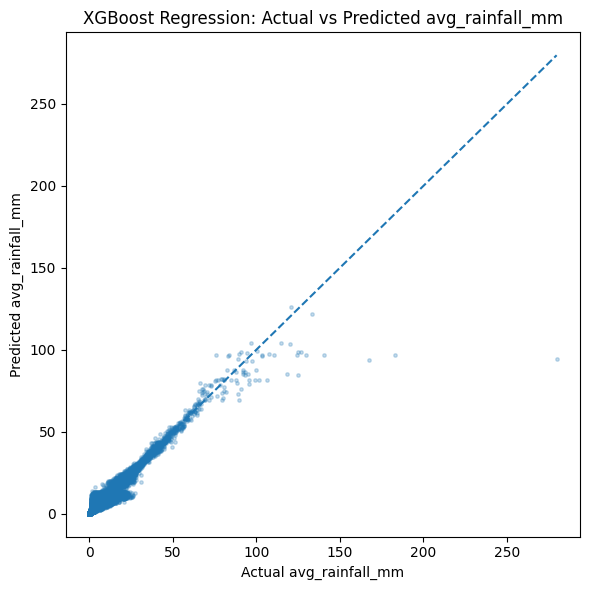

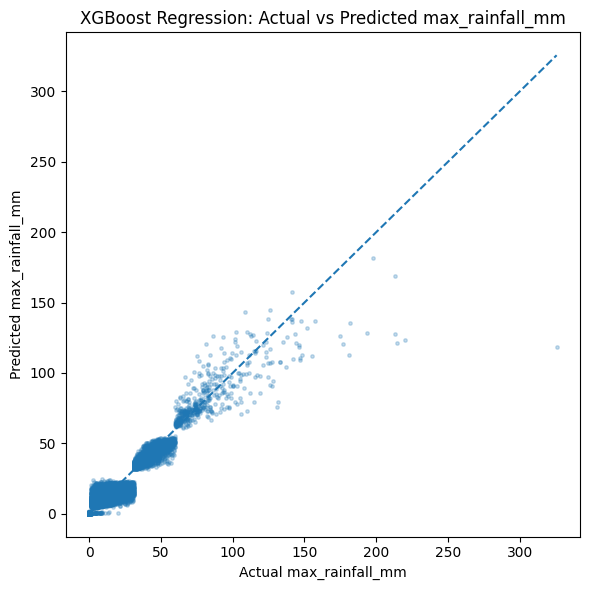

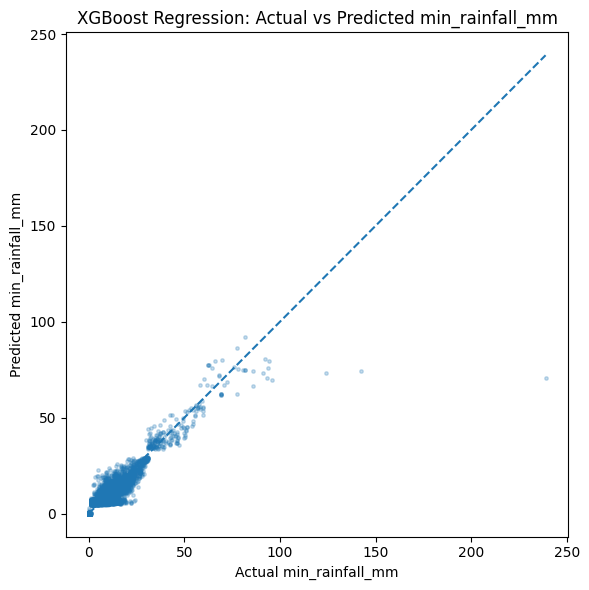

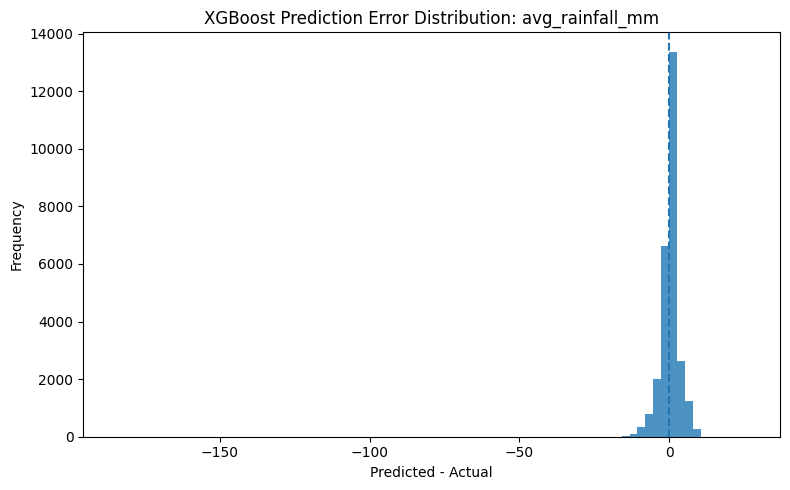

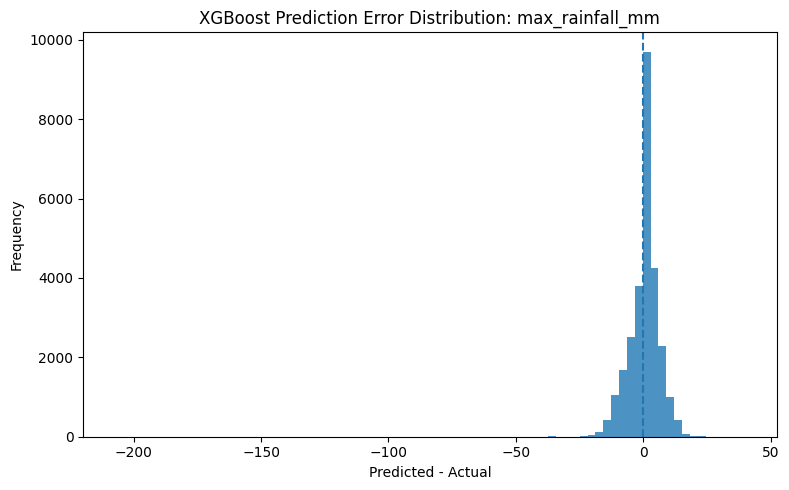

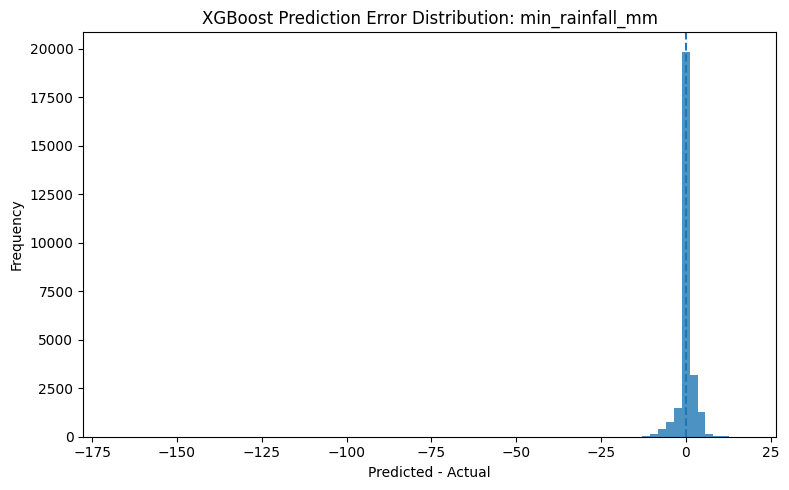

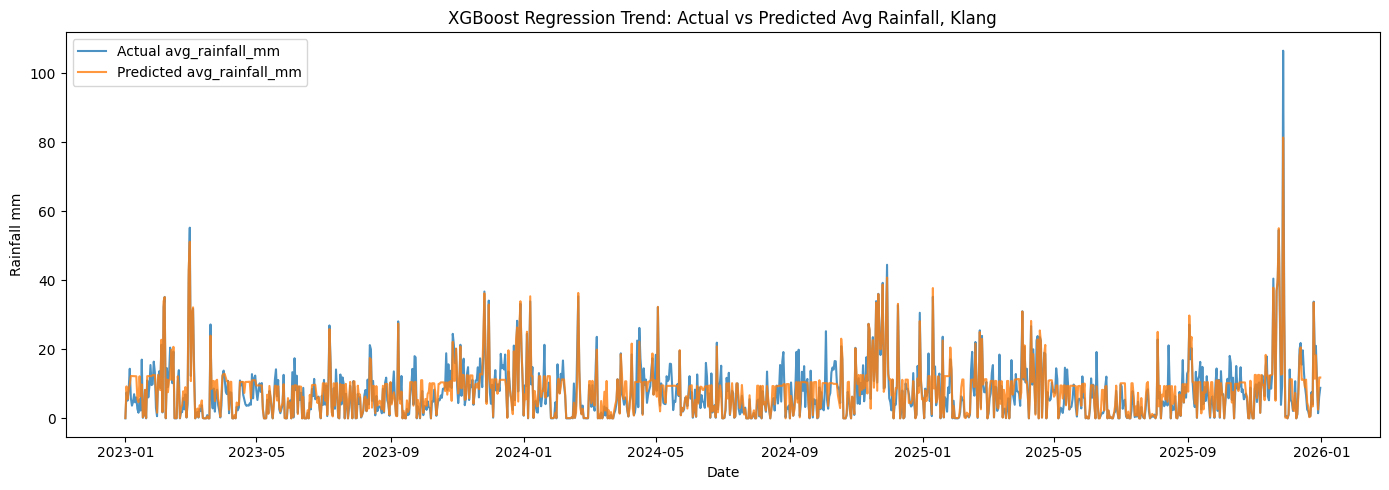


Feature importance for target: avg_rainfall_mm


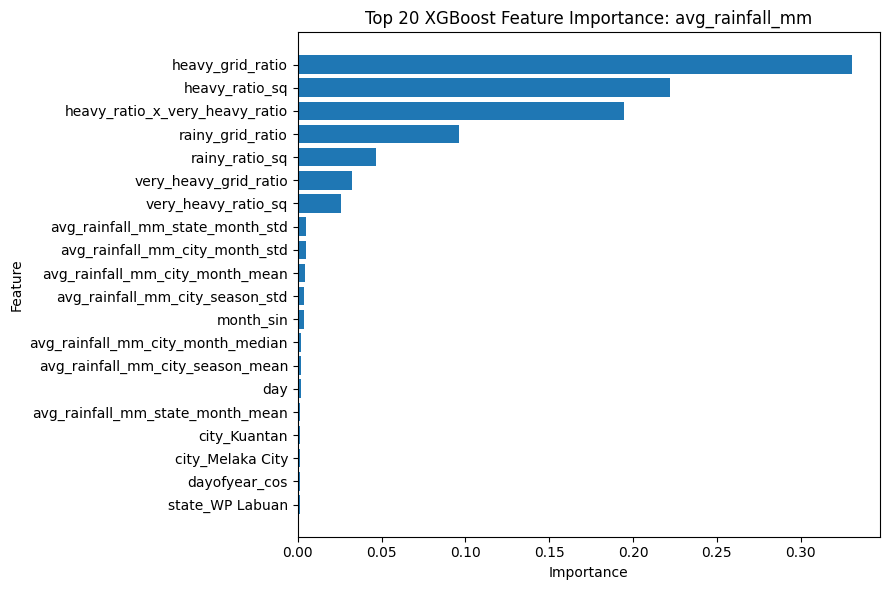

,feature,importance
14,heavy_grid_ratio,0.330766
18,heavy_ratio_sq,0.221855
16,heavy_ratio_x_very_heavy_ratio,0.194747
13,rainy_grid_ratio,0.095961
17,rainy_ratio_sq,0.046765
15,very_heavy_grid_ratio,0.032060
19,very_heavy_ratio_sq,0.025924
25,avg_rainfall_mm_state_month_std,0.005118
22,avg_rainfall_mm_city_month_std,0.004874
21,avg_rainfall_mm_city_month_mean,0.004285



Feature importance for target: max_rainfall_mm


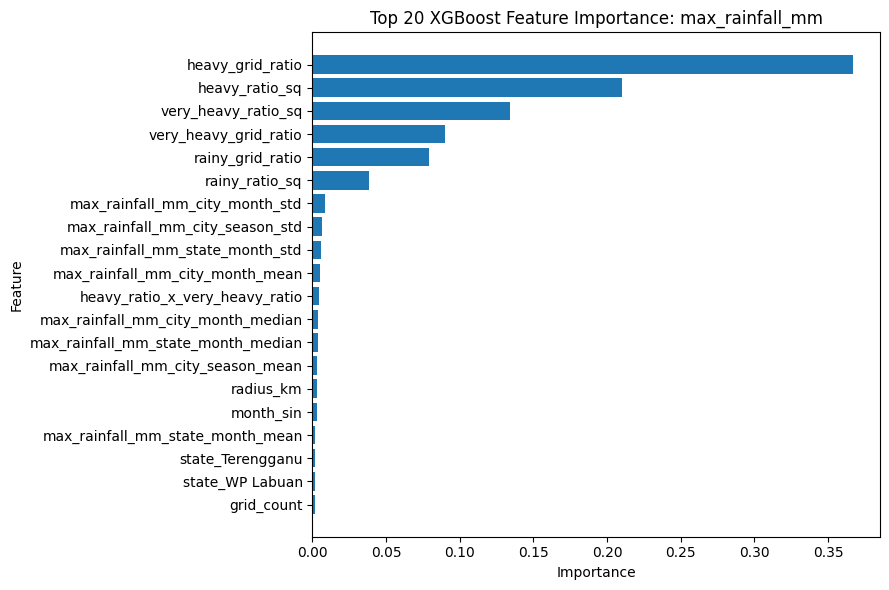

,feature,importance
14,heavy_grid_ratio,0.366831
18,heavy_ratio_sq,0.210009
19,very_heavy_ratio_sq,0.134063
15,very_heavy_grid_ratio,0.089969
13,rainy_grid_ratio,0.079034
17,rainy_ratio_sq,0.038668
22,max_rainfall_mm_city_month_std,0.008785
28,max_rainfall_mm_city_season_std,0.006694
25,max_rainfall_mm_state_month_std,0.006011
21,max_rainfall_mm_city_month_mean,0.005100



Feature importance for target: min_rainfall_mm


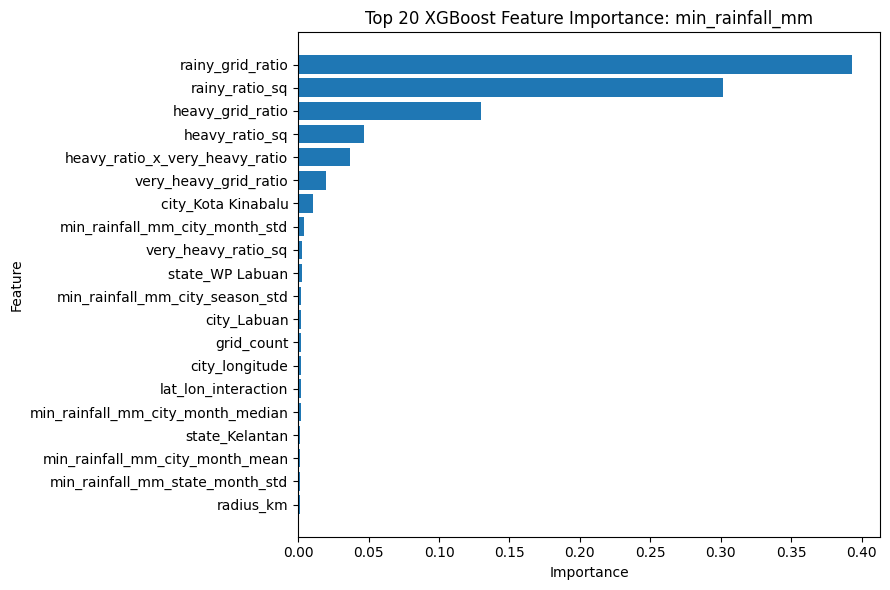

,feature,importance
13,rainy_grid_ratio,0.393331
17,rainy_ratio_sq,0.301354
14,heavy_grid_ratio,0.129642
18,heavy_ratio_sq,0.046796
16,heavy_ratio_x_very_heavy_ratio,0.036955
15,very_heavy_grid_ratio,0.019652
38,city_Kota Kinabalu,0.010457
22,min_rainfall_mm_city_month_std,0.004075
19,very_heavy_ratio_sq,0.002883
68,state_WP Labuan,0.002482


XGBoost regression visualizations saved to: /scr/user/kevin2002/TensorCat/Data Analysis/Group_Project/Data/Outputs/Regression_Analysis


In [25]:
# =========================================================
# Regression Visualization: XGBoost Actual vs Predicted + Trend Plots
# Compatible with target-specific tuned XGBoost models
# =========================================================

# ---------------------------------------------------------
# 0) Safety checks
# ---------------------------------------------------------
REGRESSION_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

required_prediction_cols = []

for target in targets_reg:
    required_prediction_cols.extend([
        f"actual_{target}",
        f"predicted_{target}",
    ])

missing_prediction_cols = [
    col for col in required_prediction_cols
    if col not in reg_pred_df.columns
]

if missing_prediction_cols:
    raise ValueError(
        f"Missing prediction columns in reg_pred_df: {missing_prediction_cols}\n"
        "Please rerun the XGBoost regression training cell first."
    )


# ---------------------------------------------------------
# 1) Actual vs predicted scatter plots for each rainfall target
# ---------------------------------------------------------
for target in targets_reg:
    plot_df = reg_pred_df[
        [f"actual_{target}", f"predicted_{target}"]
    ].sample(
        n=min(20000, len(reg_pred_df)),
        random_state=42,
    )

    plt.figure(figsize=(6, 6))

    plt.scatter(
        plot_df[f"actual_{target}"],
        plot_df[f"predicted_{target}"],
        alpha=0.25,
        s=6,
    )

    max_value = max(
        plot_df[f"actual_{target}"].max(),
        plot_df[f"predicted_{target}"].max(),
    )

    plt.plot([0, max_value], [0, max_value], linestyle="--")

    plt.xlabel(f"Actual {target}")
    plt.ylabel(f"Predicted {target}")
    plt.title(f"XGBoost Regression: Actual vs Predicted {target}")

    plt.tight_layout()
    plt.savefig(
        REGRESSION_OUTPUT_DIR / f"xgboost_actual_vs_predicted_{target}.png",
        dpi=200,
    )
    plt.show()


# ---------------------------------------------------------
# 2) Error distribution plots
# ---------------------------------------------------------
for target in targets_reg:
    error_col = f"error_{target}"

    if error_col not in reg_pred_df.columns:
        reg_pred_df[error_col] = (
            reg_pred_df[f"predicted_{target}"]
            - reg_pred_df[f"actual_{target}"]
        )

    plt.figure(figsize=(8, 5))

    plt.hist(
        reg_pred_df[error_col],
        bins=80,
        alpha=0.8,
    )

    plt.axvline(0, linestyle="--")

    plt.title(f"XGBoost Prediction Error Distribution: {target}")
    plt.xlabel("Predicted - Actual")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.savefig(
        REGRESSION_OUTPUT_DIR / f"xgboost_error_distribution_{target}.png",
        dpi=200,
    )
    plt.show()


# ---------------------------------------------------------
# 3) Time trend plot for one example city
# ---------------------------------------------------------
example_city = "Klang"

city_plot = reg_pred_df[
    reg_pred_df["city"] == example_city
].copy()

city_plot = city_plot.sort_values("date")

if not city_plot.empty:
    plt.figure(figsize=(14, 5))

    plt.plot(
        city_plot["date"],
        city_plot["actual_avg_rainfall_mm"],
        label="Actual avg_rainfall_mm",
        alpha=0.8,
    )

    plt.plot(
        city_plot["date"],
        city_plot["predicted_avg_rainfall_mm"],
        label="Predicted avg_rainfall_mm",
        alpha=0.8,
    )

    plt.title(
        f"XGBoost Regression Trend: Actual vs Predicted Avg Rainfall, {example_city}"
    )
    plt.xlabel("Date")
    plt.ylabel("Rainfall mm")
    plt.legend()

    plt.tight_layout()
    plt.savefig(
        REGRESSION_OUTPUT_DIR / f"xgboost_trend_{example_city}_avg_rainfall.png",
        dpi=200,
    )
    plt.show()
else:
    print(f"No records found for example city: {example_city}")


# ---------------------------------------------------------
# 4) Feature importance plots
# ---------------------------------------------------------
# Important:
# If you used target-specific tuning / climatology features,
# each target may have its own feature-name list.
# Therefore, use xgb_best_feature_names[target] when available.
# ---------------------------------------------------------

for target, model in xgb_models.items():
    print("\n" + "=" * 70)
    print(f"Feature importance for target: {target}")
    print("=" * 70)

    importance_values = model.feature_importances_

    # Preferred path for tuned target-specific model
    if "xgb_best_feature_names" in globals() and target in xgb_best_feature_names:
        feature_names = xgb_best_feature_names[target]

    # Fallback path for older/simple XGBoost version
    else:
        try:
            encoded_cat_names = xgb_encoder.get_feature_names_out(features_cat).tolist()
            feature_names = features_num + encoded_cat_names
        except Exception:
            feature_names = [f"feature_{i}" for i in range(len(importance_values))]

    # Final safety alignment
    if len(feature_names) != len(importance_values):
        print(
            f"Warning: feature name length ({len(feature_names)}) "
            f"does not match importance length ({len(importance_values)})."
        )
        print("Using generic feature names to avoid plotting error.")

        feature_names = [f"feature_{i}" for i in range(len(importance_values))]

    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importance_values,
    }).sort_values("importance", ascending=False)

    importance_df.to_csv(
        REGRESSION_OUTPUT_DIR / f"xgboost_feature_importance_{target}.csv",
        index=False,
    )

    top_df = importance_df.head(20)

    plt.figure(figsize=(9, 6))

    plt.barh(
        top_df["feature"][::-1],
        top_df["importance"][::-1],
    )

    plt.title(f"Top 20 XGBoost Feature Importance: {target}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")

    plt.tight_layout()
    plt.savefig(
        REGRESSION_OUTPUT_DIR / f"xgboost_feature_importance_{target}.png",
        dpi=200,
    )
    plt.show()

    display(top_df)


print("XGBoost regression visualizations saved to:", REGRESSION_OUTPUT_DIR)

# 11. Classification Analysis: Predicting Flood_Risk_Binary

This predicts the binary rainfall-based flood-risk proxy.

Important: we do not use `rainfall_risk_label` or `rainfall_risk_level` as input, because `Flood_Risk_Binary` is derived from those fields.

In [29]:
# =========================================================
# Classification Analysis:
# Predicting Flood_Risk_Binary
#
# This cell is self-contained.
# It does not depend on train_df / valid_df / test_df from Regression.
# =========================================================

# =========================================================
# 1) Output folder
# =========================================================
CLASSIFICATION_OUTPUT_DIR = OUTPUT_DIR / "Classification_Analysis"
CLASSIFICATION_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# =========================================================
# 2) Prepare classification dataframe
# =========================================================
clf_df = df_full_years.copy()
clf_df["date"] = pd.to_datetime(clf_df["date"])

if "Flood_Risk_Binary" not in clf_df.columns:
    clf_df["Flood_Risk_Binary"] = (clf_df["rainfall_risk_label"] == 3).astype(int)

# Full-year modelling only. 2026 is partial-year data.
clf_df = clf_df[clf_df["year"] <= 2025].copy()

# Calendar / seasonal features
clf_df["dayofyear"] = clf_df["date"].dt.dayofyear.astype(int)
clf_df["weekofyear"] = clf_df["date"].dt.isocalendar().week.astype(int)

clf_df["month_sin"] = np.sin(2 * np.pi * clf_df["month"] / 12)
clf_df["month_cos"] = np.cos(2 * np.pi * clf_df["month"] / 12)
clf_df["dayofyear_sin"] = np.sin(2 * np.pi * clf_df["dayofyear"] / 366)
clf_df["dayofyear_cos"] = np.cos(2 * np.pi * clf_df["dayofyear"] / 366)

def malaysia_season(month):
    if month in [11, 12, 1, 2, 3]:
        return "Northeast_Monsoon"
    if month in [5, 6, 7, 8, 9]:
        return "Southwest_Monsoon"
    return "Inter_Monsoon"

clf_df["season"] = clf_df["month"].apply(malaysia_season)


# =========================================================
# 3) Independent time-based split
# =========================================================
train_df_cls = clf_df[clf_df["year"] <= 2020].copy()
valid_df_cls = clf_df[(clf_df["year"] >= 2021) & (clf_df["year"] <= 2022)].copy()
test_df_cls = clf_df[(clf_df["year"] >= 2023) & (clf_df["year"] <= 2025)].copy()

print("Classification Train:", train_df_cls.shape)
print("Classification Valid:", valid_df_cls.shape)
print("Classification Test :", test_df_cls.shape)


# =========================================================
# 4) Feature setup
# =========================================================
# Do NOT use rainfall_risk_label or rainfall_risk_level,
# because Flood_Risk_Binary is derived from rainfall_risk_label.
features_num_cls = [
    "year",
    "month",
    "day",
    "dayofyear",
    "weekofyear",
    "month_sin",
    "month_cos",
    "dayofyear_sin",
    "dayofyear_cos",
    "city_latitude",
    "city_longitude",
    "radius_km",
    "grid_count",
    "avg_rainfall_mm",
    "max_rainfall_mm",
    "min_rainfall_mm",
    "median_rainfall_mm",
    "rainy_grid_ratio",
    "heavy_grid_ratio",
    "very_heavy_grid_ratio",
]

features_cat_cls = [
    "city",
    "state",
    "season",
]

feature_cols_cls = features_num_cls + features_cat_cls
target_cls = "Flood_Risk_Binary"

required_cols_cls = feature_cols_cls + [target_cls]

missing_cols_cls = [col for col in required_cols_cls if col not in clf_df.columns]
if missing_cols_cls:
    raise ValueError(f"Missing classification columns: {missing_cols_cls}")

train_df_cls = train_df_cls.dropna(subset=required_cols_cls).copy()
valid_df_cls = valid_df_cls.dropna(subset=required_cols_cls).copy()
test_df_cls = test_df_cls.dropna(subset=required_cols_cls).copy()


# =========================================================
# 5) Preprocessing
# =========================================================
try:
    encoder_cls = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    encoder_cls = OneHotEncoder(handle_unknown="ignore", sparse=False)

clf_preprocess = ColumnTransformer([
    ("num", StandardScaler(), features_num_cls),
    ("cat", encoder_cls, features_cat_cls),
])

X_train_cls = clf_preprocess.fit_transform(train_df_cls[feature_cols_cls]).astype(np.float32)
X_valid_cls = clf_preprocess.transform(valid_df_cls[feature_cols_cls]).astype(np.float32)
X_test_cls = clf_preprocess.transform(test_df_cls[feature_cols_cls]).astype(np.float32)

y_train_cls = train_df_cls[target_cls].to_numpy(dtype=np.int64)
y_valid_cls = valid_df_cls[target_cls].to_numpy(dtype=np.int64)
y_test_cls = test_df_cls[target_cls].to_numpy(dtype=np.int64)

print("X_train_cls:", X_train_cls.shape)
print("X_valid_cls:", X_valid_cls.shape)
print("X_test_cls :", X_test_cls.shape)

print("\nTrain target distribution:")
print(pd.Series(y_train_cls).value_counts().sort_index())

print("\nTest target distribution:")
print(pd.Series(y_test_cls).value_counts().sort_index())


# =========================================================
# 6) Train classification models
# =========================================================
models_cls = {
    "RandomForestClassifier": RandomForestClassifier(
        n_estimators=160,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced",
    ),
    "GradientBoostingClassifier": GradientBoostingClassifier(
        random_state=42,
    ),
}

classification_results = []
classification_predictions = {}

for model_name, model in models_cls.items():
    print("\n" + "=" * 70)
    print(f"Training classifier: {model_name}")
    print("=" * 70)

    model.fit(X_train_cls, y_train_cls)

    pred_test = model.predict(X_test_cls)

    try:
        pred_proba = model.predict_proba(X_test_cls)[:, 1]
        roc_auc = roc_auc_score(y_test_cls, pred_proba)
    except Exception:
        pred_proba = None
        roc_auc = np.nan

    accuracy = accuracy_score(y_test_cls, pred_test)
    precision = precision_score(y_test_cls, pred_test, zero_division=0)
    recall = recall_score(y_test_cls, pred_test, zero_division=0)
    f1 = f1_score(y_test_cls, pred_test, zero_division=0)

    classification_results.append({
        "model": model_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc,
    })

    classification_predictions[model_name] = pred_test

    print(f"Accuracy : {accuracy:.5f}")
    print(f"Precision: {precision:.5f}")
    print(f"Recall   : {recall:.5f}")
    print(f"F1       : {f1:.5f}")
    print(f"ROC AUC  : {roc_auc:.5f}" if not np.isnan(roc_auc) else "ROC AUC  : NaN")

    # Save classification report
    report = classification_report(
        y_test_cls,
        pred_test,
        zero_division=0,
        output_dict=True,
    )

    pd.DataFrame(report).T.to_csv(
        CLASSIFICATION_OUTPUT_DIR / f"classification_report_{model_name}.csv"
    )

    # Save confusion matrix
    cm = confusion_matrix(y_test_cls, pred_test)

    pd.DataFrame(
        cm,
        index=["actual_0", "actual_1"],
        columns=["pred_0", "pred_1"],
    ).to_csv(
        CLASSIFICATION_OUTPUT_DIR / f"confusion_matrix_{model_name}.csv"
    )

    # Save test predictions
    pred_out = test_df_cls[["date", "year", "month", "day", "state", "city", target_cls]].copy()
    pred_out[f"predicted_{target_cls}"] = pred_test

    if pred_proba is not None:
        pred_out[f"predicted_probability_{target_cls}_1"] = pred_proba

    pred_out.to_csv(
        CLASSIFICATION_OUTPUT_DIR / f"classification_test_predictions_{model_name}.csv",
        index=False,
    )


# =========================================================
# 7) Save final result table
# =========================================================
classification_results_df = pd.DataFrame(classification_results)
classification_results_df.to_csv(
    CLASSIFICATION_OUTPUT_DIR / "classification_model_results.csv",
    index=False,
)

print("\n================ Classification Results ================")
display(classification_results_df)

print("\nClassification outputs saved to:")
print(CLASSIFICATION_OUTPUT_DIR)

Classification Train: (191775, 32)
Classification Valid: (18250, 32)
Classification Test : (27400, 32)
X_train_cls: (191775, 64)
X_valid_cls: (18250, 64)
X_test_cls : (27400, 64)

Train target distribution:
0    188221
1      3554
Name: count, dtype: int64

Test target distribution:
0    26755
1      645
Name: count, dtype: int64

Training classifier: RandomForestClassifier
Accuracy : 1.00000
Precision: 1.00000
Recall   : 1.00000
F1       : 1.00000
ROC AUC  : 1.00000

Training classifier: GradientBoostingClassifier
Accuracy : 1.00000
Precision: 1.00000
Recall   : 1.00000
F1       : 1.00000
ROC AUC  : 1.00000

================ Classification Results ================


,model,accuracy,precision,recall,f1,roc_auc
0,RandomForestClassifier,1.0,1.0,1.0,1.0,1.0
1,GradientBoostingClassifier,1.0,1.0,1.0,1.0,1.0



Classification outputs saved to:
/scr/user/kevin2002/TensorCat/Data Analysis/Group_Project/Data/Outputs/Classification_Analysis


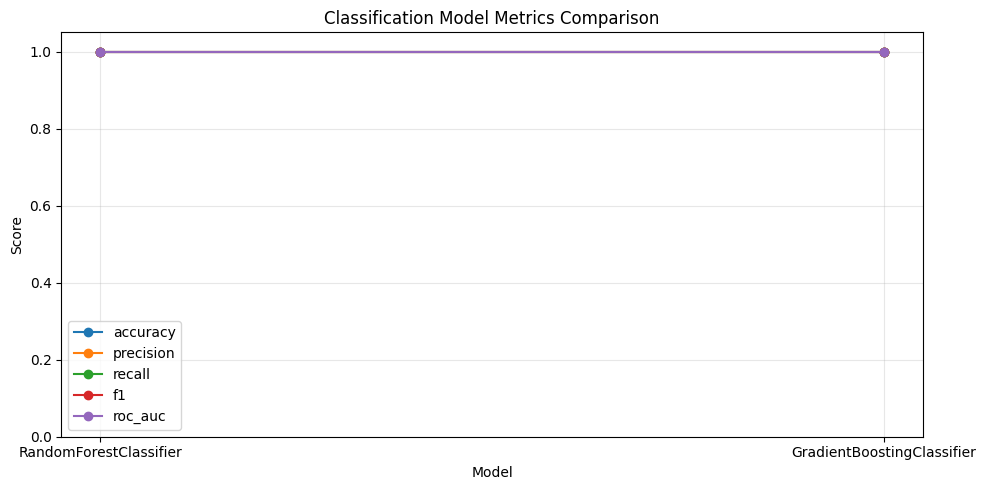


Confusion Matrix: RandomForestClassifier


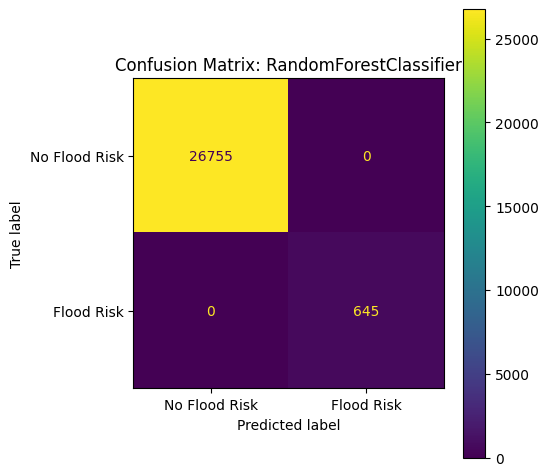

          pred_0  pred_1
actual_0   26755       0
actual_1       0     645

Confusion Matrix: GradientBoostingClassifier


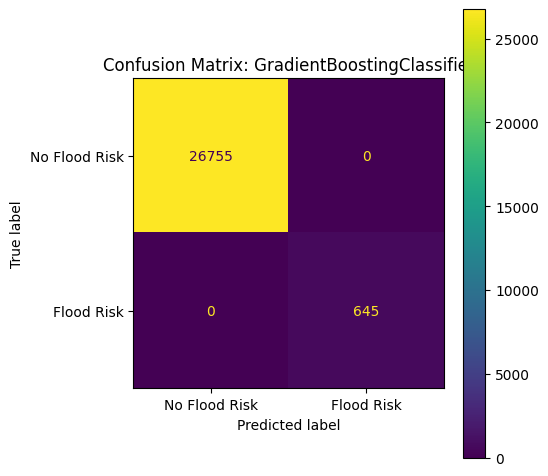

          pred_0  pred_1
actual_0   26755       0
actual_1       0     645


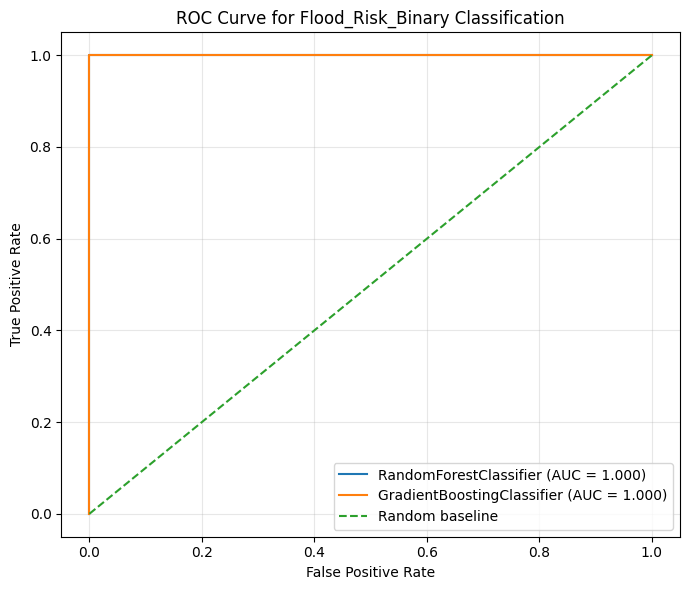

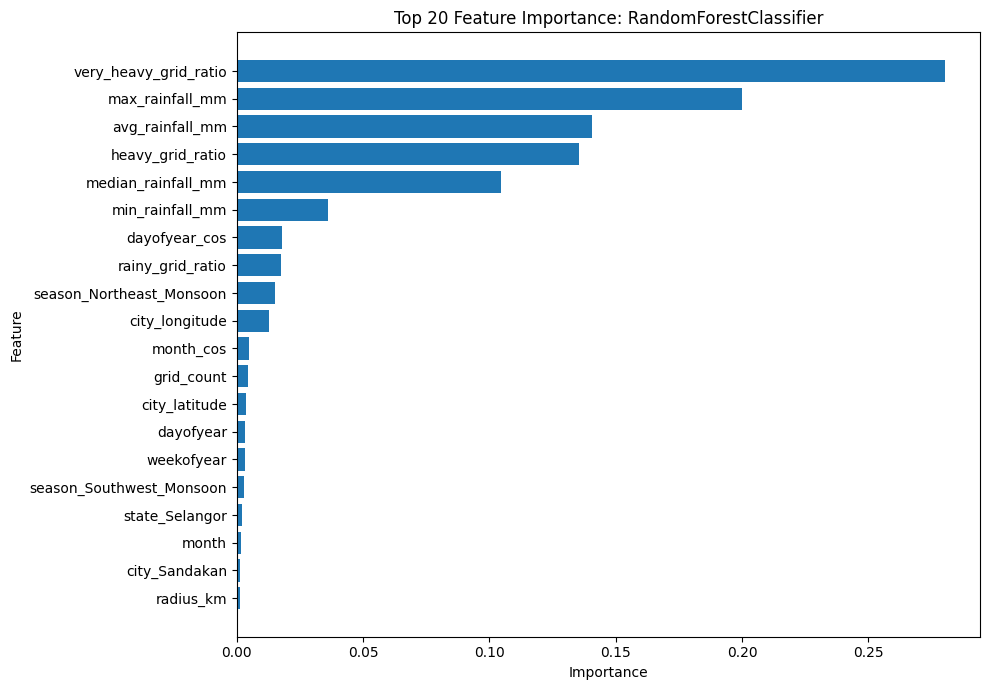


Top features for RandomForestClassifier:


,feature,importance
19,very_heavy_grid_ratio,0.280196
14,max_rainfall_mm,0.199935
13,avg_rainfall_mm,0.140786
18,heavy_grid_ratio,0.135629
16,median_rainfall_mm,0.104640
15,min_rainfall_mm,0.036120
8,dayofyear_cos,0.018017
17,rainy_grid_ratio,0.017446
62,season_Northeast_Monsoon,0.015223
10,city_longitude,0.012699


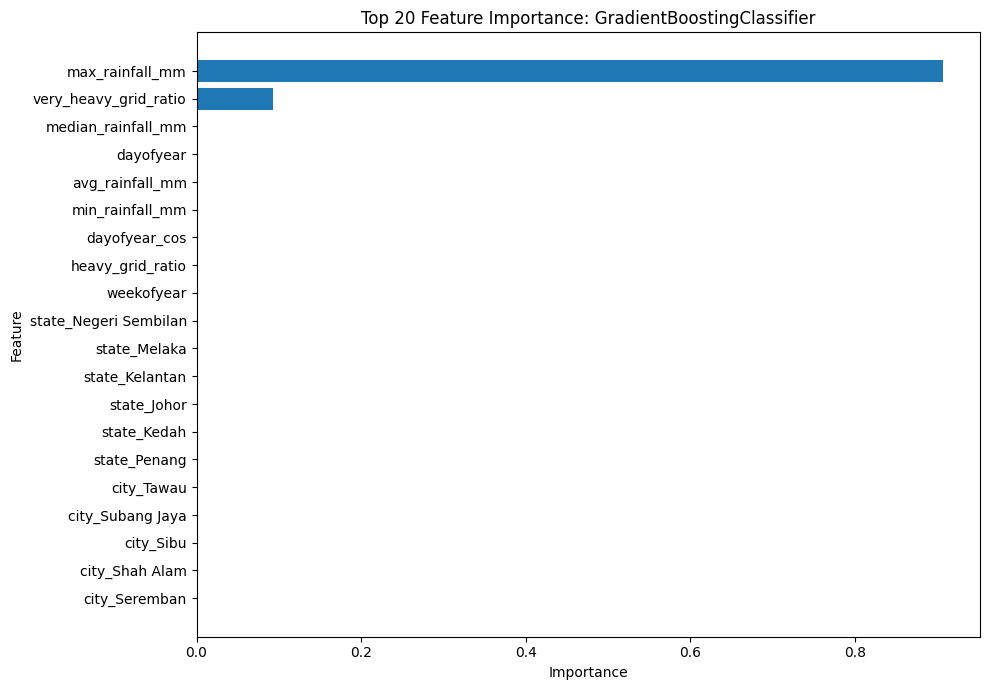


Top features for GradientBoostingClassifier:


,feature,importance
14,max_rainfall_mm,9.069515e-01
19,very_heavy_grid_ratio,9.304852e-02
16,median_rainfall_mm,2.830874e-13
3,dayofyear,7.683384e-14
13,avg_rainfall_mm,6.221727e-14
15,min_rainfall_mm,2.488259e-14
8,dayofyear_cos,2.421369e-14
18,heavy_grid_ratio,7.088807e-15
4,weekofyear,6.060788e-15
49,state_Negeri Sembilan,0.000000e+00



Classification visualizations saved to:
/scr/user/kevin2002/TensorCat/Data Analysis/Group_Project/Data/Outputs/Classification_Analysis


In [30]:
# =========================================================
# Classification Visualization:
# Metrics, Confusion Matrix, ROC Curve, and Feature Importance
#
# This cell is designed for sklearn classifiers.
# It does NOT require clf_history because RandomForest / GradientBoosting
# do not train by epoch like neural networks.
# =========================================================

CLASSIFICATION_OUTPUT_DIR = OUTPUT_DIR / "Classification_Analysis"
CLASSIFICATION_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# =========================================================
# 1) Safety checks
# =========================================================
required_vars = [
    "classification_results_df",
    "models_cls",
    "X_test_cls",
    "y_test_cls",
    "feature_cols_cls",
    "features_num_cls",
    "features_cat_cls",
    "clf_preprocess",
]

missing_vars = [name for name in required_vars if name not in globals()]

if missing_vars:
    raise ValueError(
        f"Missing variables for classification visualization: {missing_vars}\n"
        "Please rerun the Classification training cell first."
    )


# =========================================================
# 2) Metrics comparison bar chart
# =========================================================
metrics_to_plot = ["accuracy", "precision", "recall", "f1", "roc_auc"]

available_metrics = [
    col for col in metrics_to_plot
    if col in classification_results_df.columns
]

metrics_long = classification_results_df.melt(
    id_vars="model",
    value_vars=available_metrics,
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(10, 5))

for metric in available_metrics:
    subset = metrics_long[metrics_long["metric"] == metric]
    plt.plot(
        subset["model"],
        subset["score"],
        marker="o",
        label=metric,
    )

plt.title("Classification Model Metrics Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    CLASSIFICATION_OUTPUT_DIR / "classification_metrics_comparison.png",
    dpi=200,
)
plt.show()


# =========================================================
# 3) Confusion matrix for each classifier
# =========================================================
for model_name, model in models_cls.items():
    print("\n" + "=" * 70)
    print(f"Confusion Matrix: {model_name}")
    print("=" * 70)

    pred_test = model.predict(X_test_cls)

    cm = confusion_matrix(y_test_cls, pred_test)

    # Save confusion matrix as CSV
    cm_df = pd.DataFrame(
        cm,
        index=["actual_0", "actual_1"],
        columns=["pred_0", "pred_1"],
    )

    cm_df.to_csv(
        CLASSIFICATION_OUTPUT_DIR / f"confusion_matrix_{model_name}.csv",
        index=True,
    )

    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Flood Risk", "Flood Risk"],
    )

    fig, ax = plt.subplots(figsize=(5.5, 5))
    disp.plot(
        ax=ax,
        values_format="d",
        colorbar=True,
    )

    ax.set_title(f"Confusion Matrix: {model_name}")
    plt.tight_layout()

    plt.savefig(
        CLASSIFICATION_OUTPUT_DIR / f"confusion_matrix_{model_name}.png",
        dpi=200,
    )
    plt.show()

    print(cm_df)


# =========================================================
# 4) ROC curve for classifiers with predict_proba
# =========================================================
plt.figure(figsize=(7, 6))

has_roc_curve = False

for model_name, model in models_cls.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_cls)[:, 1]

        fpr, tpr, _ = roc_curve(y_test_cls, y_score)
        roc_auc_value = auc(fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            label=f"{model_name} (AUC = {roc_auc_value:.3f})",
        )

        has_roc_curve = True

if has_roc_curve:
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random baseline")

    plt.title("ROC Curve for Flood_Risk_Binary Classification")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    plt.savefig(
        CLASSIFICATION_OUTPUT_DIR / "classification_roc_curve.png",
        dpi=200,
    )
    plt.show()
else:
    plt.close()
    print("No classifier with predict_proba found. ROC curve skipped.")


# =========================================================
# 5) Feature names after preprocessing
# =========================================================
try:
    encoder_fitted = clf_preprocess.named_transformers_["cat"]
    encoded_cat_names = encoder_fitted.get_feature_names_out(features_cat_cls).tolist()
    classification_feature_names = features_num_cls + encoded_cat_names

except Exception as e:
    print("Could not recover encoded feature names. Using generic feature names.")
    print("Original error:", e)
    classification_feature_names = [
        f"feature_{i}" for i in range(X_test_cls.shape[1])
    ]


# =========================================================
# 6) Feature importance for models that support it
# =========================================================
for model_name, model in models_cls.items():
    if not hasattr(model, "feature_importances_"):
        print(f"{model_name} does not provide feature_importances_. Skipped.")
        continue

    importance_values = model.feature_importances_

    if len(classification_feature_names) != len(importance_values):
        print(
            f"Feature name length mismatch for {model_name}: "
            f"{len(classification_feature_names)} names vs "
            f"{len(importance_values)} importance values."
        )
        print("Using generic feature names for this model.")

        feature_names_safe = [
            f"feature_{i}" for i in range(len(importance_values))
        ]
    else:
        feature_names_safe = classification_feature_names

    importance_df = pd.DataFrame({
        "feature": feature_names_safe,
        "importance": importance_values,
    }).sort_values("importance", ascending=False)

    importance_df.to_csv(
        CLASSIFICATION_OUTPUT_DIR / f"classification_feature_importance_{model_name}.csv",
        index=False,
    )

    top_df = importance_df.head(20)

    plt.figure(figsize=(10, 7))
    plt.barh(
        top_df["feature"][::-1],
        top_df["importance"][::-1],
    )

    plt.title(f"Top 20 Feature Importance: {model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()

    plt.savefig(
        CLASSIFICATION_OUTPUT_DIR / f"classification_feature_importance_{model_name}.png",
        dpi=200,
    )
    plt.show()

    print(f"\nTop features for {model_name}:")
    display(top_df)


print("\nClassification visualizations saved to:")
print(CLASSIFICATION_OUTPUT_DIR)

# 12. Neural Network Time-Series Prediction: Pretrained PatchTST Transformer

This section replaces the previous PatchTST implementation. The reason is practical: PatchTST required `pytorch-forecasting` + `lightning`, and the DICC environment produced CUDA/cuDNN native crashes during training.

This new section uses **PatchTST**, a Transformer-based time-series model that converts historical time-series windows into patches before Transformer encoding. The notebook first attempts **pretrained PatchTST transfer learning** through Hugging Face Transformers. If the pretrained checkpoint cannot be downloaded or has incompatible heads, the code automatically falls back to a randomly initialized PatchTST with the same project task.

Forecasting task:

- Input: previous daily rainfall sequence for each city
- Output: next-day `avg_rainfall_mm`, `max_rainfall_mm`, and `min_rainfall_mm`
- Then convert the predicted rainfall values into predicted rainfall intensity level and `Flood_Risk_Binary`

Data split:

- Train: 2000–2020
- Validation: 2021–2022
- Test: 2023–2025
- 2026: partial-year model performance demonstration

Reference implementation source: Hugging Face `transformers` PatchTST model API.


In [5]:
# Optional installation. Run only if needed.
# !pip install -U transformers accelerate

# PatchTST section control.
# Set to True when transformers is installed and you want to train the PatchTST model.
RUN_PATCHTST = True

# Pretrained PatchTST model.
# The code will attempt to load this checkpoint first. If it fails, it falls back to a random PatchTST config.
PATCHTST_MODEL_ID = "ibm-granite/granite-timeseries-patchtst"

print("RUN_PATCHTST:", RUN_PATCHTST)
print("PatchTST pretrained checkpoint:", PATCHTST_MODEL_ID)
print("Selected PyTorch device from setup cell:", DEVICE)


RUN_PATCHTST: True
PatchTST pretrained checkpoint: ibm-granite/granite-timeseries-patchtst
Selected PyTorch device from setup cell: cuda


Using CUDA GPU for PatchTST: NVIDIA A100-SXM4-80GB
PatchTST device: cuda
PatchTST output folder: /scr/user/kevin2002/TensorCat/Data Analysis/Group_Project/Data/Outputs/PatchTST_Time_Series_Prediction
Using spatial features: city_latitude, city_longitude

================ PatchTST V5 Data Setup ================
Features: ['log1p_avg_rainfall_mm', 'log1p_max_rainfall_mm', 'log1p_median_rainfall_mm', 'log1p_min_rainfall_mm', 'rainy_grid_ratio', 'heavy_grid_ratio', 'very_heavy_grid_ratio', 'month_sin', 'month_cos', 'dayofyear_sin', 'dayofyear_cos', 'city_latitude', 'city_longitude', 'log1p_clim_city_month_avg_rainfall', 'log1p_clim_city_month_max_rainfall']
Targets: ['avg_rainfall_mm', 'max_rainfall_mm']
Train: 191025 | Valid: 18250 | Test: 27400 | 2026: 2250

PatchTST V5 model ready.
Total parameters: 0.536M
Pooling type: mean

================ PatchTST V5 Training Start ================
Epoch 001 | Train Loss: 0.473428 | Valid Loss: 0.436782 | Valid avg R2: 0.0847 | Valid max R2: 0.1478 

,split,target,version,MAE,RMSE,R2
0,validation_2021_2022,avg_rainfall_mm,raw,6.210278,9.837702,0.159252
1,validation_2021_2022,avg_rainfall_mm,calibrated,6.326106,9.845165,0.157976
2,validation_2021_2022,max_rainfall_mm,raw,9.768427,14.703466,0.206933
3,validation_2021_2022,max_rainfall_mm,calibrated,9.995759,14.834554,0.192729
4,test_2023_2025,avg_rainfall_mm,raw,6.132554,10.156284,0.177027
5,test_2023_2025,avg_rainfall_mm,calibrated,6.262220,10.145837,0.178719
6,test_2023_2025,max_rainfall_mm,raw,9.734274,15.003692,0.236055
7,test_2023_2025,max_rainfall_mm,calibrated,10.011973,15.139524,0.222160
8,demo_2026_partial,avg_rainfall_mm,raw,5.316566,10.428043,0.153445
9,demo_2026_partial,avg_rainfall_mm,calibrated,5.420888,10.475702,0.145689



================ PatchTST V5 Flood-Risk Metrics ================


,split,accuracy,precision,recall,f1,actual_positive_count,predicted_positive_count
0,validation_2021_2022,0.976877,0.383721,0.172775,0.238267,382,172
1,test_2023_2025,0.975511,0.450000,0.181395,0.258564,645,260
2,demo_2026_partial,0.965778,0.500000,0.129870,0.206186,77,20


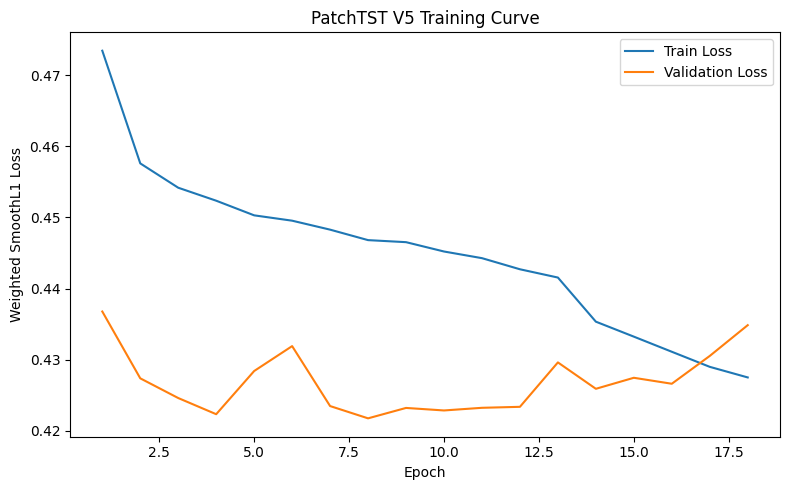

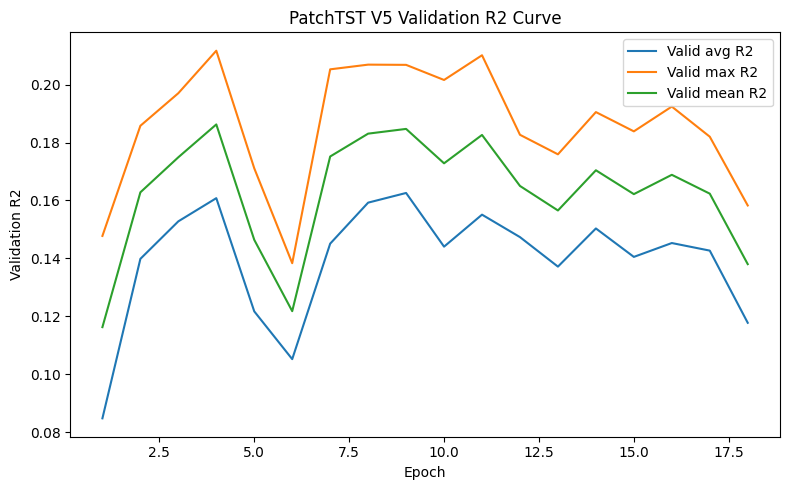

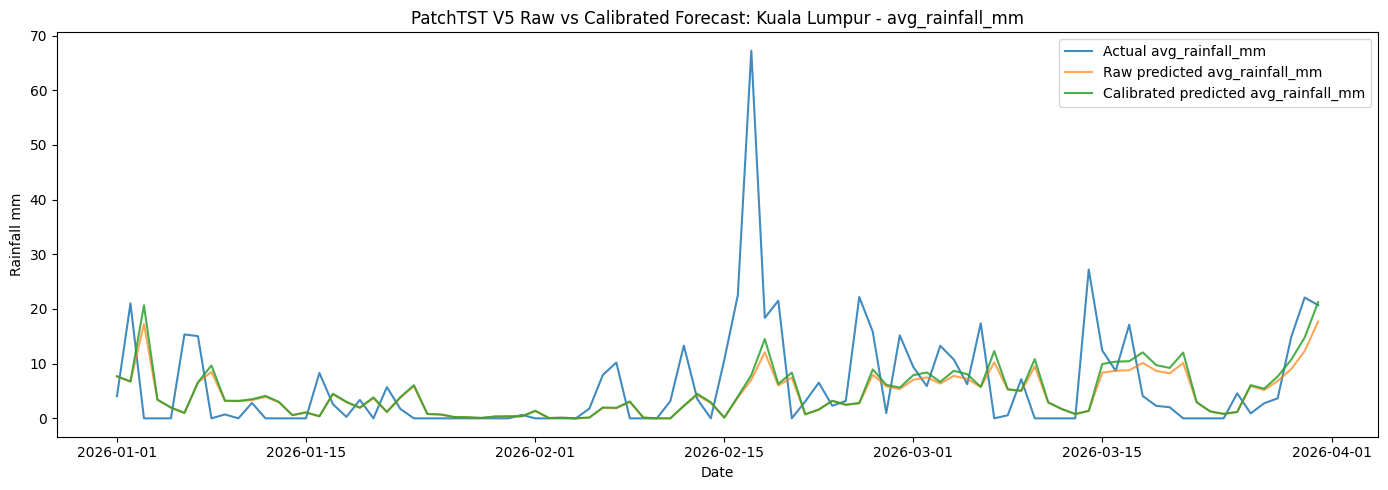

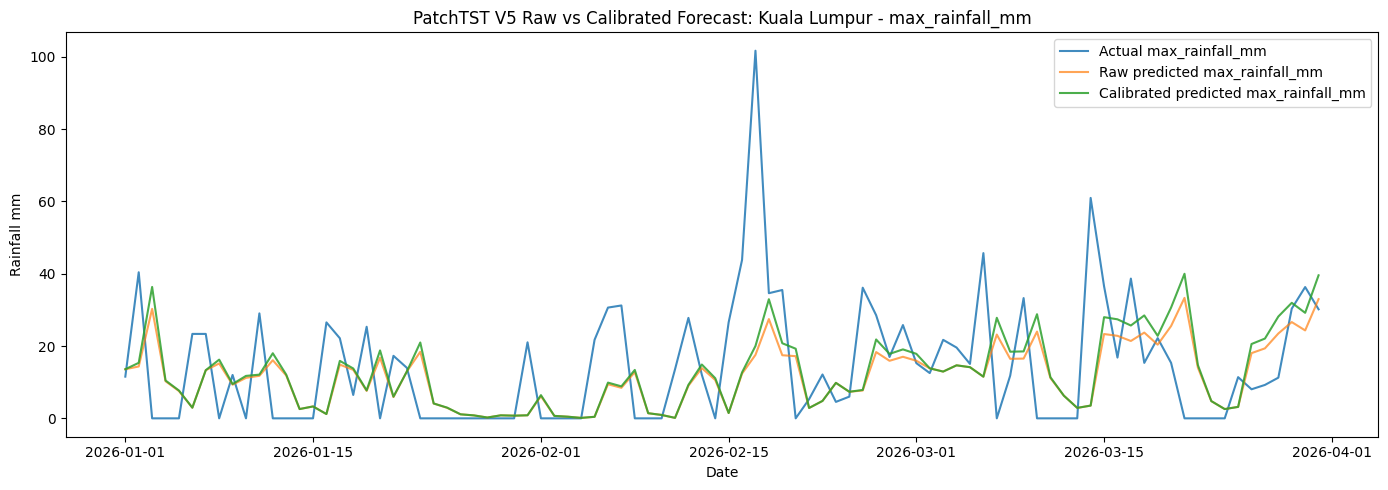

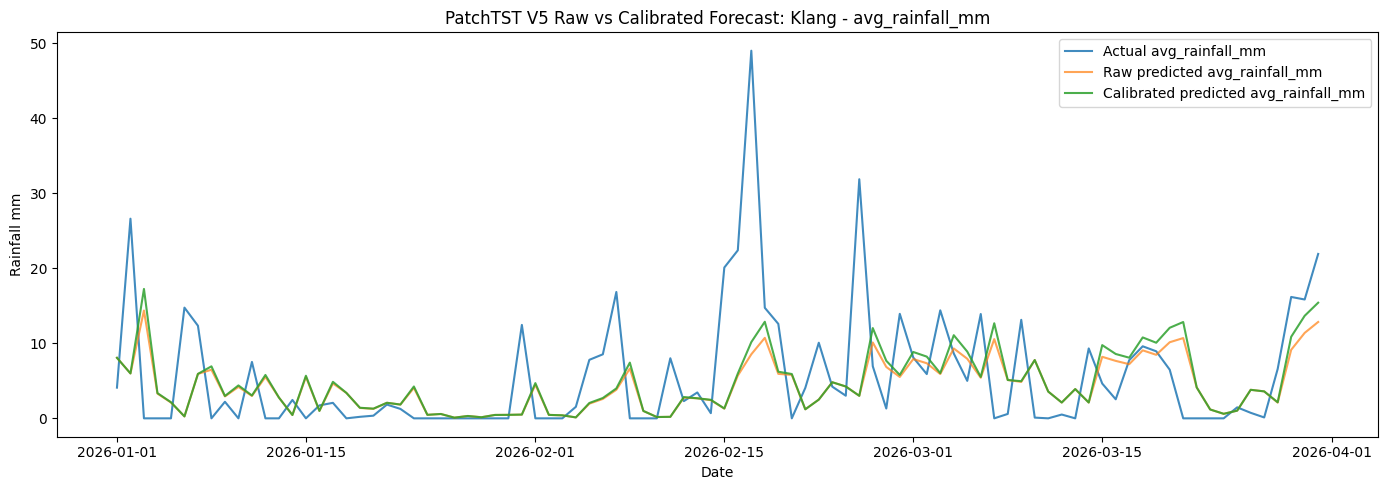

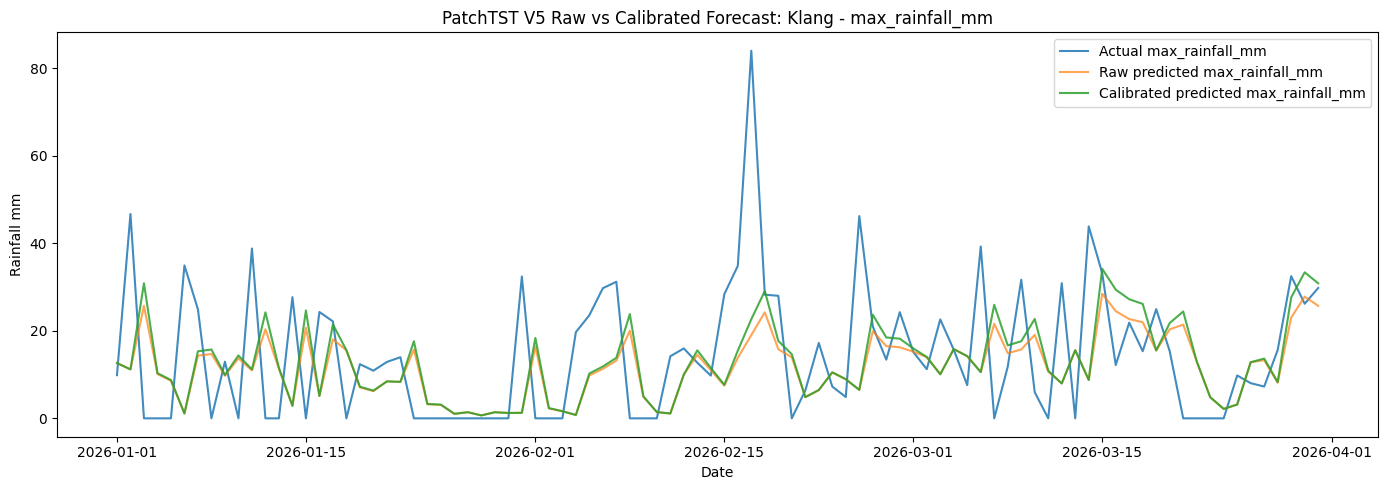

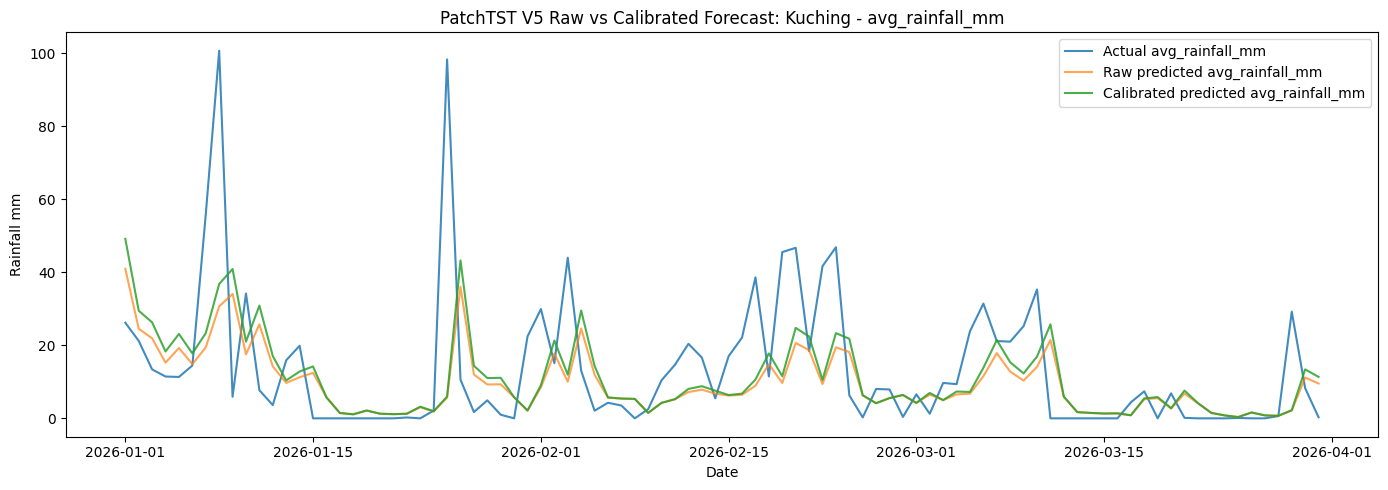

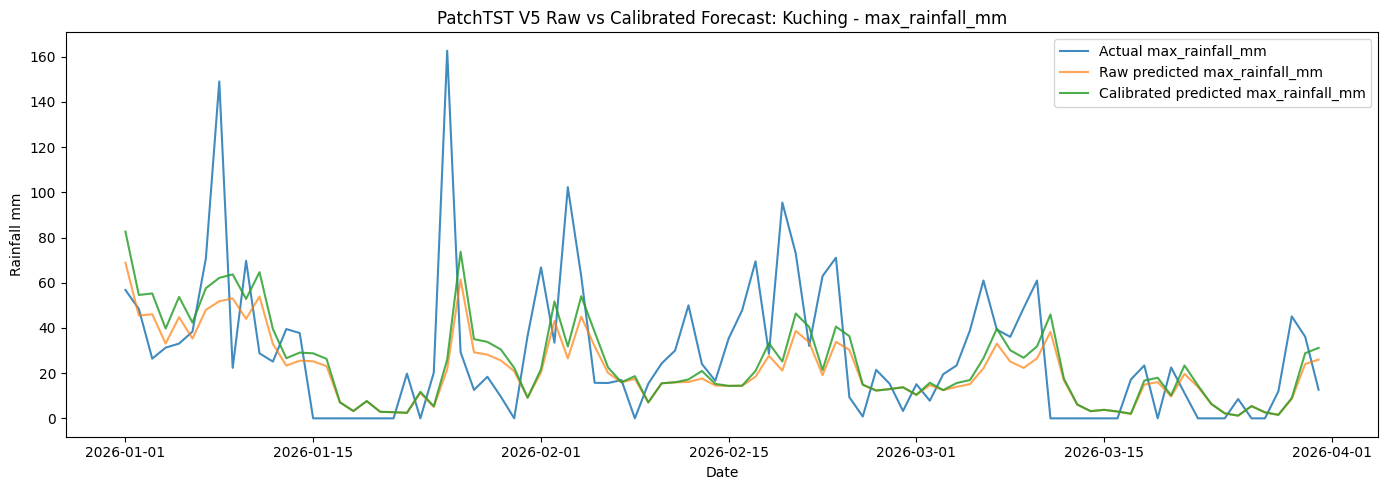


PatchTST V5 completed.
Outputs saved to: /scr/user/kevin2002/TensorCat/Data Analysis/Group_Project/Data/Outputs/PatchTST_Time_Series_Prediction

Generated V5 files:
- patchtst_v5_2026_Klang_avg.png
- patchtst_v5_2026_Klang_max.png
- patchtst_v5_2026_Kuala_Lumpur_avg.png
- patchtst_v5_2026_Kuala_Lumpur_max.png
- patchtst_v5_2026_Kuching_avg.png
- patchtst_v5_2026_Kuching_max.png
- patchtst_v5_2026_partial_predictions.csv
- patchtst_v5_demo_2026_partial_confusion_matrix.csv
- patchtst_v5_flood_risk_metrics.csv
- patchtst_v5_model.pt
- patchtst_v5_multiplier_avg_rainfall_mm.csv
- patchtst_v5_multiplier_max_rainfall_mm.csv
- patchtst_v5_raw_vs_calibrated_metrics.csv
- patchtst_v5_test_2023_2025_confusion_matrix.csv
- patchtst_v5_test_2023_2025_predictions.csv
- patchtst_v5_training_curve.png
- patchtst_v5_training_history.csv
- patchtst_v5_validation_2021_2022_confusion_matrix.csv
- patchtst_v5_validation_predictions.csv
- patchtst_v5_validation_r2_curve.png


In [8]:
# =========================================================
# PatchTST V5: Training + Loss Optimization + Adaptive Trend Amplification
#
# Goal:
# - Train a short-context PatchTST model for next-day rainfall forecasting.
# - Predict only avg_rainfall_mm and max_rainfall_mm.
# - Use light high-rain weighted loss to reduce peak underestimation.
# - After training, learn validation-based calibration multipliers.
# - Apply adaptive amplification only to likely rising/high-rain regions.
# - Save metrics, CSV outputs, and plots directly.
#
# Split:
# Train      2000-2020
# Validation 2021-2022
# Test       2023-2025
# Demo       2026 partial year
# =========================================================

if RUN_PATCHTST:
    import gc
    import warnings
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    import torch
    import torch.nn as nn
    from torch.utils.data import Dataset, DataLoader

    from sklearn.metrics import (
        mean_absolute_error,
        r2_score,
        accuracy_score,
        precision_score,
        recall_score,
        f1_score,
        confusion_matrix,
    )

    try:
        from sklearn.metrics import root_mean_squared_error

        def rmse_score(y_true, y_pred):
            return root_mean_squared_error(y_true, y_pred)

    except ImportError:
        from sklearn.metrics import mean_squared_error

        def rmse_score(y_true, y_pred):
            return mean_squared_error(y_true, y_pred, squared=False)

    try:
        from transformers import PatchTSTConfig, PatchTSTForRegression, set_seed
    except ImportError as e:
        raise ImportError(
            "PatchTST requires Hugging Face Transformers:\n"
            "pip install -U transformers accelerate"
        ) from e

    # =========================================================
    # 1) Basic setup
    # =========================================================
    PATCHTST_OUTPUT_DIR = OUTPUT_DIR / "PatchTST_Time_Series_Prediction"
    PATCHTST_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    set_seed(42)
    np.random.seed(42)
    torch.manual_seed(42)

    if torch.cuda.is_available():
        torch.backends.cudnn.enabled = False
        torch.cuda.empty_cache()
        torch.set_float32_matmul_precision("medium")
        DEVICE_PATCHTST = torch.device("cuda")
        print("Using CUDA GPU for PatchTST:", torch.cuda.get_device_name(0))
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        DEVICE_PATCHTST = torch.device("mps")
        print("Using Apple MPS for PatchTST.")
    else:
        DEVICE_PATCHTST = torch.device("cpu")
        print("Using CPU for PatchTST.")

    print("PatchTST device:", DEVICE_PATCHTST)
    print("PatchTST output folder:", PATCHTST_OUTPUT_DIR)

    # =========================================================
    # 2) Data preparation
    # =========================================================
    patch_df = df.copy()
    patch_df["date"] = pd.to_datetime(patch_df["date"])
    patch_df = patch_df.sort_values(["city", "date"]).reset_index(drop=True)

    patch_targets = ["avg_rainfall_mm", "max_rainfall_mm"]
    ratio_cols = ["rainy_grid_ratio", "heavy_grid_ratio", "very_heavy_grid_ratio"]

    rainfall_input_cols = ["avg_rainfall_mm", "max_rainfall_mm", "median_rainfall_mm"]
    if "min_rainfall_mm" in patch_df.columns:
        rainfall_input_cols.append("min_rainfall_mm")

    required_cols = [
        "date", "year", "month", "day", "state", "city",
        "avg_rainfall_mm", "max_rainfall_mm", "median_rainfall_mm",
        "rainy_grid_ratio", "heavy_grid_ratio", "very_heavy_grid_ratio",
    ]
    missing_cols = [c for c in required_cols if c not in patch_df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")

    # Spatial features
    lat_candidates = ["city_latitude", "latitude", "lat"]
    lon_candidates = ["city_longitude", "longitude", "lon", "lng"]

    lat_col = next((c for c in lat_candidates if c in patch_df.columns), None)
    lon_col = next((c for c in lon_candidates if c in patch_df.columns), None)

    spatial_cols = []
    if lat_col and lon_col:
        patch_df["city_latitude"] = patch_df[lat_col].astype("float32")
        patch_df["city_longitude"] = patch_df[lon_col].astype("float32")
        spatial_cols = ["city_latitude", "city_longitude"]
        print("Using spatial features: city_latitude, city_longitude")
    else:
        warnings.warn("No latitude/longitude columns found. Running without spatial features.")

    # Calendar features
    patch_df["dayofyear"] = patch_df["date"].dt.dayofyear.astype("float32")
    patch_df["month_sin"] = np.sin(2 * np.pi * patch_df["month"] / 12).astype("float32")
    patch_df["month_cos"] = np.cos(2 * np.pi * patch_df["month"] / 12).astype("float32")
    patch_df["dayofyear_sin"] = np.sin(2 * np.pi * patch_df["dayofyear"] / 366).astype("float32")
    patch_df["dayofyear_cos"] = np.cos(2 * np.pi * patch_df["dayofyear"] / 366).astype("float32")

    for col in rainfall_input_cols + ratio_cols:
        patch_df[col] = patch_df[col].astype("float32")
        patch_df[f"log1p_{col}"] = np.log1p(patch_df[col]).astype("float32")

    log_rainfall_cols = [f"log1p_{c}" for c in rainfall_input_cols]
    log_target_cols = [f"log1p_{c}" for c in patch_targets]

    # Train-only climatology
    train_years = (2000, 2020)
    valid_years = (2021, 2022)
    test_years = (2023, 2025)
    demo_year = 2026

    train_clim = patch_df[(patch_df["year"] >= 2000) & (patch_df["year"] <= 2020)].copy()

    clim_stats = (
        train_clim.groupby(["city", "month"])[patch_targets]
        .mean()
        .reset_index()
        .rename(columns={
            "avg_rainfall_mm": "clim_city_month_avg_rainfall",
            "max_rainfall_mm": "clim_city_month_max_rainfall",
        })
    )

    global_clim = train_clim[patch_targets].mean()
    patch_df = patch_df.merge(clim_stats, on=["city", "month"], how="left")

    patch_df["clim_city_month_avg_rainfall"] = patch_df["clim_city_month_avg_rainfall"].fillna(
        global_clim["avg_rainfall_mm"]
    )
    patch_df["clim_city_month_max_rainfall"] = patch_df["clim_city_month_max_rainfall"].fillna(
        global_clim["max_rainfall_mm"]
    )

    patch_df["log1p_clim_city_month_avg_rainfall"] = np.log1p(
        patch_df["clim_city_month_avg_rainfall"]
    ).astype("float32")
    patch_df["log1p_clim_city_month_max_rainfall"] = np.log1p(
        patch_df["clim_city_month_max_rainfall"]
    ).astype("float32")

    patch_features = (
        log_rainfall_cols
        + ratio_cols
        + ["month_sin", "month_cos", "dayofyear_sin", "dayofyear_cos"]
        + spatial_cols
        + ["log1p_clim_city_month_avg_rainfall", "log1p_clim_city_month_max_rainfall"]
    )

    for col in patch_features:
        patch_df[col] = patch_df[col].astype("float32")

    bad_nan = patch_df[patch_features + patch_targets].isna().sum()
    bad_nan = bad_nan[bad_nan > 0]
    if len(bad_nan) > 0:
        print(bad_nan)
        raise ValueError("PatchTST V5 found NaN values before scaling.")

    # Train-only scaling
    train_scale_df = patch_df[(patch_df["year"] >= 2000) & (patch_df["year"] <= 2020)]
    feature_mean = train_scale_df[patch_features].mean().astype("float32")
    feature_std = train_scale_df[patch_features].std().replace(0, 1).astype("float32")

    patch_df_scaled = patch_df.copy()
    patch_df_scaled[patch_features] = (patch_df_scaled[patch_features] - feature_mean) / feature_std

    target_indices = [patch_features.index(c) for c in log_target_cols]

    # =========================================================
    # 3) Dataset
    # =========================================================
    CONTEXT_LENGTH = 30
    PATCH_LENGTH = 5
    PATCH_STRIDE = 2

    class CitySequenceDataset(Dataset):
        def __init__(self, source_df, years):
            self.context_length = CONTEXT_LENGTH
            self.city_arrays = {}
            self.original_arrays = {}
            self.city_meta = {}
            self.samples = []

            y0, y1 = years

            for city, g in source_df.groupby("city"):
                g = g.sort_values("date").reset_index(drop=True)

                self.city_arrays[city] = g[patch_features].to_numpy(dtype=np.float32)
                self.original_arrays[city] = g[patch_targets].to_numpy(dtype=np.float32)

                meta_cols = ["date", "year", "month", "day", "state", "city"]
                for c in ["city_latitude", "city_longitude"]:
                    if c in g.columns:
                        meta_cols.append(c)

                self.city_meta[city] = g[meta_cols].reset_index(drop=True)

                years_arr = g["year"].to_numpy(dtype=np.int32)
                for i in range(CONTEXT_LENGTH, len(g)):
                    if y0 <= int(years_arr[i]) <= y1:
                        self.samples.append((city, i))

        def __len__(self):
            return len(self.samples)

        def __getitem__(self, idx):
            city, i = self.samples[idx]
            arr = self.city_arrays[city]
            original = self.original_arrays[city]

            x = arr[i - CONTEXT_LENGTH:i]
            y_scaled_log = arr[i, target_indices]
            y_original = original[i]

            return (
                torch.tensor(x, dtype=torch.float32),
                torch.tensor(y_scaled_log, dtype=torch.float32),
                torch.tensor(y_original, dtype=torch.float32),
            )

        def metadata_dataframe(self):
            return pd.DataFrame([self.city_meta[c].iloc[i].to_dict() for c, i in self.samples])

    train_dataset = CitySequenceDataset(patch_df_scaled, train_years)
    valid_dataset = CitySequenceDataset(patch_df_scaled, valid_years)
    test_dataset = CitySequenceDataset(patch_df_scaled, test_years)
    demo_dataset = CitySequenceDataset(patch_df_scaled, (demo_year, demo_year))

    print("\n================ PatchTST V5 Data Setup ================")
    print("Features:", patch_features)
    print("Targets:", patch_targets)
    print("Train:", len(train_dataset), "| Valid:", len(valid_dataset), "| Test:", len(test_dataset), "| 2026:", len(demo_dataset))

    if min(len(train_dataset), len(valid_dataset), len(test_dataset)) == 0:
        raise ValueError("One of the PatchTST splits is empty.")

    BATCH_SIZE = 256 if DEVICE_PATCHTST.type == "cuda" else 64

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    demo_loader = DataLoader(demo_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    # =========================================================
    # 4) Model
    # =========================================================
    config = PatchTSTConfig(
        num_input_channels=len(patch_features),
        context_length=CONTEXT_LENGTH,
        patch_length=PATCH_LENGTH,
        patch_stride=PATCH_STRIDE,
        num_targets=len(patch_targets),
        d_model=128,
        num_hidden_layers=4,
        num_attention_heads=4,
        ffn_dim=256,
        dropout=0.10,
        attention_dropout=0.10,
        head_dropout=0.10,
        pooling_type="mean",
        loss="mse",
    )

    model = PatchTSTForRegression(config).to(DEVICE_PATCHTST)

    total_params = sum(p.numel() for p in model.parameters())
    print("\nPatchTST V5 model ready.")
    print(f"Total parameters: {total_params / 1e6:.3f}M")
    print("Pooling type: mean")

    # =========================================================
    # 5) Loss: SmoothL1 + light high-rain weight
    # =========================================================
    base_loss = nn.SmoothL1Loss(beta=0.7, reduction="none")

    def regression_loss(pred, target_scaled_log, target_original):
        raw_loss = base_loss(pred, target_scaled_log).mean(dim=1)

        actual_max = target_original[:, 1]
        weights = torch.ones_like(actual_max)

        # Light weighting only. Do not over-amplify during training.
        weights = torch.where(actual_max >= 31.0, weights * 1.35, weights)
        weights = torch.where(actual_max > 60.0, weights * 1.75, weights)

        return (raw_loss * weights).mean()

    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=5e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=4
    )

    def forward_regression(batch_x):
        mask = torch.ones_like(batch_x, dtype=torch.bool, device=batch_x.device)
        outputs = model(past_values=batch_x, past_observed_mask=mask)

        if hasattr(outputs, "regression_outputs"):
            return outputs.regression_outputs
        if isinstance(outputs, dict) and "regression_outputs" in outputs:
            return outputs["regression_outputs"]
        if isinstance(outputs, (tuple, list)):
            return outputs[0]

        raise RuntimeError("Cannot extract PatchTST regression outputs.")

    def inverse_scale_log_targets(y_scaled_log):
        y_log = y_scaled_log.copy()
        for j, log_col in enumerate(log_target_cols):
            y_log[:, j] = y_log[:, j] * float(feature_std[log_col]) + float(feature_mean[log_col])
        return np.clip(np.expm1(y_log), 0, None)

    def predict_loader(loader):
        model.eval()
        preds, actuals = [], []

        with torch.no_grad():
            for x, _, y_original in loader:
                x = x.to(DEVICE_PATCHTST)
                pred = forward_regression(x).detach().cpu().numpy()
                preds.append(pred)
                actuals.append(y_original.numpy())

        pred_original = inverse_scale_log_targets(np.vstack(preds))
        actual_original = np.vstack(actuals)

        return pred_original, actual_original

    def metric_dict(pred, actual):
        out = {}
        for j, target in enumerate(patch_targets):
            out[f"{target}_MAE"] = mean_absolute_error(actual[:, j], pred[:, j])
            out[f"{target}_RMSE"] = rmse_score(actual[:, j], pred[:, j])
            out[f"{target}_R2"] = r2_score(actual[:, j], pred[:, j])
        out["mean_R2"] = np.mean([out[f"{t}_R2"] for t in patch_targets])
        return out

    def run_epoch(loader, train_mode):
        model.train() if train_mode else model.eval()
        losses = []

        for x, y_scaled_log, y_original in loader:
            x = x.to(DEVICE_PATCHTST)
            y_scaled_log = y_scaled_log.to(DEVICE_PATCHTST)
            y_original = y_original.to(DEVICE_PATCHTST)

            if train_mode:
                optimizer.zero_grad(set_to_none=True)
                pred = forward_regression(x)
                loss = regression_loss(pred, y_scaled_log, y_original)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            else:
                with torch.no_grad():
                    pred = forward_regression(x)
                    loss = regression_loss(pred, y_scaled_log, y_original)

            losses.append(float(loss.detach().cpu()))

        return float(np.mean(losses))

    # =========================================================
    # 6) Training
    # =========================================================
    EPOCHS = 50
    PATIENCE = 10

    best_valid_loss = float("inf")
    best_state = None
    patience_counter = 0
    history = []

    print("\n================ PatchTST V5 Training Start ================")

    for epoch in range(1, EPOCHS + 1):
        train_loss = run_epoch(train_loader, True)
        valid_loss = run_epoch(valid_loader, False)

        pred_valid_tmp, actual_valid_tmp = predict_loader(valid_loader)
        valid_metrics = metric_dict(pred_valid_tmp, actual_valid_tmp)

        scheduler.step(valid_loss)
        lr = optimizer.param_groups[0]["lr"]

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "valid_loss": valid_loss,
            "valid_avg_R2": valid_metrics["avg_rainfall_mm_R2"],
            "valid_max_R2": valid_metrics["max_rainfall_mm_R2"],
            "valid_mean_R2": valid_metrics["mean_R2"],
            "lr": lr,
        })

        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss: {train_loss:.6f} | "
            f"Valid Loss: {valid_loss:.6f} | "
            f"Valid avg R2: {valid_metrics['avg_rainfall_mm_R2']:.4f} | "
            f"Valid max R2: {valid_metrics['max_rainfall_mm_R2']:.4f} | "
            f"Mean R2: {valid_metrics['mean_R2']:.4f} | "
            f"LR: {lr:.2e}"
        )

        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= PATIENCE:
            print("Early stopping triggered.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    history_df = pd.DataFrame(history)
    history_df.to_csv(PATCHTST_OUTPUT_DIR / "patchtst_v5_training_history.csv", index=False)

    torch.save({
        "model_state_dict": model.state_dict(),
        "config": model.config.to_dict(),
        "patch_features": patch_features,
        "patch_targets": patch_targets,
        "feature_mean": feature_mean.to_dict(),
        "feature_std": feature_std.to_dict(),
        "context_length": CONTEXT_LENGTH,
        "patch_length": PATCH_LENGTH,
        "patch_stride": PATCH_STRIDE,
        "version": "PatchTST_V5_Train_Calibrated",
    }, PATCHTST_OUTPUT_DIR / "patchtst_v5_model.pt")

    print("\nPatchTST V5 training completed.")
    print("Best validation loss:", best_valid_loss)

    # =========================================================
    # 7) Raw prediction
    # =========================================================
    pred_valid_raw, actual_valid = predict_loader(valid_loader)
    pred_test_raw, actual_test = predict_loader(test_loader)
    pred_demo_raw, actual_demo = predict_loader(demo_loader) if len(demo_dataset) > 0 else (None, None)

    valid_meta = valid_dataset.metadata_dataframe().reset_index(drop=True)
    test_meta = test_dataset.metadata_dataframe().reset_index(drop=True)
    demo_meta = demo_dataset.metadata_dataframe().reset_index(drop=True) if len(demo_dataset) > 0 else None

    def make_pred_df(meta, actual, pred, split):
        out = meta.copy()
        out["split"] = split
        for j, target in enumerate(patch_targets):
            out[f"actual_{target}"] = actual[:, j]
            out[f"raw_predicted_{target}"] = pred[:, j]
        return out

    valid_df = make_pred_df(valid_meta, actual_valid, pred_valid_raw, "validation_2021_2022")
    test_df = make_pred_df(test_meta, actual_test, pred_test_raw, "test_2023_2025")
    demo_df = make_pred_df(demo_meta, actual_demo, pred_demo_raw, "demo_2026_partial") if pred_demo_raw is not None else None

    # =========================================================
    # 8) Validation-based adaptive amplification
    # =========================================================
    def learn_multiplier(valid_df, target):
        p = valid_df[f"raw_predicted_{target}"].values
        a = valid_df[f"actual_{target}"].values

        floor = 0.25 if target == "avg_rainfall_mm" else 0.50
        max_mult = 3.0 if target == "avg_rainfall_mm" else 4.2

        mask = p >= floor
        p = p[mask]
        a = a[mask]

        qs = np.unique(np.quantile(p, [0.0, 0.50, 0.70, 0.85, 0.93, 0.97, 0.99, 1.0]))
        rows = []

        for left, right in zip(qs[:-1], qs[1:]):
            m = (p >= left) & (p <= right)
            if m.sum() < 20:
                continue

            ratio = a[m] / np.maximum(p[m], floor)
            mult = 0.70 * np.median(ratio) + 0.30 * np.percentile(ratio, 75)
            rows.append([left, right, (left + right) / 2, mult, m.sum()])

        tab = pd.DataFrame(rows, columns=["left", "right", "center", "multiplier", "count"])

        if tab.empty:
            tab = pd.DataFrame([[0, np.max(p), np.max(p) / 2, 1.0, len(p)]],
                               columns=["left", "right", "center", "multiplier", "count"])

        tab["multiplier"] = tab["multiplier"].clip(0.85, max_mult)

        if len(tab) >= 1:
            tab.loc[0, "multiplier"] = min(tab.loc[0, "multiplier"], 1.08)
        if len(tab) >= 2:
            tab.loc[1, "multiplier"] = min(tab.loc[1, "multiplier"], 1.20)

        tab["multiplier"] = np.maximum.accumulate(tab["multiplier"].values)
        tab.to_csv(PATCHTST_OUTPUT_DIR / f"patchtst_v5_multiplier_{target}.csv", index=False)

        return tab

    multiplier_tables = {target: learn_multiplier(valid_df, target) for target in patch_targets}

    def get_mult(values, table):
        values = np.asarray(values, dtype=np.float32)
        out = np.ones_like(values)

        for _, r in table.iterrows():
            m = (values >= r["left"]) & (values <= r["right"])
            out[m] = r["multiplier"]

        out[values > table["right"].max()] = table["multiplier"].iloc[-1]
        out[values < table["left"].min()] = 1.0
        return out

    def calibrate_df(raw_df):
        out = raw_df.copy()

        for target in patch_targets:
            pred_col = f"raw_predicted_{target}"
            cal_col = f"calibrated_predicted_{target}"

            valid_pred = valid_df[f"raw_predicted_{target}"]
            q70, q85, q93 = valid_pred.quantile([0.70, 0.85, 0.93]).values

            base_mult_all = get_mult(out[pred_col].values, multiplier_tables[target])
            out[cal_col] = out[pred_col].values

            for city, idx in out.groupby("city").groups.items():
                part = out.loc[idx].sort_values("date").copy()
                raw = part[pred_col].values.astype(np.float32)
                base_mult = base_mult_all[part.index.values]

                s = pd.Series(raw)
                rolling_med_7 = s.rolling(7, min_periods=1).median().values
                rolling_mean_3 = s.rolling(3, min_periods=1).mean().values

                high_signal = (
                    0.35 * (raw >= q70)
                    + 0.35 * (raw >= q85)
                    + 0.30 * (raw >= q93)
                ).astype(np.float32)

                trend_signal = (
                    0.35 * (raw > rolling_med_7)
                    + 0.25 * (rolling_mean_3 > rolling_med_7)
                ).astype(np.float32)

                gate = np.clip(high_signal + trend_signal, 0, 1)

                if target == "avg_rainfall_mm":
                    gate[raw < 1.0] *= 0.15
                    final_mult = np.clip(1.0 + gate * (base_mult - 1.0), 0.85, 3.0)
                    calibrated = np.clip(raw * final_mult, 0, 160)
                else:
                    gate[raw < 2.0] *= 0.15
                    final_mult = np.clip(1.0 + gate * (base_mult - 1.0), 0.85, 4.2)
                    calibrated = np.clip(raw * final_mult, 0, 260)

                out.loc[part.index, cal_col] = calibrated
                out.loc[part.index, f"multiplier_{target}"] = final_mult

            out[f"raw_error_{target}"] = out[pred_col] - out[f"actual_{target}"]
            out[f"calibrated_error_{target}"] = out[cal_col] - out[f"actual_{target}"]

        return out

    valid_cal_df = calibrate_df(valid_df)
    test_cal_df = calibrate_df(test_df)
    demo_cal_df = calibrate_df(demo_df) if demo_df is not None else None

    # =========================================================
    # 9) Metrics and risk evaluation
    # =========================================================
    def rainfall_intensity(avg_rain, max_rain):
        signal = max(float(avg_rain), float(max_rain))
        if signal > 60:
            return "Very Heavy", 3
        if signal >= 31:
            return "Heavy", 2
        if signal >= 11:
            return "Moderate", 1
        return "Light", 0

    def add_risk(df):
        out = df.copy()

        pred_levels = [
            rainfall_intensity(r["calibrated_predicted_avg_rainfall_mm"],
                               r["calibrated_predicted_max_rainfall_mm"])
            for _, r in out.iterrows()
        ]

        actual_levels = [
            rainfall_intensity(r["actual_avg_rainfall_mm"],
                               r["actual_max_rainfall_mm"])
            for _, r in out.iterrows()
        ]

        out["calibrated_predicted_rainfall_risk_label"] = [x[1] for x in pred_levels]
        out["actual_rainfall_risk_label_from_targets"] = [x[1] for x in actual_levels]
        out["calibrated_predicted_Flood_Risk_Binary"] = (
            out["calibrated_predicted_rainfall_risk_label"] == 3
        ).astype(int)
        out["actual_Flood_Risk_Binary_from_targets"] = (
            out["actual_rainfall_risk_label_from_targets"] == 3
        ).astype(int)

        return out

    valid_cal_df = add_risk(valid_cal_df)
    test_cal_df = add_risk(test_cal_df)
    if demo_cal_df is not None:
        demo_cal_df = add_risk(demo_cal_df)

    def metric_rows(df, split):
        rows = []
        for target in patch_targets:
            actual = df[f"actual_{target}"].values
            raw = df[f"raw_predicted_{target}"].values
            cal = df[f"calibrated_predicted_{target}"].values

            for name, pred in [("raw", raw), ("calibrated", cal)]:
                rows.append({
                    "split": split,
                    "target": target,
                    "version": name,
                    "MAE": mean_absolute_error(actual, pred),
                    "RMSE": rmse_score(actual, pred),
                    "R2": r2_score(actual, pred),
                })
        return rows

    rows = []
    rows += metric_rows(valid_cal_df, "validation_2021_2022")
    rows += metric_rows(test_cal_df, "test_2023_2025")
    if demo_cal_df is not None:
        rows += metric_rows(demo_cal_df, "demo_2026_partial")

    results_df = pd.DataFrame(rows)
    results_df.to_csv(PATCHTST_OUTPUT_DIR / "patchtst_v5_raw_vs_calibrated_metrics.csv", index=False)

    print("\n================ PatchTST V5 Raw vs Calibrated Metrics ================")
    display(results_df)

    def risk_metrics(df, split):
        y_true = df["actual_Flood_Risk_Binary_from_targets"].astype(int).values
        y_pred = df["calibrated_predicted_Flood_Risk_Binary"].astype(int).values

        cm = confusion_matrix(y_true, y_pred)
        pd.DataFrame(
            cm,
            index=["Actual_NoVeryHeavy", "Actual_VeryHeavy"],
            columns=["Pred_NoVeryHeavy", "Pred_VeryHeavy"],
        ).to_csv(PATCHTST_OUTPUT_DIR / f"patchtst_v5_{split}_confusion_matrix.csv")

        return {
            "split": split,
            "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "actual_positive_count": int(y_true.sum()),
            "predicted_positive_count": int(y_pred.sum()),
        }

    risk_rows = [
        risk_metrics(valid_cal_df, "validation_2021_2022"),
        risk_metrics(test_cal_df, "test_2023_2025"),
    ]
    if demo_cal_df is not None:
        risk_rows.append(risk_metrics(demo_cal_df, "demo_2026_partial"))

    risk_df = pd.DataFrame(risk_rows)
    risk_df.to_csv(PATCHTST_OUTPUT_DIR / "patchtst_v5_flood_risk_metrics.csv", index=False)

    print("\n================ PatchTST V5 Flood-Risk Metrics ================")
    display(risk_df)

    # Save prediction CSV
    valid_cal_df.to_csv(PATCHTST_OUTPUT_DIR / "patchtst_v5_validation_predictions.csv", index=False)
    test_cal_df.to_csv(PATCHTST_OUTPUT_DIR / "patchtst_v5_test_2023_2025_predictions.csv", index=False)
    if demo_cal_df is not None:
        demo_cal_df.to_csv(PATCHTST_OUTPUT_DIR / "patchtst_v5_2026_partial_predictions.csv", index=False)

    # =========================================================
    # 10) Plots
    # =========================================================
    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
    plt.plot(history_df["epoch"], history_df["valid_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Weighted SmoothL1 Loss")
    plt.title("PatchTST V5 Training Curve")
    plt.legend()
    plt.tight_layout()
    plt.savefig(PATCHTST_OUTPUT_DIR / "patchtst_v5_training_curve.png", dpi=200)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["valid_avg_R2"], label="Valid avg R2")
    plt.plot(history_df["epoch"], history_df["valid_max_R2"], label="Valid max R2")
    plt.plot(history_df["epoch"], history_df["valid_mean_R2"], label="Valid mean R2")
    plt.xlabel("Epoch")
    plt.ylabel("Validation R2")
    plt.title("PatchTST V5 Validation R2 Curve")
    plt.legend()
    plt.tight_layout()
    plt.savefig(PATCHTST_OUTPUT_DIR / "patchtst_v5_validation_r2_curve.png", dpi=200)
    plt.show()

    def plot_city(df_plot, city_name, target):
        city_df = df_plot[df_plot["city"] == city_name].sort_values("date").copy()
        if city_df.empty:
            return

        plt.figure(figsize=(14, 5))
        plt.plot(city_df["date"], city_df[f"actual_{target}"], label=f"Actual {target}", alpha=0.85)
        plt.plot(city_df["date"], city_df[f"raw_predicted_{target}"], label=f"Raw predicted {target}", alpha=0.70)
        plt.plot(city_df["date"], city_df[f"calibrated_predicted_{target}"], label=f"Calibrated predicted {target}", alpha=0.85)

        plt.title(f"PatchTST V5 Raw vs Calibrated Forecast: {city_name} - {target}")
        plt.xlabel("Date")
        plt.ylabel("Rainfall mm")
        plt.legend()
        plt.tight_layout()

        safe_city = city_name.replace(" ", "_")
        safe_target = target.replace("_rainfall_mm", "")
        plt.savefig(PATCHTST_OUTPUT_DIR / f"patchtst_v5_2026_{safe_city}_{safe_target}.png", dpi=200)
        plt.show()

    if demo_cal_df is not None:
        for city in ["Kuala Lumpur", "Klang", "Kuching"]:
            for target in patch_targets:
                plot_city(demo_cal_df, city, target)

    print("\nPatchTST V5 completed.")
    print("Outputs saved to:", PATCHTST_OUTPUT_DIR)

    print("\nGenerated V5 files:")
    for p in sorted(PATCHTST_OUTPUT_DIR.glob("patchtst_v5*")):
        print("-", p.name)

    gc.collect()
    if DEVICE_PATCHTST.type == "cuda":
        torch.cuda.empty_cache()

else:
    print("PatchTST section skipped. Set RUN_PATCHTST = True after installing transformers and accelerate.")

## 12.1 PatchTST Output Files

After the PatchTST cell runs, check this folder:

```text
Outputs/PatchTST_Time_Series_Prediction/
```

Expected outputs include:

- `patchtst_training_history.csv`
- `patchtst_model_results.csv`
- `patchtst_test_predictions_2023_2025.csv`
- `patchtst_2026_partial_year_predictions.csv`
- `patchtst_rainfall_regression_model.pt`
- Actual-vs-predicted plots for 2023–2025
- 2026 partial-year trend plots for selected example cities

The 2026 split is not used for training. It is kept as a separate partial-year demonstration of model behavior.


In [9]:
# Quick output inventory for the PatchTST section.
PATCHTST_OUTPUT_DIR = OUTPUT_DIR / "PatchTST_Time_Series_Prediction"

if PATCHTST_OUTPUT_DIR.exists():
    patchtst_files = sorted([p.name for p in PATCHTST_OUTPUT_DIR.iterdir() if p.is_file()])
    print("PatchTST output folder:")
    print(PATCHTST_OUTPUT_DIR)
    print("\nNumber of PatchTST output files:", len(patchtst_files))
    for name in patchtst_files:
        print("-", name)
else:
    print("PatchTST output folder does not exist yet. Run the PatchTST training cell first.")


PatchTST output folder:
/scr/user/kevin2002/TensorCat/Data Analysis/Group_Project/Data/Outputs/PatchTST_Time_Series_Prediction

Number of PatchTST output files: 119
- patchtst_2026_partial_year_predictions.csv
- patchtst_2026_trend_Klang_avg_rainfall.png
- patchtst_2026_trend_Kuala Lumpur_avg_rainfall.png
- patchtst_2026_trend_Kuching_avg_rainfall.png
- patchtst_actual_vs_predicted_avg_rainfall_mm_test.png
- patchtst_actual_vs_predicted_max_rainfall_mm_test.png
- patchtst_actual_vs_predicted_min_rainfall_mm_test.png
- patchtst_model_results.csv
- patchtst_rainfall_regression_model.pt
- patchtst_test_predictions_2023_2025.csv
- patchtst_training_history.csv
- patchtst_v2_rainfall_regression_model.pt
- patchtst_v2_training_history.csv
- patchtst_v3_2026_partial_year_predictions.csv
- patchtst_v3_2026_trend_Klang_avg_rainfall.png
- patchtst_v3_2026_trend_Kuala Lumpur_avg_rainfall.png
- patchtst_v3_2026_trend_Kuching_avg_rainfall.png
- patchtst_v3_actual_vs_predicted_avg_rainfall_mm_test.p

In [10]:
# =========================================================
# Output Folder Inventory Check
# =========================================================
# Run this cell at the end to verify that the notebook has saved outputs
# into all major analysis folders.

expected_output_folders = [
    OUTPUT_DIR,
    OUTPUT_DIR / "Univariate_EDA",
    OUTPUT_DIR / "Temporal_EDA",
    OUTPUT_DIR / "Spatial_City_EDA",
    OUTPUT_DIR / "Correlation_Analysis",
    OUTPUT_DIR / "PCA_Analysis",
    OUTPUT_DIR / "Clustering_Analysis",
    OUTPUT_DIR / "Regression_Analysis",
    OUTPUT_DIR / "Classification_Analysis",
]

inventory_rows = []

for folder in expected_output_folders:
    folder.mkdir(parents=True, exist_ok=True)
    files = [p for p in folder.iterdir() if p.is_file()]
    subfolders = [p for p in folder.iterdir() if p.is_dir()]

    inventory_rows.append({
        "folder": str(folder),
        "file_count": len(files),
        "subfolder_count": len(subfolders),
        "example_files": ", ".join([p.name for p in files[:5]]),
    })

output_inventory_df = pd.DataFrame(inventory_rows)
display(output_inventory_df)

output_inventory_df.to_csv(OUTPUT_DIR / "output_folder_inventory.csv", index=False)

print("Output inventory saved to:")
print(OUTPUT_DIR / "output_folder_inventory.csv")

,folder,file_count,subfolder_count,example_files
0,/scr/user/kevin2002/TensorCat/Data Analysis/Gr...,10,11,"flood_risk_binary_counts.csv, risk_level_distr..."
1,/scr/user/kevin2002/TensorCat/Data Analysis/Gr...,11,0,"hist_very_heavy_grid_ratio.png, hist_rainy_gri..."
2,/scr/user/kevin2002/TensorCat/Data Analysis/Gr...,10,0,"year_month_average_rainfall_matrix.csv, yearly..."
3,/scr/user/kevin2002/TensorCat/Data Analysis/Gr...,5,0,"state_rainfall_flood_summary.csv, top10_cities..."
4,/scr/user/kevin2002/TensorCat/Data Analysis/Gr...,4,0,"max_rainfall_by_flood_risk_binary_boxplot.png,..."
5,/scr/user/kevin2002/TensorCat/Data Analysis/Gr...,12,0,"pca_PC2_feature_loadings.png, pca_loadings_3_c..."
6,/scr/user/kevin2002/TensorCat/Data Analysis/Gr...,5,0,"kmeans_elbow_method.png, city_rainfall_cluster..."
7,/scr/user/kevin2002/TensorCat/Data Analysis/Gr...,18,0,xgboost_actual_vs_predicted_min_rainfall_mm.pn...
8,/scr/user/kevin2002/TensorCat/Data Analysis/Gr...,15,0,"confusion_matrix_RandomForestClassifier.png, c..."


Output inventory saved to:
/scr/user/kevin2002/TensorCat/Data Analysis/Group_Project/Data/Outputs/output_folder_inventory.csv


# 13. Interactive UI Dashboard Deployment


## Dashboard Deployment

The dashboard is no longer generated inside this notebook.  
The final interactive Streamlit dashboard has been separated into its own deployment repository.

**Live Streamlit App:**  
https://malaysia-flood-rainfall-dashboard.streamlit.app

**GitHub Project Repository:**  
https://github.com/KevinRayScottUM/Malaysia-Flood-Rainfall-Dashboard

The deployed dashboard contains the interactive Web UI for city/state filtering, rainfall variable selection, yearly/monthly/daily views, animated timeline charts, bar/line/pie visualizations, Flood_Risk_Binary charts, city comparison, and rainfall heatmap.


# 14. Insights, Recommendations, and Limitations

Use the analysis results to form final discussion.

Possible insights:

- Which cities show higher rainfall-risk signals?
- Which months and quarters are more rainfall-intensive?
- Which features are most related to `Flood_Risk_Binary`?
- Does city-level clustering reveal meaningful rainfall-risk groups?
- Does PatchTST prediction follow the actual 2026 partial-year pattern?

Recommendations:

- Prioritize flood preparedness during high-risk months.
- Monitor cities with frequent Very Heavy rainfall.
- Use rainfall prediction as early-warning support.
- Improve future work with official water-level and flood-event data.

Limitations:

- CHIRPS is daily gridded rainfall, not station-level hourly rainfall.
- `Flood_Risk_Binary` is a rainfall-based proxy, not official flood occurrence.
- City-level rainfall is approximated using nearby CHIRPS grid cells.
- 2026 is incomplete and should not be directly compared as a full year.